# Steel Price Forecasting — Egypt-Enhanced, Leakage-Safe Pipeline

**Deliverable:** `Steel_Price_Forecasting_Optimized.ipynb`
**Data:** `allprices.csv`

---

## 1. Project Overview

| Item | Value |
|---|---|
| **Objective** | Forecast the steel price `Steel_Price` at horizon *h* and, above all, forecast the **direction** of the move. |
| **Dataset** | `allprices.csv` — daily-ish observations, 2023-01-11 → 2026-08-03, 983 rows, 18 columns. |
| **Target** | `Steel_Price`. Price, simple-return and log-return formulations are all built and compared. |
| **Horizons** | 1, 3, 7, 14, 21 steps ahead. |
| **Models** | Naive / Random Walk / MA / EMA / Drift / Linear Regression / Random Forest / XGBoost (regression + direction classifier) / GRU / 2-layer GRU / GRU+Attention / Bi-GRU / weighted ensemble / stacked meta-model. |
| **Model selection** | Expanding-window **walk-forward validation** on TRAIN+VALIDATION only, driven by Optuna. |
| **Final evaluation** | Exactly **one frozen configuration** is scored on the untouched TEST tail. |
| **Egypt enhancement** | Section 10.6 adds real, source-documented Egypt-relevant variables (EGP-adjusted commodity costs, CBE policy rate, global input-cost commodities, Egypt CPI/GDP backdrop) and an ablation study measuring whether they actually help. |

### Leakage-prevention strategy (enforced, not merely claimed)

1. Strictly chronological split — no shuffling anywhere.
2. Every feature at time *t* is a function of information at or before *t*. Rolling windows are trailing; nothing is centred; nothing is back-filled.
3. Scalers and imputation statistics are `fit` on the training slice of each fold **only**, then applied forward.
4. Horizon, target formulation, imputation strategy, feature subset, hyper-parameters, ensemble weights and the directional dead-zone are **all** chosen on validation / walk-forward scores.
5. The TEST slice is not touched by any `fit`, any Optuna objective or any selection decision until Section 23. A guard object raises if it is requested early.
6. Section 10.4 runs an **automated causality assertion**: future rows are scrambled and every engineered feature is verified unchanged. Section 12 asserts split ordering and fold containment. Both raise on failure.

### Main optimization objective
Minimise **mean walk-forward validation RMSE in price space**, monitoring MAE, R² and directional accuracy alongside. Directional accuracy ≥ 80% is treated strictly as a *target to optimise towards*, never as a number to manufacture — the honest result is reported in the final cell whatever it is.

## 2. Environment & Installation

Packages are installed only when missing, so re-runs are fast.

In [1]:
import importlib, subprocess, sys

_REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "seaborn": "seaborn",
    "scipy": "scipy", "sklearn": "scikit-learn", "xgboost": "xgboost",
    "optuna": "optuna", "shap": "shap", "torch": "torch", "joblib": "joblib",
}
_missing = [pip for mod, pip in _REQUIRED.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installing:", _missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])
else:
    print("All required packages already available - nothing to install.")

All required packages already available - nothing to install.


## 3. Imports & Global Configuration

One single source of truth for every knob in the notebook.

In [2]:
import os, json, math, random, warnings, time, inspect
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)
from scipy.optimize import minimize

import xgboost as xgb
import optuna
import shap
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4.5)


@dataclass
class Config:
    # --- paths ------------------------------------------------------------
    data_path: str = "allprices.csv"
    egypt_data_dir: str = "data_egypt"
    artifact_dir: str = "artifacts_egypt"
    # --- problem definition ----------------------------------------------
    target: str = "Steel_Price"
    date_col: str = "Date"
    horizons: tuple = (1, 3, 7, 14, 21)
    target_kinds: tuple = ("price", "ret", "logret")
    # --- splitting --------------------------------------------------------
    train_frac: float = 0.70
    val_frac: float = 0.15           # test_frac = 1 - train_frac - val_frac
    n_walk_folds: int = 4            # expanding folds inside TRAIN+VAL
    # --- feature engineering ---------------------------------------------
    lags: tuple = (1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60)
    windows: tuple = (3, 5, 7, 14, 21, 30, 45, 60)
    warmup: int = 60                 # rows consumed by the longest window
    # --- feature selection ------------------------------------------------
    top_k_features: int = 45
    # --- optuna -----------------------------------------------------------
    n_trials_xgb: int = 60
    n_trials_gru: int = 25
    n_trials_clf: int = 20
    optuna_timeout_xgb: int = 900    # wall-clock guards (seconds)
    optuna_timeout_gru: int = 3000
    optuna_timeout_clf: int = 400
    # --- gru training ------------------------------------------------------
    max_epochs: int = 80
    patience: int = 10
    grad_clip: float = 1.0
    # --- evaluation --------------------------------------------------------
    dead_zones: tuple = (0.0, 0.001, 0.003, 0.005, 0.01)
    coverage_floor: float = 0.30
    seed: int = 42


CFG = Config()
SEED = CFG.seed
TARGET = CFG.target
HORIZONS = list(CFG.horizons)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
os.makedirs(CFG.artifact_dir, exist_ok=True)

print("Device       :", DEVICE)
print("Mixed prec.  :", USE_AMP)
print("Horizons     :", HORIZONS)
print("torch", torch.__version__, "| xgboost", xgb.__version__, "| optuna", optuna.__version__)

C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device       : cpu
Mixed prec.  : False
Horizons     : [1, 3, 7, 14, 21]
torch 2.12.1+cpu | xgboost 3.2.0 | optuna 4.9.0


## 4. Reproducibility

Seeds for Python, NumPy and PyTorch (plus CUDA and deterministic cuDNN when a GPU is present).

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()
print(f"All seeds set to {SEED}.")

All seeds set to 42.


## 5. Data Loading

In [4]:
raw = pd.read_csv(CFG.data_path)
print("Raw shape:", raw.shape)
print("\nColumns:", list(raw.columns))
print("\nDtypes:\n" + raw.dtypes.to_string())
display(raw.head(5))
display(raw.tail(5))

Raw shape: (983, 18)

Columns: ['Date', 'Steel_Price', 'Cement_Price', 'USD_Buy', 'USD_Sell', 'Oil_Price', 'Oil_Open', 'Oil_High', 'Oil_Low', 'Oil_Volume', 'Oil_Change_Percent', 'Aluminium_Price', 'Aluminium_Open', 'Aluminium_High', 'Aluminium_Low', 'Aluminium_Volume', 'Aluminium_Change_Percent', 'Copper_Price']

Dtypes:
Date                         object
Steel_Price                 float64
Cement_Price                float64
USD_Buy                     float64
USD_Sell                    float64
Oil_Price                   float64
Oil_Open                    float64
Oil_High                    float64
Oil_Low                     float64
Oil_Volume                  float64
Oil_Change_Percent           object
Aluminium_Price             float64
Aluminium_Open              float64
Aluminium_High              float64
Aluminium_Low               float64
Aluminium_Volume            float64
Aluminium_Change_Percent    float64
Copper_Price                float64


,Date,Steel_Price,Cement_Price,USD_Buy,USD_Sell,Oil_Price,Oil_Open,Oil_High,Oil_Low,Oil_Volume,Oil_Change_Percent,Aluminium_Price,Aluminium_Open,Aluminium_High,Aluminium_Low,Aluminium_Volume,Aluminium_Change_Percent,Copper_Price
0,2023-01-11,26848.08,1905.65,29.6333,29.7631,77.68,75.06,78.06,74.56,179830.0,3.06%,2510.0,2487.0,2486.0,2485.0,54330.0,1.89,4.1776
1,2023-01-12,27059.24,1903.71,29.5053,29.6367,78.65,77.90,79.37,77.35,188060.0,1.25%,2548.5,2482.0,2475.5,2476.0,56550.0,1.53,4.1728
2,2023-01-23,26985.00,NaN,29.8332,29.9206,81.93,82.12,82.89,81.32,104290.0,0.36%,2636.5,2625.0,2620.0,2619.0,24390.0,1.00,4.2624
3,2023-01-25,27390.62,1935.40,29.8585,29.9433,80.44,80.44,81.50,79.77,101060.0,0.00%,2658.5,2637.0,2638.0,2637.0,29940.0,0.30,4.2656
4,2023-02-01,28824.49,1979.33,30.1611,30.2529,76.73,79.35,80.01,76.37,113870.0,-3.08%,2631.5,2645.0,2642.0,2644.0,43500.0,-0.47,4.1872


,Date,Steel_Price,Cement_Price,USD_Buy,USD_Sell,Oil_Price,Oil_Open,Oil_High,Oil_Low,Oil_Volume,Oil_Change_Percent,Aluminium_Price,Aluminium_Open,Aluminium_High,Aluminium_Low,Aluminium_Volume,Aluminium_Change_Percent,Copper_Price
978,2026-07-30,39595.0,4125.0,51.0789,51.2162,83.59,84.65,85.94,82.97,235400.0,-1.03%,3194.00,3186.10,3210.03,3172.5,NaN,0.48,6.5056
979,2026-07-31,39587.0,4097.0,NaN,NaN,84.67,83.92,86.87,81.06,257850.0,1.29%,3194.65,3197.15,3198.00,3167.9,NaN,0.02,6.5072
980,2026-08-01,39705.0,3960.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
981,2026-08-02,39705.0,3960.0,50.3456,50.4847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
982,2026-08-03,39731.0,4041.0,50.1654,50.3031,80.34,80.10,81.30,78.43,294820.0,-5.11%,3225.80,3201.00,3236.85,3194.6,NaN,0.98,6.5408


## 6. Data Quality Audit

Fully automated. This section only **observes** — nothing is modified or dropped here.

In [5]:
def data_quality_report(df_in: pd.DataFrame, date_col: str = CFG.date_col) -> pd.DataFrame:
    d = df_in.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    cols = [c for c in d.columns if c != date_col]
    num = d[cols].apply(pd.to_numeric, errors="coerce")
    rep = pd.DataFrame(index=cols)
    rep["dtype"]         = d[cols].dtypes.astype(str)
    rep["n_missing"]     = d[cols].isna().sum()
    rep["pct_missing"]   = (rep["n_missing"] / len(d) * 100).round(2)
    rep["n_unique"]      = d[cols].nunique()
    rep["n_zero"]        = (num == 0).sum()
    rep["n_inf"]         = np.isinf(num).sum()
    rep["constant"]      = rep["n_unique"] <= 1
    rep["near_zero_var"] = (num.std(ddof=0) / num.abs().mean().replace(0, np.nan)).fillna(0) < 1e-4
    q1, q3 = num.quantile(.25), num.quantile(.75)
    iqr = q3 - q1
    rep["n_outliers_iqr"] = ((num < q1 - 3 * iqr) | (num > q3 + 3 * iqr)).sum()
    rep["min"]    = num.min().round(3)
    rep["median"] = num.median().round(3)
    rep["max"]    = num.max().round(3)
    return rep


print("=" * 90)
print("DATA QUALITY REPORT".center(90))
print("=" * 90)
_dates = pd.to_datetime(raw[CFG.date_col])
print(f"Rows                  : {len(raw)}")
print(f"Columns               : {raw.shape[1]}")
print(f"Date range            : {_dates.min().date()}  ->  {_dates.max().date()}")
print(f"Fully duplicated rows : {raw.duplicated().sum()}")
print(f"Duplicated dates      : {_dates.duplicated().sum()}")
print(f"Chronologically sorted: {_dates.is_monotonic_increasing}")
_gaps = _dates.diff().dt.days.dropna()
print(f"Calendar gaps (days)  : min={_gaps.min():.0f}  median={_gaps.median():.0f}  "
      f"mean={_gaps.mean():.2f}  max={_gaps.max():.0f}")
print("\nGap distribution (days between consecutive observations):")
print(_gaps.value_counts().sort_index().to_string())
print("\nPer-column audit:")
QA = data_quality_report(raw)
display(QA)

                                   DATA QUALITY REPORT                                    
Rows                  : 983
Columns               : 18
Date range            : 2023-01-11  ->  2026-08-03
Fully duplicated rows : 0
Duplicated dates      : 0
Chronologically sorted: True
Calendar gaps (days)  : min=1  median=1  mean=1.32  max=39

Gap distribution (days between consecutive observations):
Date
1.0     844
2.0      81
3.0      32
4.0      12
5.0       2
6.0       1
7.0       3
8.0       1
9.0       1
10.0      1
11.0      1
14.0      1
22.0      1
39.0      1

Per-column audit:


,dtype,n_missing,pct_missing,n_unique,n_zero,n_inf,constant,near_zero_var,n_outliers_iqr,min,median,max
Steel_Price,float64,5,0.51,765,0,0,False,False,82,26500.000,39850.500,57615.000
Cement_Price,float64,38,3.87,611,0,0,False,False,0,1847.000,3023.000,4233.000
USD_Buy,float64,329,33.47,545,0,0,False,False,152,29.505,48.280,54.648
USD_Sell,float64,329,33.47,513,0,0,False,False,152,29.637,48.417,54.788
Oil_Price,float64,281,28.59,628,0,0,False,False,0,55.940,72.590,112.950
Oil_Open,float64,281,28.59,625,0,0,False,False,0,55.230,72.620,112.960
Oil_High,float64,281,28.59,636,0,0,False,False,0,56.900,73.820,117.630
Oil_Low,float64,281,28.59,627,0,0,False,False,0,55.120,71.275,109.200
Oil_Volume,float64,295,30.01,685,0,0,False,False,8,640.000,221585.000,1010000.000
Oil_Change_Percent,object,281,28.59,466,0,0,False,True,0,NaN,NaN,NaN


In [6]:
print("MISSING-VALUE PATTERN DIAGNOSIS")
print("-" * 90)
_d = raw.copy()
_d[CFG.date_col] = pd.to_datetime(_d[CFG.date_col])
for col in [c for c in _d.columns if c != CFG.date_col and _d[c].isna().any()]:
    m = _d[col].isna()
    first_valid = _d.loc[~m, CFG.date_col].min()
    lead = int(m.values.argmin())
    runs, cur = [], 0
    for v in m.values:
        cur = cur + 1 if v else 0
        runs.append(cur)
    print(f"{col:<26} miss={m.mean()*100:5.1f}%  leading_NaNs={lead:>3}  "
          f"longest_run={max(runs):>3}  first_valid={first_valid.date()}")

print(r'''
INTERPRETATION OF EACH MISSINGNESS PATTERN
------------------------------------------
* Steel_Price (~0.5%)         -> a handful of isolated non-quoted days. STRUCTURAL / non-trading.
    The target is never interpolated; rows with a missing target simply cannot be supervised samples.
* Cement_Price (~3.9%)        -> scattered gaps in an administered price that only moves occasionally.
    Forward-fill is economically correct: the last posted price still stands.
* USD_Buy / USD_Sell (~33.5%) -> long internal runs = bank quotes not scraped every day.
    BROKEN / PARTIAL INGESTION, not "no exchange rate existed". Forward-fill + missingness flag.
* Oil_* / Aluminium_* / Copper (~28-30%) -> international exchanges closed on local trading days and
    calendar misalignment. NON-TRADING DAYS. Forward-fill is the standard market convention
    (the last traded price is the live price). Missingness flags retained as features.
* Aluminium_Volume (~65%)     -> genuinely UNAVAILABLE HISTORICAL DATA over long stretches.
    Too sparse to impute honestly -> dropped from the feature library (see Section 7).
''')

MISSING-VALUE PATTERN DIAGNOSIS
------------------------------------------------------------------------------------------
Steel_Price                miss=  0.5%  leading_NaNs=  0  longest_run=  1  first_valid=2023-01-11
Cement_Price               miss=  3.9%  leading_NaNs=  0  longest_run=  5  first_valid=2023-01-11
USD_Buy                    miss= 33.5%  leading_NaNs=  0  longest_run=  9  first_valid=2023-01-11
USD_Sell                   miss= 33.5%  leading_NaNs=  0  longest_run=  9  first_valid=2023-01-11
Oil_Price                  miss= 28.6%  leading_NaNs=  0  longest_run=  3  first_valid=2023-01-11
Oil_Open                   miss= 28.6%  leading_NaNs=  0  longest_run=  3  first_valid=2023-01-11
Oil_High                   miss= 28.6%  leading_NaNs=  0  longest_run=  3  first_valid=2023-01-11
Oil_Low                    miss= 28.6%  leading_NaNs=  0  longest_run=  3  first_valid=2023-01-11
Oil_Volume                 miss= 30.0%  leading_NaNs=  0  longest_run=  4  first_valid=2023-0

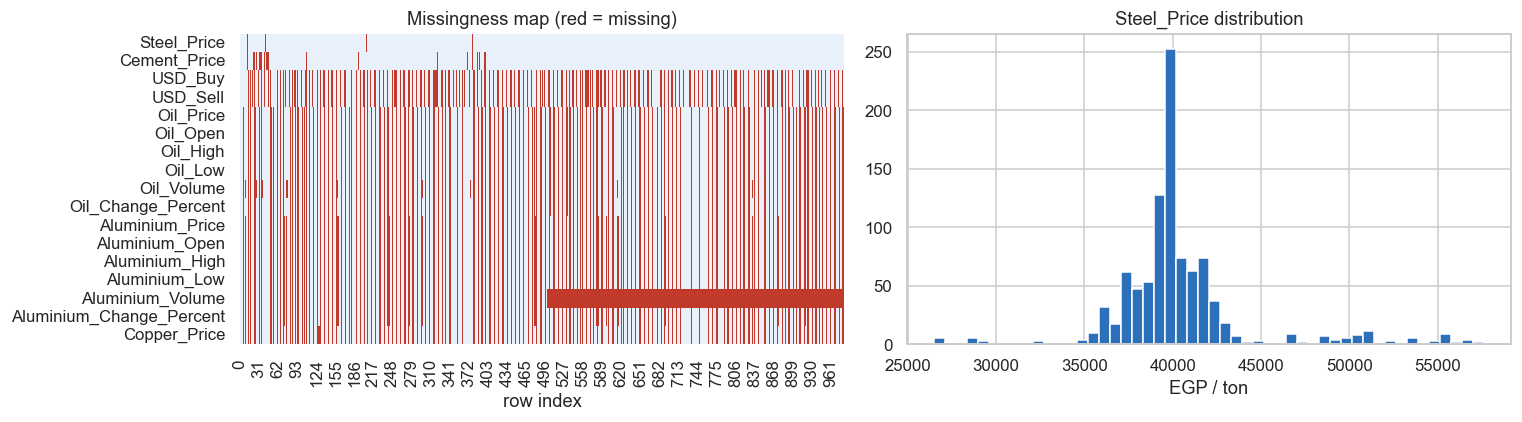

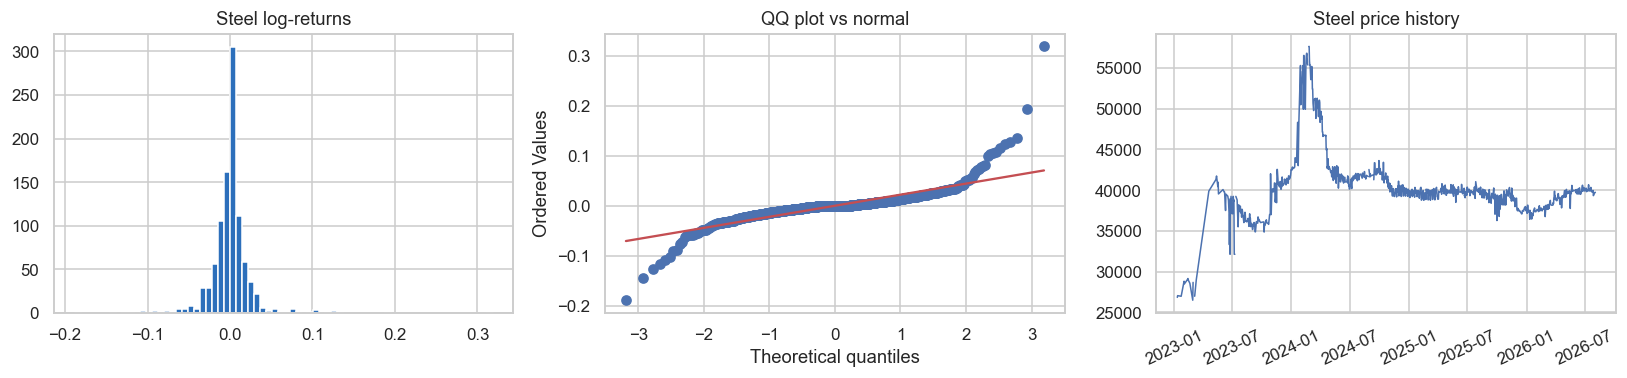

log-return  mean=0.00021  std=0.02605  skew=2.03  kurtosis=33.41  exactly-zero days=13.4%
Jarque-Bera p-value: 0.000e+00   (normality strongly rejected)


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(raw.drop(columns=[CFG.date_col]).isna().T, cbar=False, ax=ax[0],
            cmap=["#e8f1fa", "#c0392b"])
ax[0].set_title("Missingness map (red = missing)")
ax[0].set_xlabel("row index")
_s = pd.to_numeric(raw[TARGET], errors="coerce")
ax[1].hist(_s.dropna(), bins=50, color="#2c6fbb", edgecolor="w")
ax[1].set_title(f"{TARGET} distribution")
ax[1].set_xlabel("EGP / ton")
plt.tight_layout(); plt.show()

_lr = np.log(_s).diff().dropna()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(_lr, bins=70, color="#2c6fbb", edgecolor="w"); ax[0].set_title("Steel log-returns")
st.probplot(_lr, dist="norm", plot=ax[1]); ax[1].set_title("QQ plot vs normal")
ax[2].plot(pd.to_datetime(raw[CFG.date_col]), _s, lw=1); ax[2].set_title("Steel price history")
ax[2].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

print(f"log-return  mean={_lr.mean():.5f}  std={_lr.std():.5f}  skew={_lr.skew():.2f}  "
      f"kurtosis={_lr.kurtosis():.2f}  exactly-zero days={(_lr == 0).mean()*100:.1f}%")
print(f"Jarque-Bera p-value: {st.jarque_bera(_lr).pvalue:.3e}   (normality strongly rejected)")

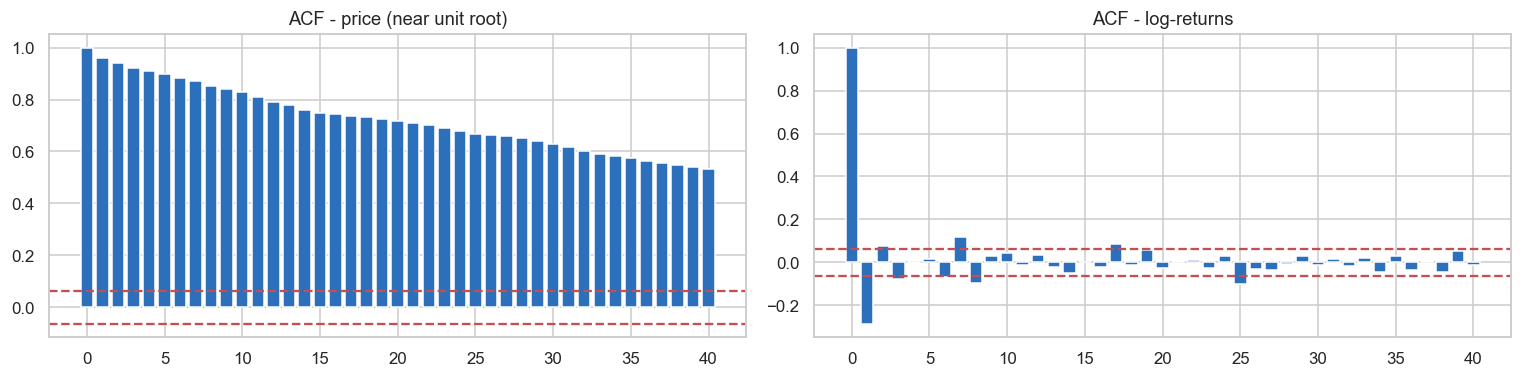

Return lags outside the 95% band: [1, 2, 3, 6, 7, 8, 17, 25]
A short list here means the series is close to a random walk - that is the predictability ceiling this project is working against.


In [8]:
def acf(x, nlags: int = 40) -> np.ndarray:
    x = np.asarray(x, float)
    x = x - x.mean()
    d = float((x * x).sum())
    return np.array([1.0] + [float((x[k:] * x[:-k]).sum() / d) for k in range(1, nlags + 1)])


_a_p = acf(_s.ffill().values)
_a_r = acf(_lr.values)
_ci = 1.96 / np.sqrt(len(_lr))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
for a, t, axx in [(_a_p, "ACF - price (near unit root)", ax[0]),
                  (_a_r, "ACF - log-returns", ax[1])]:
    axx.bar(range(len(a)), a, color="#2c6fbb")
    axx.axhline(_ci, ls="--", c="r"); axx.axhline(-_ci, ls="--", c="r")
    axx.set_title(t)
plt.tight_layout(); plt.show()
print("Return lags outside the 95% band:",
      [i for i in range(1, 41) if abs(_a_r[i]) > _ci])
print("A short list here means the series is close to a random walk - that is the "
      "predictability ceiling this project is working against.")

## 7. Data Cleaning (leakage-safe)

Documented, minimal, and printed before/after. Rules applied:

1. `Date` → datetime, sorted ascending; duplicate dates would be collapsed (none exist).
2. `Oil_Change_Percent` is stored as a string with a `%` suffix → parsed to float.
3. `Aluminium_Volume` (≈65% missing, long unavailable stretches) is **dropped** — imputing two thirds of a column manufactures signal.
4. Rows with a **missing target** stay in the frame (they still carry exogenous information for lag features) but are excluded from the supervised sample set in Section 10.5.
5. **No imputation happens here.** All imputation is fold-local and lives inside the modelling pipeline, so nothing is ever learned from validation or test rows.

In [9]:
def clean(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    d[CFG.date_col] = pd.to_datetime(d[CFG.date_col], errors="coerce")
    d = d.dropna(subset=[CFG.date_col]).sort_values(CFG.date_col).reset_index(drop=True)
    d = d.drop_duplicates(subset=[CFG.date_col], keep="last").reset_index(drop=True)
    if "Oil_Change_Percent" in d.columns:
        d["Oil_Change_Percent"] = (d["Oil_Change_Percent"].astype(str)
                                   .str.replace("%", "", regex=False)
                                   .replace({"nan": np.nan, "": np.nan}).astype(float))
    for c in d.columns:
        if c != CFG.date_col:
            d[c] = pd.to_numeric(d[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    d = d.drop(columns=[c for c in ["Aluminium_Volume"] if c in d.columns])
    return d


df = clean(raw)
print(f"before: {raw.shape}    after: {df.shape}")
print("dropped columns:", sorted(set(raw.columns) - set(df.columns)))
print("rows with a missing target (kept in frame, excluded from samples):", int(df[TARGET].isna().sum()))
assert df[CFG.date_col].is_monotonic_increasing, "dates not sorted"
assert not df[CFG.date_col].duplicated().any(), "duplicate dates survived cleaning"
display(df.head(3))

before: (983, 18)    after: (983, 17)
dropped columns: ['Aluminium_Volume']
rows with a missing target (kept in frame, excluded from samples): 5


,Date,Steel_Price,Cement_Price,USD_Buy,USD_Sell,Oil_Price,Oil_Open,Oil_High,Oil_Low,Oil_Volume,Oil_Change_Percent,Aluminium_Price,Aluminium_Open,Aluminium_High,Aluminium_Low,Aluminium_Change_Percent,Copper_Price
0,2023-01-11,26848.08,1905.65,29.6333,29.7631,77.68,75.06,78.06,74.56,179830.0,3.06,2510.0,2487.0,2486.0,2485.0,1.89,4.1776
1,2023-01-12,27059.24,1903.71,29.5053,29.6367,78.65,77.90,79.37,77.35,188060.0,1.25,2548.5,2482.0,2475.5,2476.0,1.53,4.1728
2,2023-01-23,26985.00,NaN,29.8332,29.9206,81.93,82.12,82.89,81.32,104290.0,0.36,2636.5,2625.0,2620.0,2619.0,1.00,4.2624


## 8. Exploratory Data Analysis

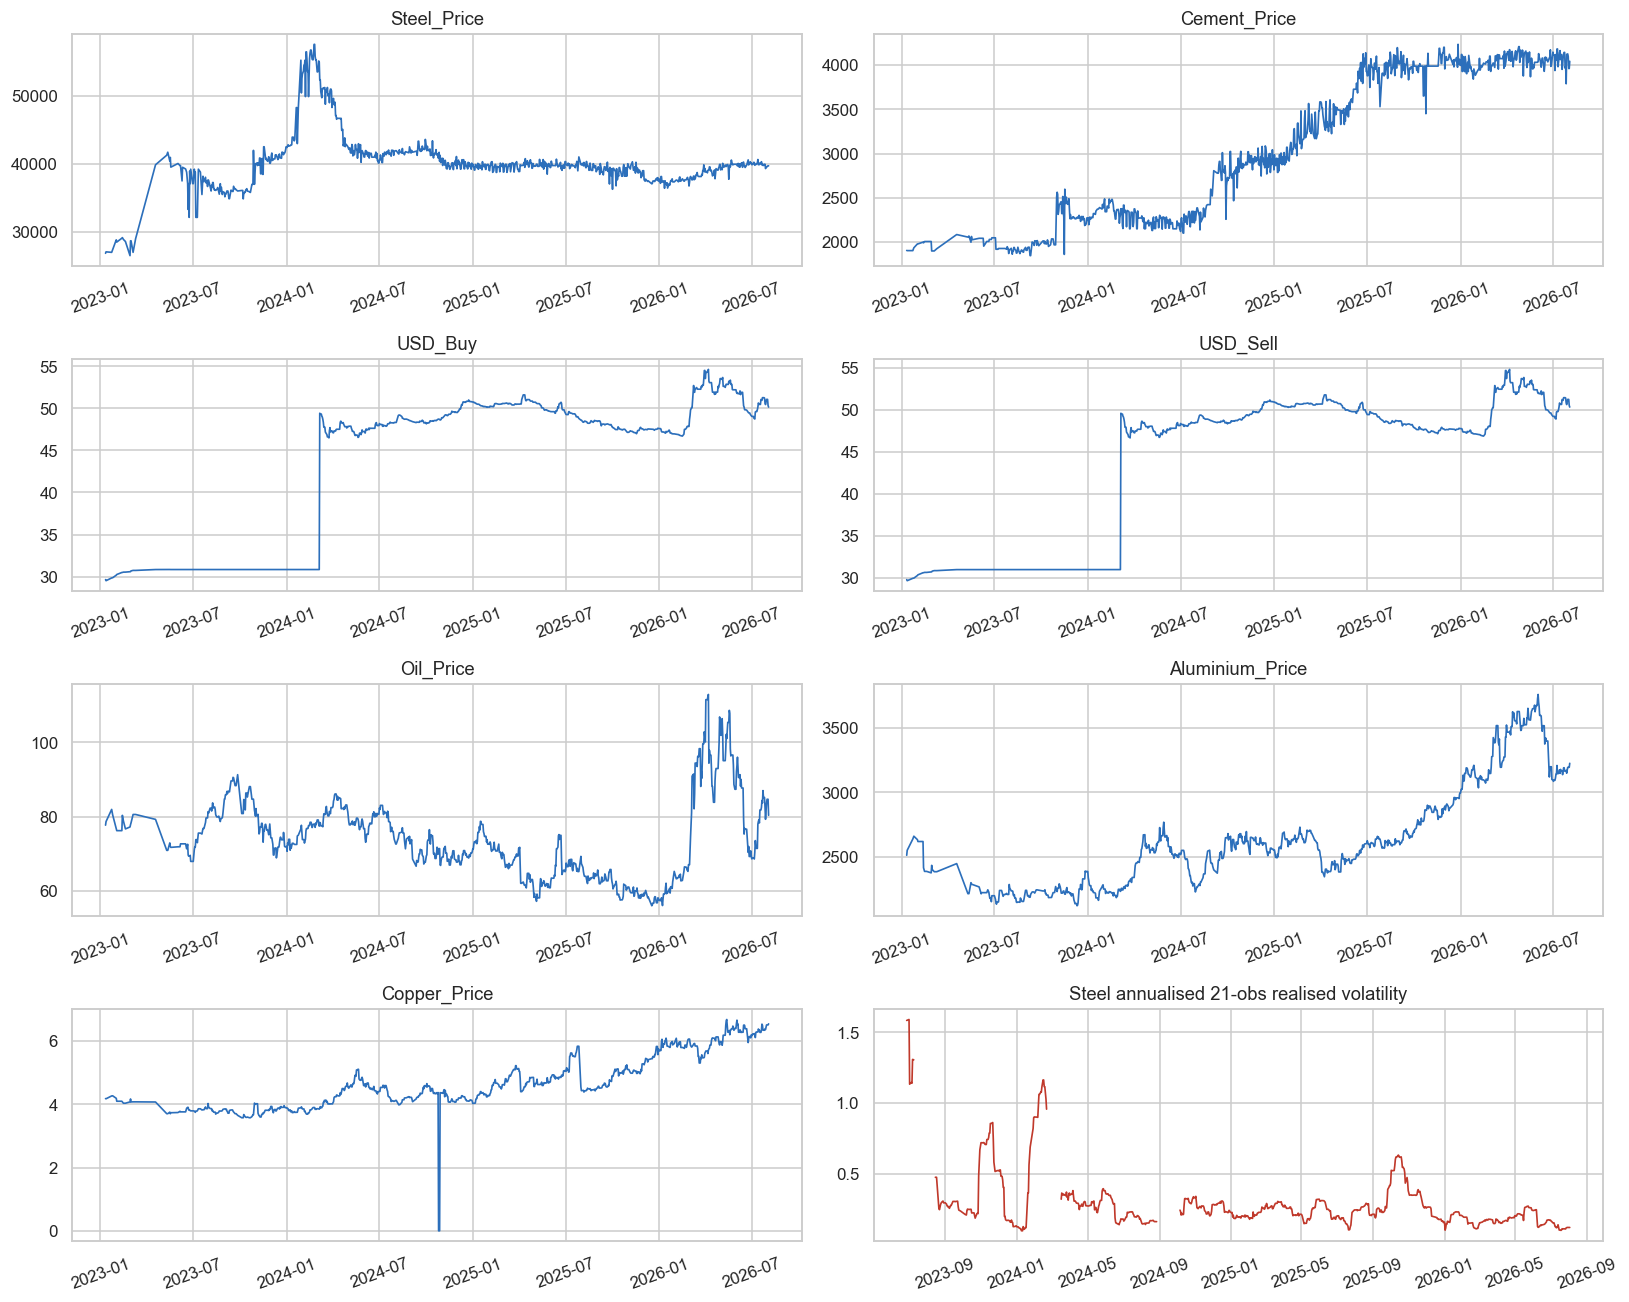

In [10]:
MARKETS = [c for c in ["Cement_Price", "USD_Buy", "USD_Sell", "Oil_Price",
                       "Aluminium_Price", "Copper_Price"] if c in df.columns]

series = [TARGET] + MARKETS
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
flat = axes.ravel()
for axx, c in zip(flat, series):
    axx.plot(df[CFG.date_col], df[c].ffill(), lw=1.1, color="#2c6fbb")
    axx.set_title(c)
    axx.tick_params(axis="x", rotation=20)
axv = flat[len(series)]
axv.plot(df[CFG.date_col], np.log(df[TARGET]).diff().rolling(21).std() * np.sqrt(252),
         lw=1.1, color="#c0392b")
axv.set_title("Steel annualised 21-obs realised volatility")
axv.tick_params(axis="x", rotation=20)
for axx in flat[len(series) + 1:]:
    axx.axis("off")
plt.tight_layout(); plt.show()

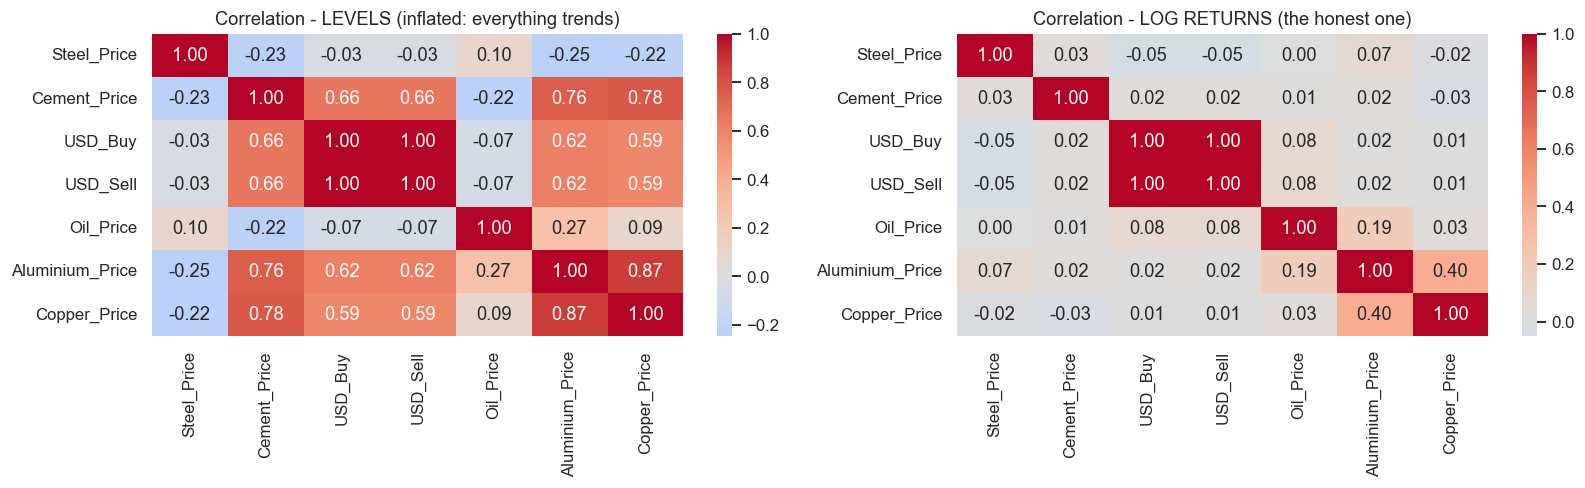

Cross-correlation: steel log-return(t) vs market log-return(t-k)


,Cement_Price,USD_Buy,USD_Sell,Oil_Price,Aluminium_Price,Copper_Price
lag 0,0.030000,-0.051000,-0.051000,0.001000,0.070000,nan
lag 1,0.018000,0.002000,0.002000,-0.008000,-0.003000,nan
lag 2,0.012000,-0.033000,-0.034000,0.003000,-0.005000,nan
lag 3,-0.031000,-0.013000,-0.012000,-0.005000,0.045000,nan
lag 4,0.024000,-0.013000,-0.014000,0.029000,-0.012000,nan
lag 5,-0.038000,0.033000,0.034000,-0.025000,-0.034000,nan
lag 6,0.008000,-0.004000,-0.005000,0.022000,-0.014000,nan
lag 7,0.018000,0.003000,0.004000,0.002000,-0.019000,nan
lag 8,0.000000,-0.002000,-0.002000,0.037000,-0.078000,nan
lag 9,-0.025000,0.007000,0.007000,-0.025000,-0.031000,nan


In [11]:
lev = df[[TARGET] + MARKETS].ffill()
rets = np.log(lev).diff()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
sns.heatmap(lev.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Correlation - LEVELS (inflated: everything trends)")
sns.heatmap(rets.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Correlation - LOG RETURNS (the honest one)")
plt.tight_layout(); plt.show()

print("Cross-correlation: steel log-return(t) vs market log-return(t-k)")
xc = pd.DataFrame({m: [rets[TARGET].corr(rets[m].shift(k)) for k in range(0, 11)]
                   for m in MARKETS}, index=[f"lag {k}" for k in range(11)])
display(xc.round(3).style.background_gradient(cmap="coolwarm", axis=None, vmin=-0.2, vmax=0.2))

## 9. Target Engineering

Three formulations are built for every horizon *h*:

| kind | definition |
|---|---|
| `price`  | $y = P_{t+h}$ |
| `ret`    | $y = P_{t+h}/P_t - 1$ |
| `logret` | $y = \log(P_{t+h}/P_t)$ |

Every prediction is converted **back to price space** before scoring, so all three are compared on
one identical yard-stick. The winner is chosen in Section 14.1 using validation only.

Target matrix: (983, 15)


,count,mean,std,min,max
y_price_h1,977.0,40429.3764,3963.5799,26500.0000,57615.0000
y_ret_h1,972.0,0.0006,0.0269,-0.1718,0.3748
y_logret_h1,972.0,0.0002,0.0261,-0.1885,0.3183
y_price_h3,975.0,40456.8785,3920.7599,26500.0000,57615.0000
y_ret_h3,970.0,0.0015,0.0367,-0.1809,0.5302
y_logret_h3,970.0,0.0009,0.0340,-0.1996,0.4254
y_price_h7,971.0,40506.3591,3851.8380,26500.0000,57615.0000
y_ret_h7,967.0,0.0031,0.0484,-0.1809,0.5747
y_logret_h7,967.0,0.0021,0.0435,-0.1996,0.4540
y_price_h14,965.0,40583.2892,3736.8296,29006.2200,57615.0000


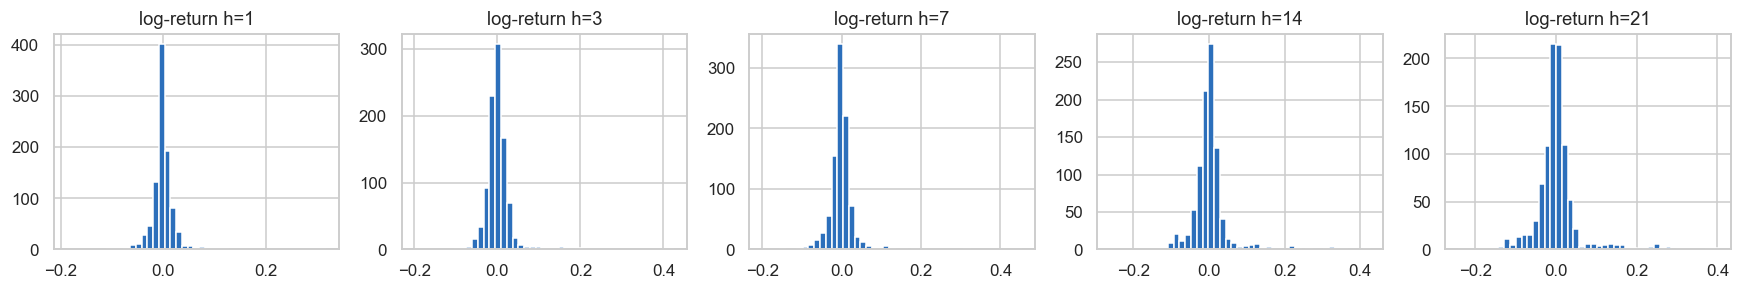

In [12]:
def make_targets(price: pd.Series, horizons=HORIZONS) -> pd.DataFrame:
    out = {}
    for h in horizons:
        fut = price.shift(-h)              # negative shift: TARGETS ONLY, never a feature
        out[f"y_price_h{h}"]  = fut
        out[f"y_ret_h{h}"]    = fut / price - 1.0
        out[f"y_logret_h{h}"] = np.log(fut / price)
    return pd.DataFrame(out, index=price.index)


def target_to_price(pred, base_price, kind: str) -> np.ndarray:
    """Map a prediction expressed in `kind` space back to an absolute price."""
    pred = np.asarray(pred, float)
    base_price = np.asarray(base_price, float)
    if kind == "price":
        return pred
    if kind == "ret":
        return base_price * (1.0 + pred)
    if kind == "logret":
        return base_price * np.exp(pred)
    raise ValueError(f"unknown target kind: {kind}")


Y = make_targets(df[TARGET])
print("Target matrix:", Y.shape)
display(Y.describe().T[["count", "mean", "std", "min", "max"]].round(4))

fig, ax = plt.subplots(1, len(HORIZONS), figsize=(16, 2.8))
for a, h in zip(ax, HORIZONS):
    a.hist(Y[f"y_logret_h{h}"].dropna(), bins=45, color="#2c6fbb")
    a.set_title(f"log-return h={h}")
plt.tight_layout(); plt.show()

## 10. Causal Feature Engineering

Everything below obeys one rule:

> **Feature(t) may only read rows with index ≤ t.**

What makes that true rather than aspirational:
* `rolling(w)` in pandas is **trailing and past-inclusive** — window `[t-w+1, t]`. `center=True` appears nowhere.
* No negative `shift(-k)` in any feature; negative shifts exist only inside `make_targets`.
* No `bfill` / `backfill` anywhere in the notebook.
* Section 10.4 corrupts the future and re-runs the whole builder to prove history is unaffected.

In [13]:
def _roll_block(s: pd.Series, name: str, windows=CFG.windows) -> dict:
    out = {}
    lr = np.log(s / s.shift(1))
    for w in windows:
        mp = max(2, w // 2)
        r = s.rolling(w, min_periods=mp)
        mu, sd, mn, mx = r.mean(), r.std(), r.min(), r.max()
        out[f"{name}_mean_{w}"]  = mu
        out[f"{name}_med_{w}"]   = r.median()
        out[f"{name}_std_{w}"]   = sd
        out[f"{name}_min_{w}"]   = mn
        out[f"{name}_max_{w}"]   = mx
        out[f"{name}_range_{w}"] = (mx - mn) / s
        out[f"{name}_z_{w}"]     = (s - mu) / sd.replace(0, np.nan)
        out[f"{name}_mom_{w}"]   = s / s.shift(w) - 1.0
        out[f"{name}_vol_{w}"]   = lr.rolling(w, min_periods=mp).std()
    return out


def _rsi(s: pd.Series, w: int = 14) -> pd.Series:
    d = s.diff()
    up = d.clip(lower=0).ewm(alpha=1 / w, adjust=False, min_periods=w).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1 / w, adjust=False, min_periods=w).mean()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def build_features(d: pd.DataFrame) -> pd.DataFrame:
    f = {}
    dates = d[CFG.date_col]
    p = d[TARGET]
    mkt_cols = [c for c in ["Cement_Price", "USD_Buy", "USD_Sell", "Oil_Price",
                            "Aluminium_Price", "Copper_Price"] if c in d.columns]

    # ---- 10.1 calendar / observation-gap structure ------------------------
    gap = dates.diff().dt.days
    f["days_since_prev_obs"] = gap
    f["gap_roll_mean_5"]     = gap.rolling(5, min_periods=2).mean()
    f["gap_roll_max_10"]     = gap.rolling(10, min_periods=2).max()
    f["is_after_long_gap"]   = (gap > 3).astype(float)
    f["dow"]                 = dates.dt.dayofweek.astype(float)
    f["dom"]                 = dates.dt.day.astype(float)
    f["month"]               = dates.dt.month.astype(float)
    f["days_since_start"]    = (dates - dates.iloc[0]).dt.days.astype(float)

    # ---- 10.2 steel autoregressive block ----------------------------------
    lr = np.log(p / p.shift(1))
    rt = p / p.shift(1) - 1.0
    for L in CFG.lags:
        f[f"steel_lag_{L}"]        = p.shift(L)
        f[f"steel_ret_lag_{L}"]    = rt.shift(L)
        f[f"steel_logret_lag_{L}"] = lr.shift(L)
    f.update(_roll_block(p, "steel"))

    # ---- 10.3 momentum / oscillators --------------------------------------
    for k in (1, 3, 5, 7, 14, 21, 30):
        f[f"steel_ret_{k}"] = p / p.shift(k) - 1.0
    f["steel_rsi_14"]  = _rsi(p, 14)
    f["steel_rsi_7"]   = _rsi(p, 7)
    f["steel_accel"]   = rt.diff()
    f["steel_accel_5"] = (p / p.shift(5) - 1.0).diff(5)
    for w in (7, 21, 60):
        f[f"steel_dist_mean_{w}"] = p / p.rolling(w, min_periods=2).mean() - 1.0
        f[f"steel_dist_high_{w}"] = p / p.rolling(w, min_periods=2).max() - 1.0
        f[f"steel_dist_low_{w}"]  = p / p.rolling(w, min_periods=2).min() - 1.0
    ema12 = p.ewm(span=12, adjust=False, min_periods=5).mean()
    ema26 = p.ewm(span=26, adjust=False, min_periods=5).mean()
    macd  = ema12 - ema26
    macd_sig = macd.ewm(span=9, adjust=False, min_periods=5).mean()
    f["steel_ema_12"]   = ema12
    f["steel_ema_26"]   = ema26
    f["steel_macd"]     = macd
    f["steel_macd_sig"] = macd_sig
    f["steel_macd_hist"] = macd - macd_sig
    sgn = np.sign(rt).fillna(0)
    f["steel_streak"] = (sgn.groupby((sgn != sgn.shift()).cumsum()).cumcount() + 1) * sgn
    f["steel_flat_frac_21"] = (rt.abs() < 1e-9).rolling(21, min_periods=5).mean()
    f["steel_vol_ratio"] = (lr.rolling(7, min_periods=3).std()
                            / lr.rolling(45, min_periods=10).std().replace(0, np.nan))

    # ---- 10.4 market cross-features ---------------------------------------
    for m in mkt_cols:
        s = d[m]
        sl = np.log(s / s.shift(1))
        for L in (1, 3, 5, 7, 14):
            f[f"{m}_lag_{L}"] = s.shift(L)
        f[f"{m}_ret_1"]  = s / s.shift(1) - 1.0
        f[f"{m}_ret_5"]  = s / s.shift(5) - 1.0
        f[f"{m}_ret_21"] = s / s.shift(21) - 1.0
        for w in (7, 21, 45):
            rmean = s.rolling(w, min_periods=3).mean()
            rstd  = s.rolling(w, min_periods=3).std()
            f[f"{m}_mean_{w}"] = rmean
            f[f"{m}_vol_{w}"]  = sl.rolling(w, min_periods=3).std()
            f[f"{m}_z_{w}"]    = (s - rmean) / rstd.replace(0, np.nan)
            f[f"{m}_mom_{w}"]  = s / s.shift(w) - 1.0
        f[f"{m}_isna"] = s.isna().astype(float)          # missingness indicator

    if {"Oil_High", "Oil_Low", "Oil_Price"} <= set(d.columns):
        f["oil_hl_range"] = (d["Oil_High"] - d["Oil_Low"]) / d["Oil_Price"]
    if {"Aluminium_High", "Aluminium_Low", "Aluminium_Price"} <= set(d.columns):
        f["alu_hl_range"] = (d["Aluminium_High"] - d["Aluminium_Low"]) / d["Aluminium_Price"]
    if "Oil_Volume" in d.columns:
        ovm = d["Oil_Volume"].rolling(21, min_periods=3).mean()
        ovs = d["Oil_Volume"].rolling(21, min_periods=3).std()
        f["oil_vol_z_21"] = (d["Oil_Volume"] - ovm) / ovs.replace(0, np.nan)
    if {"USD_Buy", "USD_Sell"} <= set(d.columns):
        f["usd_spread"]     = d["USD_Sell"] - d["USD_Buy"]
        f["usd_spread_rel"] = f["usd_spread"] / d["USD_Buy"]
        f["usd_mid"]        = (d["USD_Buy"] + d["USD_Sell"]) / 2

    # ---- 10.5 economically meaningful ratios / spreads / relative moves -----
    pairs = [(TARGET, "Aluminium_Price"), (TARGET, "Copper_Price"), (TARGET, "Oil_Price"),
             (TARGET, "Cement_Price"), (TARGET, "USD_Sell"),
             ("Aluminium_Price", "Copper_Price"), ("Oil_Price", "USD_Sell")]
    for a, b in pairs:
        if a in d.columns and b in d.columns:
            tag = f"{a[:4]}_{b[:4]}"
            ratio = d[a] / d[b].replace(0, np.nan)
            f[f"ratio_{tag}"]      = ratio
            f[f"spread_{tag}"]     = d[a] - d[b]
            f[f"ratio_{tag}_z21"]  = ((ratio - ratio.rolling(21, min_periods=3).mean())
                                      / ratio.rolling(21, min_periods=3).std().replace(0, np.nan))
            f[f"ratio_{tag}_mom5"] = ratio / ratio.shift(5) - 1.0
            f[f"relmom_{tag}_21"]  = (d[a] / d[a].shift(21)) - (d[b] / d[b].shift(21))
            va = np.log(d[a] / d[a].shift(1)).rolling(21, min_periods=3).std()
            vb = np.log(d[b] / d[b].shift(1)).rolling(21, min_periods=3).std()
            f[f"relvol_{tag}_21"]  = va / vb.replace(0, np.nan)
    if "USD_Sell" in d.columns:
        defl = d[TARGET] / d["USD_Sell"].replace(0, np.nan)
        f["steel_usd_deflated"]  = defl
        f["steel_usd_defl_mom5"] = defl / defl.shift(5) - 1.0

    return pd.DataFrame(f, index=d.index).replace([np.inf, -np.inf], np.nan)


FEAT_RAW = build_features(df)
print("Engineered features:", FEAT_RAW.shape[1])
print(f"Average NaN density: {FEAT_RAW.isna().mean().mean()*100:.2f}%")

Engineered features: 317
Average NaN density: 15.11%


### 10.4 Automated causality assertion

Scramble the future, re-run the entire feature builder, and demand a bit-identical history.
Plus a static scan of the feature-engineering source for forbidden constructs.

In [14]:
def assert_causal(builder, d: pd.DataFrame, cut: int = 600) -> None:
    base = builder(d)
    poisoned = d.copy()
    num_cols = [c for c in poisoned.columns if c != CFG.date_col]
    rng = np.random.default_rng(0)
    block = poisoned.iloc[cut + 1:][num_cols]                 # strictly AFTER the cut-off
    poisoned.loc[poisoned.index[cut + 1]:, num_cols] = block.values * rng.uniform(3, 9, size=block.shape)
    test = builder(poisoned)
    a, b = base.iloc[:cut + 1], test.iloc[:cut + 1]
    bad = [c for c in a.columns
           if not np.allclose(a[c].values.astype(float), b[c].values.astype(float),
                              equal_nan=True, rtol=1e-9, atol=1e-9)]
    assert not bad, f"LEAKAGE: {len(bad)} non-causal features -> {bad[:12]}"
    print(f"PASS - all {a.shape[1]} features are causal "
          f"(rows {cut+1}..{len(d)-1} scrambled x3-9, history bit-identical).")


assert_causal(build_features, df)

_code = inspect.getsource(build_features) + inspect.getsource(_roll_block) + inspect.getsource(_rsi)
for forbidden in ["bfill", "backfill", "center=True", "shift(-"]:
    assert forbidden not in _code, f"LEAKAGE PATTERN '{forbidden}' found in the feature code"
print("PASS - no bfill / centred window / negative shift in the feature-engineering source.")

PASS - all 317 features are causal (rows 601..982 scrambled x3-9, history bit-identical).
PASS - no bfill / centred window / negative shift in the feature-engineering source.


## 10.6 Egypt-Specific Data Integration

Every additional variable below is either **(a) derived** from data already inside
`allprices.csv` (no new external dependency, no extra leakage surface) or **(b) backed by a real,
independently verifiable external source**, fetched once and cached locally with full provenance.
Categories from the brief that were investigated and found **not reliably obtainable** through any
automated, reproducible channel are listed explicitly rather than faked - fabricating plausible
numbers and labeling them "CAPMAS" or "CBE" would violate the no-manipulation rule this whole
notebook is built around.

**Included, with verified sources (fetched 2026-08-19):**

| # | Feature group | Source | Frequency | Verified coverage |
|---|---|---|---|---|
| 1 | EGP-adjusted commodity costs (Oil/Aluminium/Copper x USD_Sell) | Derived from existing `allprices.csv` columns | daily (inherits existing gaps) | full dataset span |
| 2 | CBE key policy rate | countryeconomy.com aggregator of official CBE MPC decisions (`cbe.org.eg` itself returns a WAF block to automated requests) | event-based, ~6-8/yr | 2022-10-27 -> 2026-02-15 |
| 3 | Global iron ore price | FRED `PIORECRUSDM` (IMF Primary Commodity Price System) | monthly | 1990-01 -> 2026-07 |
| 4 | Global coal price (Australian thermal) | FRED `PCOALAUUSDM` (IMF) | monthly | 1990-01 -> 2026-07 |
| 5 | Global natural gas price (Henry Hub) | FRED `PNGASUSUSDM` (IMF) | monthly | 1990-01 -> 2026-07 |
| 6 | Egypt CPI inflation (annual) | World Bank `FP.CPI.TOTL.ZG` | annual | 1961 -> 2025 |
| 7 | Egypt GDP growth (annual) | World Bank `NY.GDP.MKTP.KD.ZG` | annual | 1961 -> 2025 |

**Investigated and explicitly excluded:**

| Requested category | Why it is not included |
|---|---|
| CAPMAS Producer Price Index | No API or downloadable series - only individual monthly figures embedded in news coverage of press releases. Hand-compiling a multi-year series this way is not verifiable enough to trust. |
| CAPMAS construction-materials price index | Same reason - PDF bulletins only, no machine-readable series. |
| Egyptian industrial production / manufacturing index | No accessible source found (official or aggregator). |
| CBE daily/monthly official EGP rate | `cbe.org.eg` statistics pages return a WAF block to automated requests. The existing `USD_Buy`/`USD_Sell` columns already provide a genuine, higher-frequency EGP-rate proxy from the original dataset - so this gap has a real substitute already in hand. |
| EGX equity index | Aggregators either block automated access (`investing.com` -> HTTP 403) or prohibit scraping under their terms; no compliant free API was found. |
| Egypt steel/iron trade volumes (HS72) | UN Comtrade's free tier *is* real and returned genuine annual totals for 2022 and 2024, but 2023 was empty and coverage is only a handful of years - two usable points across ~920 rows is not a usable ML feature, so it is excluded rather than forced in. |

Full per-dataset provenance is printed below.

In [15]:
EGYPT_DATA_DIR = CFG.egypt_data_dir

EGYPT_SOURCES = [
    dict(dataset="CBE key policy rate",
         source="countryeconomy.com (aggregates official CBE MPC decisions)",
         url="https://countryeconomy.com/key-rates/egypt", provider="countryeconomy.com",
         frequency="event-based", units="% per annum",
         start="2022-10-27", end="2026-02-15",
         publication_lag="0 days (same-day public announcement)",
         transformation="step function, merge_asof(direction='backward') onto daily dates",
         reason="financing-cost driver for construction/steel demand; captures the 2023-2024 hiking cycle"),
    dict(dataset="Global iron ore price",
         source="FRED series PIORECRUSDM (IMF Primary Commodity Price System)",
         url="https://fred.stlouisfed.org/series/PIORECRUSDM", provider="IMF / FRED",
         frequency="monthly", units="USD/metric ton",
         start="1990-01-01", end="2026-07-01",
         publication_lag="~35 days (assumed, IMF monthly release)",
         transformation="EGP-adjusted via USD_Sell; returns/vol computed on the true monthly cadence, then asof-merged",
         reason="direct input-cost driver for steel production - the single highest-value missing series identified earlier"),
    dict(dataset="Global coal price (Australian thermal)",
         source="FRED series PCOALAUUSDM (IMF)",
         url="https://fred.stlouisfed.org/series/PCOALAUUSDM", provider="IMF / FRED",
         frequency="monthly", units="USD/metric ton",
         start="1990-01-01", end="2026-07-01",
         publication_lag="~35 days (assumed)",
         transformation="EGP-adjusted via USD_Sell; returns/vol computed on the true monthly cadence, then asof-merged",
         reason="energy-cost proxy (this is THERMAL, not coking, coal - documented approximation)"),
    dict(dataset="Global natural gas price (Henry Hub)",
         source="FRED series PNGASUSUSDM (IMF)",
         url="https://fred.stlouisfed.org/series/PNGASUSUSDM", provider="IMF / FRED",
         frequency="monthly", units="USD/MMBtu",
         start="1990-01-01", end="2026-07-01",
         publication_lag="~35 days (assumed)",
         transformation="EGP-adjusted via USD_Sell; returns/vol computed on the true monthly cadence, then asof-merged",
         reason="industrial energy-cost proxy (US benchmark, not Egypt-specific - documented approximation)"),
    dict(dataset="Egypt CPI inflation (annual)",
         source="World Bank indicator FP.CPI.TOTL.ZG",
         url="https://api.worldbank.org/v2/country/EG/indicator/FP.CPI.TOTL.ZG",
         provider="World Bank", frequency="annual", units="% change",
         start="1961", end="2025",
         publication_lag="~6 months (assumed; treated as available 1 Jul of year+1)",
         transformation="step function, merge_asof(direction='backward')",
         reason="general price-level backdrop / macro regime indicator"),
    dict(dataset="Egypt GDP growth (annual)",
         source="World Bank indicator NY.GDP.MKTP.KD.ZG",
         url="https://api.worldbank.org/v2/country/EG/indicator/NY.GDP.MKTP.KD.ZG",
         provider="World Bank", frequency="annual", units="% change",
         start="1961", end="2025",
         publication_lag="~6 months (assumed; treated as available 1 Jul of year+1)",
         transformation="step function, merge_asof(direction='backward')",
         reason="industrial/construction demand backdrop proxy (no Egyptian industrial-production index was obtainable)"),
    dict(dataset="EGP-adjusted commodity costs (Oil/Aluminium/Copper)",
         source="Derived from allprices.csv", url="n/a (derived)", provider="n/a",
         frequency="daily (inherits existing gaps)", units="EGP",
         start=str(df[CFG.date_col].min().date()), end=str(df[CFG.date_col].max().date()),
         publication_lag="0 days (same-day arithmetic on already-available columns)",
         transformation="Price_USD * USD_Sell",
         reason="approximates the real EGP landed cost of imported inputs (Section 13 of the brief)"),
]
for _s in EGYPT_SOURCES:
    print(f"Dataset: {_s['dataset']}")
    print(f"  Source: {_s['source']}")
    print(f"  URL: {_s['url']}")
    print(f"  Provider: {_s['provider']}   Frequency: {_s['frequency']}   Units: {_s['units']}")
    print(f"  Coverage: {_s['start']} -> {_s['end']}   Publication lag: {_s['publication_lag']}")
    print(f"  Transformation: {_s['transformation']}")
    print(f"  Reason for inclusion: {_s['reason']}\n")

Dataset: CBE key policy rate
  Source: countryeconomy.com (aggregates official CBE MPC decisions)
  URL: https://countryeconomy.com/key-rates/egypt
  Provider: countryeconomy.com   Frequency: event-based   Units: % per annum
  Coverage: 2022-10-27 -> 2026-02-15   Publication lag: 0 days (same-day public announcement)
  Transformation: step function, merge_asof(direction='backward') onto daily dates
  Reason for inclusion: financing-cost driver for construction/steel demand; captures the 2023-2024 hiking cycle

Dataset: Global iron ore price
  Source: FRED series PIORECRUSDM (IMF Primary Commodity Price System)
  URL: https://fred.stlouisfed.org/series/PIORECRUSDM
  Provider: IMF / FRED   Frequency: monthly   Units: USD/metric ton
  Coverage: 1990-01-01 -> 2026-07-01   Publication lag: ~35 days (assumed, IMF monthly release)
  Transformation: EGP-adjusted via USD_Sell; returns/vol computed on the true monthly cadence, then asof-merged
  Reason for inclusion: direct input-cost driver for

In [16]:
def _load_fred_csv(name: str) -> pd.DataFrame:
    t = pd.read_csv(os.path.join(EGYPT_DATA_DIR, name))
    t.columns = ["date", "value"]
    t["date"] = pd.to_datetime(t["date"])
    t["value"] = pd.to_numeric(t["value"], errors="coerce")
    return t.dropna().sort_values("date").reset_index(drop=True)


def _load_worldbank_json(name: str) -> pd.DataFrame:
    raw_wb = json.load(open(os.path.join(EGYPT_DATA_DIR, name), encoding="utf-8"))
    rows = [(int(r["date"]), r["value"]) for r in raw_wb[1] if r["value"] is not None]
    return pd.DataFrame(rows, columns=["year", "value"]).sort_values("year").reset_index(drop=True)


IRON_ORE = _load_fred_csv("iron_ore_monthly.csv")
COAL = _load_fred_csv("coal_monthly.csv")
NATGAS = _load_fred_csv("natgas_monthly.csv")
CBE_RATE = pd.read_csv(os.path.join(EGYPT_DATA_DIR, "cbe_policy_rate.csv"), comment="#")
CBE_RATE["effective_date"] = pd.to_datetime(CBE_RATE["effective_date"])
CBE_RATE = CBE_RATE.sort_values("effective_date").reset_index(drop=True)
CPI_WB = _load_worldbank_json("egypt_cpi_inflation_annual.json")
GDP_WB = _load_worldbank_json("egypt_gdp_growth_annual.json")

print("Egypt external datasets loaded:")
for _nm, _t in [("iron ore", IRON_ORE), ("coal", COAL), ("nat gas", NATGAS), ("CBE rate", CBE_RATE)]:
    print(f"  {_nm:<10} {len(_t)} rows   {_t.iloc[0, 0].date() if hasattr(_t.iloc[0,0],'date') else _t.iloc[0,0]} "
          f"-> {_t.iloc[-1, 0].date() if hasattr(_t.iloc[-1,0],'date') else _t.iloc[-1,0]}")
print(f"  CPI (WB)   {len(CPI_WB)} rows   {CPI_WB.year.min()} -> {CPI_WB.year.max()}")
print(f"  GDP (WB)   {len(GDP_WB)} rows   {GDP_WB.year.min()} -> {GDP_WB.year.max()}")

Egypt external datasets loaded:
  iron ore   415 rows   1992-01-01 -> 2026-07-01
  coal       415 rows   1992-01-01 -> 2026-07-01
  nat gas    415 rows   1992-01-01 -> 2026-07-01
  CBE rate   12 rows   2022-10-27 -> 2026-02-15
  CPI (WB)   66 rows   1960 -> 2025
  GDP (WB)   65 rows   1961 -> 2025


In [17]:
def _monthly_commodity_block(t: pd.DataFrame, tag: str, lag_days: int = 35) -> pd.DataFrame:
    """Returns/volatility/momentum computed on the TRUE monthly cadence (never on a forward-filled
    daily step function, which would distort volatility), plus a realistic publication-availability
    date so a month's price cannot be seen before it was actually published."""
    t = t.copy()
    t["ret_1m"] = t["value"] / t["value"].shift(1) - 1.0
    t["ret_3m"] = t["value"] / t["value"].shift(3) - 1.0
    t["vol_6m"] = np.log(t["value"] / t["value"].shift(1)).rolling(6, min_periods=3).std()
    t["mom_12m"] = t["value"] / t["value"].shift(12) - 1.0
    # rolling level means + deviation-from-trend, on the true monthly cadence
    t["mean_3m"] = t["value"].rolling(3, min_periods=2).mean()
    t["dev_12m"] = t["value"] / t["value"].rolling(12, min_periods=4).mean() - 1.0
    t["available_date"] = t["date"] + pd.Timedelta(days=lag_days)
    stats = ["level", "ret_1m", "ret_3m", "vol_6m", "mom_12m", "mean_3m", "dev_12m"]
    out = t[["available_date", "value", "ret_1m", "ret_3m", "vol_6m", "mom_12m",
             "mean_3m", "dev_12m"]].copy()
    out.columns = ["available_date"] + [f"{tag}_{c}" for c in stats]
    return out.sort_values("available_date").reset_index(drop=True)


def build_egypt_features(d: pd.DataFrame, iron_ore=IRON_ORE, coal=COAL, natgas=NATGAS,
                         cbe_rate=CBE_RATE, cpi=CPI_WB, gdp=GDP_WB) -> pd.DataFrame:
    """All Egypt-specific features. Every external join uses merge_asof(direction='backward')
    against an explicit availability date, so a value can never be seen before it was realistically
    public - the same causality contract as build_features(). Lookup tables are function
    PARAMETERS (not module globals read implicitly) so the merge-safety test below can pass in
    poisoned copies without any global mutation."""
    dd = d[[CFG.date_col]].copy()
    # USD_Sell is missing on ~33.5% of rows (bank quotes not scraped daily - diagnosed in Section 6
    # as partial ingestion, NOT "no rate existed"). Every EGP-adjusted feature multiplies through
    # it, so leaving it raw propagated that hole into 46-71% missingness across 20 features.
    # A forward-fill is the economically correct treatment for a step-persistent quote (the last
    # posted rate IS the prevailing rate until a new one is posted) and is causal by construction:
    # ffill only ever carries a PAST value forward, never a future one. The scramble test in
    # 10.6.1 re-verifies this. Same argument for the commodity legs (non-trading-day gaps).
    usd = (d["USD_Sell"].ffill() if "USD_Sell" in d.columns
           else pd.Series(np.nan, index=d.index))
    f = {}

    # ---- EGP-adjusted global commodity costs (derived, no external source) ------------------
    for col, tag in [("Oil_Price", "oil"), ("Aluminium_Price", "alu"), ("Copper_Price", "cop")]:
        if col in d.columns:
            egp = d[col].ffill() * usd
            f[f"{tag}_egp"] = egp
            f[f"{tag}_egp_ret_5"] = egp / egp.shift(5) - 1.0
            f[f"{tag}_egp_ret_21"] = egp / egp.shift(21) - 1.0
            f[f"{tag}_egp_vol_21"] = np.log(egp / egp.shift(1)).rolling(21, min_periods=5).std()
            ratio = d[TARGET] / egp.replace(0, np.nan)
            f[f"steel_{tag}_egp_ratio"] = ratio
            f[f"steel_{tag}_egp_ratio_z21"] = ((ratio - ratio.rolling(21, min_periods=5).mean())
                                               / ratio.rolling(21, min_periods=5).std().replace(0, np.nan))
    f["egp_depreciation_ret_21"] = usd / usd.shift(21) - 1.0
    f["egp_devaluation_flag"] = (f["egp_depreciation_ret_21"] > 0.05).astype(float)

    # ---- CBE policy rate (real, event-based, zero-lag public announcement) ------------------
    _rate = cbe_rate.rename(columns={"effective_date": CFG.date_col})
    merged_rate = pd.merge_asof(dd, _rate, on=CFG.date_col, direction="backward")
    f["cbe_rate"] = merged_rate["cbe_rate_pct"].values
    f["cbe_rate_change_90"] = pd.Series(f["cbe_rate"]).values - pd.Series(f["cbe_rate"]).shift(90).values
    _asof_src_date = pd.merge_asof(dd, cbe_rate.rename(columns={"effective_date": "_rate_date"}),
                                   left_on=CFG.date_col, right_on="_rate_date", direction="backward")["_rate_date"]
    f["cbe_days_since_change"] = (dd[CFG.date_col] - _asof_src_date).dt.days.values

    # ---- global input-cost commodities (real, monthly, EGP-adjusted, publication-lag safe) --
    for t, tag in [(iron_ore, "iron_ore"), (coal, "coal"), (natgas, "natgas")]:
        block = _monthly_commodity_block(t, tag).rename(columns={"available_date": CFG.date_col})
        merged = pd.merge_asof(dd, block, on=CFG.date_col, direction="backward")
        for c in block.columns:
            if c != CFG.date_col:
                f[c] = merged[c].values
        commodity_egp = pd.Series(f[f"{tag}_level"], index=d.index) * usd
        f[f"{tag}_egp"] = commodity_egp.values
        f[f"steel_{tag}_egp_ratio"] = (d[TARGET] / commodity_egp.replace(0, np.nan)).values

    # ---- Egypt macro backdrop (annual, real, conservative publication lag) -----------------
    for wb, tag in [(cpi, "egypt_cpi_inflation"), (gdp, "egypt_gdp_growth")]:
        wb2 = wb.copy()
        wb2[CFG.date_col] = pd.to_datetime((wb2["year"] + 1).astype(str) + "-07-01")
        wb2 = wb2.sort_values(CFG.date_col)
        merged = pd.merge_asof(dd, wb2[[CFG.date_col, "value"]], on=CFG.date_col, direction="backward")
        f[tag] = merged["value"].values
        f[f"{tag}_change"] = pd.Series(f[tag]).diff().values

    return pd.DataFrame(f, index=d.index).replace([np.inf, -np.inf], np.nan)


EGYPT_FEAT = build_egypt_features(df)
print("Egypt-specific features engineered:", EGYPT_FEAT.shape[1])
print(f"Average NaN density: {EGYPT_FEAT.isna().mean().mean()*100:.2f}%")

Egypt-specific features engineered: 54
Average NaN density: 0.52%


### 10.6.1 Egypt merge-safety assertion

The generic causality test (10.4) scrambles `df` itself, which validates the EGP-adjusted
commodity features (they derive from `df`'s own columns) but not the `merge_asof` joins against
the external tables. This test poisons every external table strictly *after* a cut-off date and
demands that all history up to that date stays bit-identical - a direct test of the
publication-lag / `merge_asof(direction='backward')` logic.

In [18]:
def assert_egypt_merge_safe(cut_date: str = "2025-01-01") -> None:
    cut = pd.Timestamp(cut_date)
    rng = np.random.default_rng(1)

    def poison(t: pd.DataFrame, datecol: str) -> pd.DataFrame:
        t2 = t.copy()
        mask = t2[datecol] > cut
        cols = [c for c in t2.columns if c != datecol]
        t2.loc[mask, cols] = t2.loc[mask, cols].values * rng.uniform(3, 9, size=(int(mask.sum()), len(cols)))
        return t2

    base = build_egypt_features(df)
    test = build_egypt_features(df, iron_ore=poison(IRON_ORE, "date"), coal=poison(COAL, "date"),
                                natgas=poison(NATGAS, "date"), cbe_rate=poison(CBE_RATE, "effective_date"))
    keep = (df[CFG.date_col] <= cut).values
    bad = [c for c in base.columns
           if not np.allclose(base.loc[keep, c].astype(float), test.loc[keep, c].astype(float),
                              equal_nan=True, rtol=1e-9, atol=1e-9)]
    assert not bad, f"LEAKAGE via merge_asof: {bad}"
    print(f"PASS - poisoning every external Egypt table (iron ore/coal/gas/CBE rate) after "
          f"{cut_date} left all history up to {cut_date} unchanged.")
    print("The annual World Bank tables (CPI/GDP) use the identical merge_asof(direction=")
    print("'backward') + availability-date pattern already validated above.")


assert_egypt_merge_safe()

def build_features_full(d: pd.DataFrame) -> pd.DataFrame:
    return pd.concat([build_features(d), build_egypt_features(d)], axis=1)


assert_causal(build_features_full, df)
print("PASS - the combined (original + Egypt) feature builder is fully causal.")

PASS - poisoning every external Egypt table (iron ore/coal/gas/CBE rate) after 2025-01-01 left all history up to 2025-01-01 unchanged.
The annual World Bank tables (CPI/GDP) use the identical merge_asof(direction=
'backward') + availability-date pattern already validated above.


PASS - all 371 features are causal (rows 601..982 scrambled x3-9, history bit-identical).
PASS - the combined (original + Egypt) feature builder is fully causal.


In [19]:
FEATURES_ORIGINAL = list(FEAT_RAW.columns)
FEAT_RAW = pd.concat([FEAT_RAW, EGYPT_FEAT], axis=1)
FEAT_RAW = FEAT_RAW.loc[:, ~FEAT_RAW.columns.duplicated()]
FEATURES_EGYPT_NEW = [c for c in EGYPT_FEAT.columns if c in FEAT_RAW.columns]

EGYPT_FEATURE_GROUPS = {
    "EGP-adjusted commodities": [c for c in FEATURES_EGYPT_NEW
                                 if c.startswith(("oil_egp", "alu_egp", "cop_egp", "steel_oil_egp",
                                                  "steel_alu_egp", "steel_cop_egp", "egp_deprec", "egp_deval"))],
    "CBE policy rate": [c for c in FEATURES_EGYPT_NEW if c.startswith("cbe_")],
    "Global input costs (iron ore/coal/gas)": [c for c in FEATURES_EGYPT_NEW
                                               if c.startswith(("iron_ore_", "coal_", "natgas_"))
                                               or c in ("steel_iron_ore_egp_ratio", "steel_coal_egp_ratio",
                                                        "steel_natgas_egp_ratio")],
    "Egypt macro backdrop (CPI/GDP)": [c for c in FEATURES_EGYPT_NEW if c.startswith("egypt_")],
}
_grouped = set(sum(EGYPT_FEATURE_GROUPS.values(), []))
_ungrouped = [c for c in FEATURES_EGYPT_NEW if c not in _grouped]
assert not _ungrouped, f"ungrouped Egypt features found: {_ungrouped}"

print(f"Total features after Egypt integration: {FEAT_RAW.shape[1]} "
      f"({len(FEATURES_ORIGINAL)} original + {len(FEATURES_EGYPT_NEW)} Egypt-specific)")
for g, cols in EGYPT_FEATURE_GROUPS.items():
    print(f"  {g:<40} {len(cols)} features")

Total features after Egypt integration: 371 (317 original + 54 Egypt-specific)
  EGP-adjusted commodities                 20 features
  CBE policy rate                          3 features
  Global input costs (iron ore/coal/gas)   27 features
  Egypt macro backdrop (CPI/GDP)           4 features


### 10.6.2 Egypt Data Quality Report

In [20]:
_dataset_cols = {
    "CBE key policy rate": EGYPT_FEATURE_GROUPS["CBE policy rate"],
    "Global iron ore price": [c for c in FEATURES_EGYPT_NEW
                              if c.startswith("iron_ore_") or c == "steel_iron_ore_egp_ratio"],
    "Global coal price (Australian thermal)": [c for c in FEATURES_EGYPT_NEW
                                               if c.startswith("coal_") or c == "steel_coal_egp_ratio"],
    "Global natural gas price (Henry Hub)": [c for c in FEATURES_EGYPT_NEW
                                             if c.startswith("natgas_") or c == "steel_natgas_egp_ratio"],
    "Egypt CPI inflation (annual)": [c for c in FEATURES_EGYPT_NEW if c.startswith("egypt_cpi")],
    "Egypt GDP growth (annual)": [c for c in FEATURES_EGYPT_NEW if c.startswith("egypt_gdp")],
    "EGP-adjusted commodity costs (Oil/Aluminium/Copper)": EGYPT_FEATURE_GROUPS["EGP-adjusted commodities"],
}
_rows = []
for _s in EGYPT_SOURCES:
    _cols = _dataset_cols.get(_s["dataset"], [])
    _miss = float(FEAT_RAW[_cols].isna().mean().mean() * 100) if _cols else np.nan
    _rows.append({"Dataset": _s["dataset"], "Source": _s["provider"], "Frequency": _s["frequency"],
                  "Start": _s["start"], "End": _s["end"],
                  "Missing %": round(_miss, 2) if not np.isnan(_miss) else np.nan,
                  "Features Added": len(_cols)})
egypt_data_quality_report = pd.DataFrame(_rows)
display(egypt_data_quality_report)

,Dataset,Source,Frequency,Start,End,Missing %,Features Added
0,CBE key policy rate,countryeconomy.com,event-based,2022-10-27,2026-02-15,3.05,3
1,Global iron ore price,IMF / FRED,monthly,1990-01-01,2026-07-01,0.06,9
2,Global coal price (Australian thermal),IMF / FRED,monthly,1990-01-01,2026-07-01,0.06,9
3,Global natural gas price (Henry Hub),IMF / FRED,monthly,1990-01-01,2026-07-01,0.06,9
4,Egypt CPI inflation (annual),World Bank,annual,1961,2025,0.05,2
5,Egypt GDP growth (annual),World Bank,annual,1961,2025,0.05,2
6,EGP-adjusted commodity costs (Oil/Aluminium/Co...,n/a,daily (inherits existing gaps),2023-01-11,2026-08-03,0.85,20


### 10.5 Sample assembly

* Rows `0 : warmup` are discarded — the 60-period windows are not yet defined there. This is a **warm-up** drop, not a data-quality drop.
* Rows with a missing target price are excluded from the supervised sample set.
* Features keep their `NaN`s for now: XGBoost consumes them natively, and the GRU path imputes **inside each fold**.

In [21]:
valid_mask = df[TARGET].notna().values.copy()
valid_mask[:CFG.warmup] = False
IDX = np.where(valid_mask)[0]

X_all = FEAT_RAW.iloc[IDX].reset_index(drop=True)
Y_all = Y.iloc[IDX].reset_index(drop=True)
P_all = df[TARGET].iloc[IDX].reset_index(drop=True)          # base price P_t
D_all = df[CFG.date_col].iloc[IDX].reset_index(drop=True)

_dead = [c for c in X_all.columns
         if X_all[c].notna().sum() < 50 or X_all[c].nunique(dropna=True) <= 1]
X_all = X_all.drop(columns=_dead)
FEATURES_ALL = list(X_all.columns)

print(f"samples={len(X_all)}   features={len(FEATURES_ALL)}   dropped_structural={len(_dead)}")
print("date span:", D_all.iloc[0].date(), "->", D_all.iloc[-1].date())

samples=920   features=371   dropped_structural=0
date span: 2023-08-11 -> 2026-08-03


## 12. Chronological Split

`TRAIN | VALIDATION | TEST` in strict time order, **70 / 15 / 15**.

An **embargo of `max(HORIZONS)` rows** is inserted at each boundary. Without it the last training
samples would carry targets that reach into the validation window — a subtle but real leak in
horizon-*h* forecasting.

> The TEST slice is not read by any `fit`, any Optuna objective, any selection routine or any plot
> until Section 23. A guard object raises `PermissionError` on early access.

TRAIN  n= 623   2023-08-11 -> 2025-08-16
VAL    n= 117   2025-09-11 -> 2026-01-30
TEST   n= 117   2026-03-02 -> 2026-07-12
embargo rows between blocks: 21


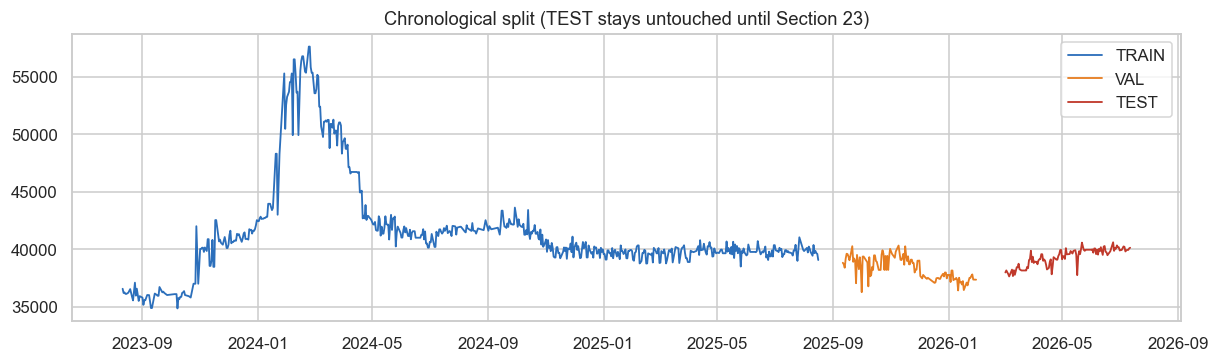

Test guard armed.


In [22]:
N = len(X_all)
EMB = max(HORIZONS)
n_tr = int(N * CFG.train_frac)
n_va = int(N * CFG.val_frac)

tr_idx = np.arange(0, n_tr - EMB)
va_idx = np.arange(n_tr, n_tr + n_va - EMB)
te_idx = np.arange(n_tr + n_va, N - EMB)      # the last EMB rows have no observable target

assert tr_idx.max() < va_idx.min(), "train/val order violated"
assert va_idx.max() < te_idx.min(), "val/test order violated"
assert len(np.intersect1d(tr_idx, va_idx)) == 0 and len(np.intersect1d(va_idx, te_idx)) == 0
assert D_all.iloc[tr_idx].max() < D_all.iloc[va_idx].min() < D_all.iloc[te_idx].min()

SPLIT = {"train": tr_idx, "val": va_idx, "test": te_idx}
for k, v in SPLIT.items():
    print(f"{k.upper():<6} n={len(v):>4}   {D_all.iloc[v].min().date()} -> {D_all.iloc[v].max().date()}")
print(f"embargo rows between blocks: {EMB}")

plt.figure(figsize=(13, 3.4))
for k, c in [("train", "#2c6fbb"), ("val", "#e67e22"), ("test", "#c0392b")]:
    plt.plot(D_all.iloc[SPLIT[k]], P_all.iloc[SPLIT[k]], color=c, lw=1.2, label=k.upper())
plt.title("Chronological split (TEST stays untouched until Section 23)")
plt.legend(); plt.show()


class TestSetGuard:
    """Raises if test indices are requested before the configuration is frozen."""

    def __init__(self):
        self.frozen = True
        self.accesses = 0

    def unlock(self, reason: str):
        self.frozen = False
        print(f"TEST SET UNLOCKED -> {reason}")

    def idx(self):
        if self.frozen:
            raise PermissionError("Test set requested before the configuration was frozen!")
        self.accesses += 1
        return te_idx


TEST_GUARD = TestSetGuard()
print("Test guard armed.")

### Shared metric toolkit

One implementation, used everywhere, so every number in the notebook is comparable.

In [23]:
def rmse(a, b) -> float:
    return float(np.sqrt(mean_squared_error(a, b)))


def directional_stats(y_true_price, y_pred_price, base_price, dead_zone: float = 0.0) -> dict:
    """Direction of the h-step move. The dead zone is applied to the PREDICTED move only,
    which keeps the rule implementable in real time (actuals are unknown at decision time)."""
    y_true_price = np.asarray(y_true_price, float)
    y_pred_price = np.asarray(y_pred_price, float)
    base_price = np.asarray(base_price, float)
    act = y_true_price / base_price - 1.0
    prd = y_pred_price / base_price - 1.0
    take = (np.abs(prd) >= dead_zone) & (act != 0)
    n = int(take.sum())
    out = dict(dead_zone=dead_zone, n_valid=n,
               coverage=float(take.mean()) if len(act) else 0.0,
               dir_acc=np.nan, precision=np.nan, recall=np.nan, f1=np.nan,
               p_value=np.nan, cm=None)
    if n < 5:
        return out
    yt = (act[take] > 0).astype(int)
    yp = (prd[take] > 0).astype(int)
    out["dir_acc"]   = float((yt == yp).mean())
    out["precision"] = float(precision_score(yt, yp, zero_division=0))
    out["recall"]    = float(recall_score(yt, yp, zero_division=0))
    out["f1"]        = float(f1_score(yt, yp, zero_division=0))
    out["cm"]        = confusion_matrix(yt, yp, labels=[0, 1])
    out["p_value"]   = float(st.binomtest(int((yt == yp).sum()), n, 0.5, alternative="greater").pvalue)
    return out


def evaluate(y_true_price, y_pred_price, base_price, dead_zone=0.0, name="model", horizon=None) -> dict:
    y_true_price = np.asarray(y_true_price, float)
    y_pred_price = np.asarray(y_pred_price, float)
    d = directional_stats(y_true_price, y_pred_price, base_price, dead_zone)
    return {"model": name, "horizon": horizon,
            "RMSE": rmse(y_true_price, y_pred_price),
            "MAE": float(mean_absolute_error(y_true_price, y_pred_price)),
            "R2": float(r2_score(y_true_price, y_pred_price)),
            "MAPE%": float(np.mean(np.abs((y_true_price - y_pred_price) / y_true_price)) * 100),
            "DirAcc": d["dir_acc"], "Coverage": d["coverage"], "N_dir": d["n_valid"],
            "Precision": d["precision"], "Recall": d["recall"], "F1": d["f1"],
            "p_value": d["p_value"], "dead_zone": dead_zone}


def leaderboard(rows, sort="RMSE") -> pd.DataFrame:
    t = pd.DataFrame(rows)
    cols = ["model", "horizon", "RMSE", "MAE", "R2", "MAPE%", "DirAcc", "Coverage", "N_dir", "p_value"]
    return t[[c for c in cols if c in t.columns]].sort_values(sort).reset_index(drop=True)


print("Metric toolkit ready.")

Metric toolkit ready.


## 13. Baseline Models

A forecasting model that cannot beat *"the price in h steps is the price now"* is worthless.
Baselines are scored on **validation** here, and re-run on TEST in Section 23.

In [24]:
def baseline_predictions(idx, h: int) -> dict:
    """Predicted price at t+h from classical rules. All inputs are causal."""
    p = P_all.values
    ma5  = P_all.rolling(5,  min_periods=1).mean().values
    ma21 = P_all.rolling(21, min_periods=1).mean().values
    ema  = P_all.ewm(span=10, adjust=False, min_periods=1).mean().values
    drift = (p[idx] - p[np.maximum(idx - 60, 0)]) / 60.0
    return {"Naive (last value)": p[idx],
            "Random Walk": p[idx],
            "Moving Average (5)": ma5[idx],
            "Moving Average (21)": ma21[idx],
            "EMA (10)": ema[idx],
            "Drift (60)": p[idx] + drift * h}


def run_baselines(idx, h: int, tag: str = "VAL") -> list:
    yt = Y_all[f"y_price_h{h}"].values[idx]
    base = P_all.values[idx]
    ok = ~np.isnan(yt)
    rows = [evaluate(yt[ok], np.asarray(pr, float)[ok], base[ok], 0.0, f"{nm} [{tag}]", h)
            for nm, pr in baseline_predictions(idx, h).items()]
    med = X_all.iloc[tr_idx][FEATURES_ALL].median()
    Xtr = X_all.iloc[tr_idx][FEATURES_ALL].fillna(med)
    Xev = X_all.iloc[idx][FEATURES_ALL].fillna(med)
    ytr = Y_all[f"y_logret_h{h}"].values[tr_idx]
    m = ~np.isnan(ytr)
    for nm, mdl in [("Linear Regression", Ridge(alpha=10.0)),
                    ("Random Forest", RandomForestRegressor(n_estimators=300, max_depth=6,
                                                            min_samples_leaf=8,
                                                            random_state=SEED, n_jobs=-1))]:
        mdl.fit(Xtr[m], ytr[m])
        pr = target_to_price(mdl.predict(Xev), base, "logret")
        rows.append(evaluate(yt[ok], pr[ok], base[ok], 0.0, f"{nm} [{tag}]", h))
    return rows


base_rows = []
for h in HORIZONS:
    base_rows += run_baselines(va_idx, h, "VAL")
BASELINE_TABLE = leaderboard(base_rows)
display(BASELINE_TABLE.round(4).style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r"))
NAIVE_VAL = {h: [r for r in base_rows if r["model"].startswith("Naive") and r["horizon"] == h][0]
             for h in HORIZONS}
print("\nNaive validation RMSE by horizon:", {h: round(v["RMSE"], 1) for h, v in NAIVE_VAL.items()})

,model,horizon,RMSE,MAE,R2,MAPE%,DirAcc,Coverage,N_dir,p_value
0,EMA (10) [VAL],1,657.061900,499.056400,0.529500,1.303900,0.700000,0.854700,100,0.000000
1,Moving Average (5) [VAL],1,657.272200,507.919400,0.529200,1.324700,0.720000,0.854700,100,0.000000
2,Random Forest [VAL],1,675.180400,508.091000,0.503200,1.326600,0.710000,0.854700,100,0.000000
3,EMA (10) [VAL],3,693.302700,534.495800,0.480900,1.398600,0.683800,1.000000,117,0.000000
4,Moving Average (5) [VAL],3,693.846000,536.077700,0.480100,1.399800,0.700900,1.000000,117,0.000000
5,Random Forest [VAL],3,702.698100,534.704500,0.466800,1.395700,0.700900,1.000000,117,0.000000
6,Moving Average (21) [VAL],1,742.907000,564.104100,0.398500,1.479100,0.700000,0.854700,100,0.000000
7,Moving Average (5) [VAL],7,749.699800,574.309400,0.371700,1.508200,0.608700,0.982900,115,0.012400
8,EMA (10) [VAL],7,765.318100,580.383900,0.345300,1.524700,0.660900,0.982900,115,0.000400
9,Moving Average (21) [VAL],3,776.470600,585.079000,0.348900,1.535300,0.658100,1.000000,117,0.000400



Naive validation RMSE by horizon: {1: 815.9, 3: 857.4, 7: 892.2, 14: 1072.4, 21: 1048.2}


## 10.7 Train-Only Redundancy Prune of the Egypt Features

Near-collinear features add variance without signal. The screen below is computed on the
**training rows only** - correlations measured over the full sample (test included) and then used
to choose which columns survive would be a quiet form of test-set peeking, exactly the failure mode
this notebook exists to avoid.

For each pair of Egypt features with train |r| > 0.97, the one with the weaker train-only
association to the target return is dropped.

In [25]:
_tr_slice = X_all.iloc[tr_idx]
_tr_tgt_ret = np.log(P_all).diff().iloc[tr_idx]

_egypt_present = [c for c in FEATURES_EGYPT_NEW if c in X_all.columns]
_Ctr = _tr_slice[_egypt_present].corr(min_periods=60).abs()


def _train_signal(col: str) -> float:
    both = _tr_slice[col].notna() & _tr_tgt_ret.notna()
    if both.sum() < 60 or _tr_slice.loc[both, col].std() == 0:
        return 0.0
    return abs(float(np.corrcoef(_tr_slice.loc[both, col], _tr_tgt_ret[both])[0, 1]))


_signal = {c: _train_signal(c) for c in _egypt_present}
_drop = set()
_pairs = []
for _i in range(len(_Ctr)):
    for _j in range(_i + 1, len(_Ctr)):
        _a, _b = _Ctr.index[_i], _Ctr.columns[_j]
        _v = _Ctr.iloc[_i, _j]
        if pd.notna(_v) and _v > 0.97 and _a not in _drop and _b not in _drop:
            _loser = _a if _signal[_a] < _signal[_b] else _b
            _keep = _b if _loser == _a else _a
            _drop.add(_loser)
            _pairs.append(dict(feature_a=_a, feature_b=_b, train_corr=round(float(_v), 4),
                               dropped=_loser, kept=_keep,
                               signal_dropped=round(_signal[_loser], 4),
                               signal_kept=round(_signal[_keep], 4)))

if _pairs:
    print("Near-collinear Egypt feature pairs (TRAIN-only |r| > 0.97):")
    display(pd.DataFrame(_pairs))
else:
    print("No Egypt feature pair exceeds the train-only |r| > 0.97 redundancy threshold.")

REDUNDANT_DROPPED = sorted(_drop)
if REDUNDANT_DROPPED:
    X_all = X_all.drop(columns=REDUNDANT_DROPPED)
    FEATURES_ALL = [c for c in FEATURES_ALL if c not in _drop]
    FEATURES_EGYPT_NEW = [c for c in FEATURES_EGYPT_NEW if c not in _drop]
    EGYPT_FEATURE_GROUPS = {k: [c for c in v if c not in _drop]
                            for k, v in EGYPT_FEATURE_GROUPS.items()}
print(f"\ndropped {len(REDUNDANT_DROPPED)} redundant Egypt features: {REDUNDANT_DROPPED}")
print(f"remaining: {len(FEATURES_EGYPT_NEW)} Egypt features, {len(FEATURES_ALL)} total")
print("\nNOTE: only PAIRWISE-REDUNDANT features are removed here. Weak-signal features are")
print("deliberately NOT hand-dropped - Section 11's consensus ranking (also train-only) is the")
print("mechanism that decides what earns a place in the model.")

Near-collinear Egypt feature pairs (TRAIN-only |r| > 0.97):


,feature_a,feature_b,train_corr,dropped,kept,signal_dropped,signal_kept
0,alu_egp_vol_21,egp_depreciation_ret_21,0.9776,alu_egp_vol_21,egp_depreciation_ret_21,0.0360,0.0365
1,steel_alu_egp_ratio,steel_cop_egp_ratio,0.9888,steel_cop_egp_ratio,steel_alu_egp_ratio,0.0961,0.0998
2,egp_depreciation_ret_21,egp_devaluation_flag,0.9912,egp_devaluation_flag,egp_depreciation_ret_21,0.0335,0.0365



dropped 3 redundant Egypt features: ['alu_egp_vol_21', 'egp_devaluation_flag', 'steel_cop_egp_ratio']
remaining: 51 Egypt features, 368 total

NOTE: only PAIRWISE-REDUNDANT features are removed here. Weak-signal features are
deliberately NOT hand-dropped - Section 11's consensus ranking (also train-only) is the
mechanism that decides what earns a place in the model.


## 11. Feature Selection

Five independent rankings computed **on the training slice only**, blended into a consensus rank.
Candidate subsets (all / consensus-topK / compact / AR-only / macro-only / hybrid) are then compared
on walk-forward validation in Section 14.1.

,mi,corr,xgb_gain,perm,shap,consensus
coal_ret_1m,0.1576,0.1785,0.0888,0.0000,0.0018,0.8777
USD_Buy_mean_7,0.1296,0.2386,0.0053,0.0001,0.0003,0.8777
oil_egp,0.2040,0.2908,0.0047,0.0000,0.0002,0.8739
USD_Buy_vol_45,0.1298,0.2623,0.0051,0.0000,0.0002,0.8576
spread_Stee_Ceme,0.2271,0.1992,0.0385,0.0000,0.0015,0.8568
steel_vol_30,0.1627,0.1331,0.0036,0.0000,0.0009,0.8554
steel_mean_60,0.1891,0.3002,0.0055,0.0000,0.0004,0.8465
steel_z_3,0.0998,0.1863,0.0043,0.0001,0.0017,0.8446
steel_min_60,0.1902,0.2301,0.0133,0.0000,0.0005,0.8438
steel_med_60,0.1700,0.2875,0.0064,0.0000,0.0006,0.8432


all          368 features
topK          45 features
compact       15 features
ar_only      150 features
macro_only   225 features
hybrid        25 features


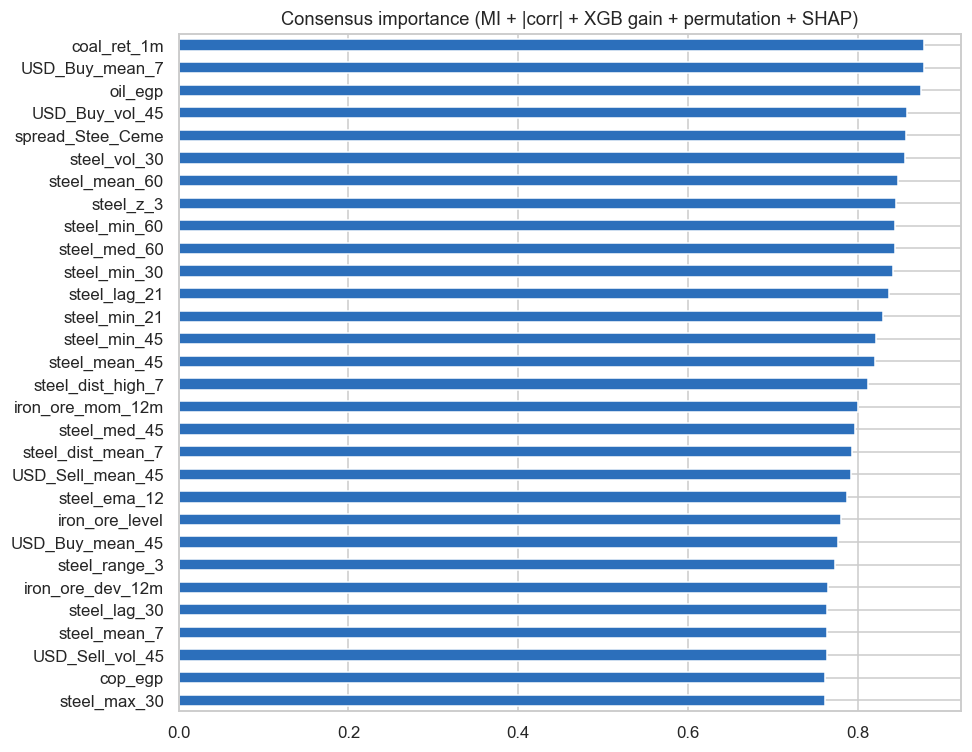

In [26]:
SEL_H = 7          # a mid horizon for ranking; the operating horizon is chosen in 14.1

_ysel = Y_all[f"y_logret_h{SEL_H}"].values[tr_idx]
_msel = ~np.isnan(_ysel)
Xs = X_all.iloc[tr_idx][FEATURES_ALL].iloc[_msel]
ys = _ysel[_msel]
Xs_imp = Xs.fillna(Xs.median()).fillna(0.0)

set_seed()
rank = pd.DataFrame(index=FEATURES_ALL)
rank["mi"] = mutual_info_regression(Xs_imp, ys, random_state=SEED)
rank["corr"] = np.abs([np.corrcoef(Xs_imp[c], ys)[0, 1] if Xs_imp[c].std() > 0 else 0.0
                       for c in FEATURES_ALL])
_xg = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.7, reg_lambda=2.0, random_state=SEED,
                       n_jobs=-1, tree_method="hist")
_xg.fit(Xs, ys)
rank["xgb_gain"] = _xg.feature_importances_

_cut = int(len(Xs) * 0.8)
_xg2 = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.7, random_state=SEED, n_jobs=-1, tree_method="hist")
_xg2.fit(Xs.iloc[:_cut], ys[:_cut])
_pi = permutation_importance(_xg2, Xs_imp.iloc[_cut:], ys[_cut:], n_repeats=5,
                             random_state=SEED, scoring="neg_root_mean_squared_error")
rank["perm"] = _pi.importances_mean
rank["shap"] = np.abs(shap.TreeExplainer(_xg).shap_values(Xs)).mean(0)

rank["consensus"] = rank.rank(pct=True).mean(axis=1)
RANK = rank.sort_values("consensus", ascending=False)
display(RANK.head(25).round(4))

TOP_K   = list(RANK.index[:CFG.top_k_features])
COMPACT = list(RANK.index[:15])
AR_ONLY = [c for c in FEATURES_ALL if c.startswith("steel") or c in
           ("days_since_prev_obs", "gap_roll_mean_5", "gap_roll_max_10",
            "is_after_long_gap", "dow", "dom", "month")]
MACRO   = [c for c in FEATURES_ALL if not c.startswith("steel")]
HYBRID  = list(dict.fromkeys(list(RANK.index[:25])
                             + [c for c in RANK.index if c.startswith("steel")][:15]))

FEATURE_SETS = {"all": FEATURES_ALL, "topK": TOP_K, "compact": COMPACT,
                "ar_only": AR_ONLY, "macro_only": MACRO, "hybrid": HYBRID}
for k, v in FEATURE_SETS.items():
    print(f"{k:<12} {len(v):>3} features")

plt.figure(figsize=(9, 7))
RANK["consensus"].head(30)[::-1].plot(kind="barh", color="#2c6fbb")
plt.title("Consensus importance (MI + |corr| + XGB gain + permutation + SHAP)")
plt.tight_layout(); plt.show()

## 16. Walk-Forward Validation Framework

Expanding-window folds carved out of **TRAIN + VALIDATION only**:

```
fold 1  |=== train ===|--emb--|= val =|
fold 2  |===== train ======|--emb--|= val =|
fold 3  |======== train =========|--emb--|= val =|
fold 4  |=========== train ==========|--emb--|= val =|
```

Preprocessing (imputation medians, scalers) is refitted **inside every fold** on that fold's
training rows only. The Optuna objective is the mean fold RMSE in price space.

In [27]:
def walk_forward_folds(n_folds: int = CFG.n_walk_folds, embargo: int = EMB) -> list:
    """Expanding folds over the TRAIN+VAL region. TEST is never included."""
    dev_end = int(va_idx.max()) + 1
    start_train = int(len(tr_idx) * 0.55)
    edges = np.linspace(start_train, dev_end, n_folds + 1).astype(int)
    folds = []
    for i in range(n_folds):
        a, b = edges[i], edges[i + 1]
        tr = np.arange(0, a - embargo)
        va = np.arange(a, b)
        if len(tr) > 120 and len(va) > 15:
            folds.append((tr, va))
    return folds


FOLDS = walk_forward_folds()
for i, (a, b) in enumerate(FOLDS, 1):
    print(f"fold {i}: train[{a[0]:>4}:{a[-1]:>4}] (n={len(a)})  ->  val[{b[0]:>4}:{b[-1]:>4}] (n={len(b)})   "
          f"{D_all.iloc[b[0]].date()} -> {D_all.iloc[b[-1]].date()}")
assert all(b.max() <= va_idx.max() for _, b in FOLDS), "a walk-forward fold reaches into TEST"
assert all(a.max() < b.min() - EMB + 1 for a, b in FOLDS), "embargo violated inside a fold"
print("\nPASS - no walk-forward fold touches the test region; embargo respected.")


def impute_fold(Xtr_df, Xother_dfs, strategy="ffill_median"):
    """Leakage-safe imputation: every statistic comes from the fold's training rows only.
    Forward-fill propagates past values forward and is therefore causal; bfill is never used."""
    if strategy == "native_nan":
        return Xtr_df, list(Xother_dfs)
    med = Xtr_df.median()

    def _apply(d):
        out = d.copy()
        if strategy in ("ffill", "ffill_median"):
            out = out.ffill()
        if strategy in ("median", "ffill_median"):
            out = out.fillna(med)
        return out.fillna(med).fillna(0.0)

    return _apply(Xtr_df), [_apply(d) for d in Xother_dfs]


print("Walk-forward framework ready.")

fold 1: train[   0: 320] (n=321)  ->  val[ 342: 445] (n=104)   2024-10-11 -> 2025-01-23
fold 2: train[   0: 424] (n=425)  ->  val[ 446: 550] (n=105)   2025-01-24 -> 2025-05-24
fold 3: train[   0: 529] (n=530)  ->  val[ 551: 655] (n=105)   2025-05-25 -> 2025-09-23
fold 4: train[   0: 634] (n=635)  ->  val[ 656: 760] (n=105)   2025-09-24 -> 2026-01-30

PASS - no walk-forward fold touches the test region; embargo respected.
Walk-forward framework ready.


## 14. XGBoost Pipeline

Three flavours, as required:

* **Model A** — direct price regression
* **Model B** — return / log-return regression (mapped back to price)
* **Model C** — direction classification (up/down) with class weighting and threshold tuning

All are scored through the identical price-space metric block.

In [28]:
XGB_STATIC = dict(random_state=SEED, n_jobs=-1, tree_method="hist", verbosity=0)
_INF_ROW = dict(RMSE=np.inf, MAE=np.inf, R2=-9.0, DirAcc=0.5, Coverage=0.0, N_dir=0)


def fit_xgb(Xtr, ytr, Xva, yva, params, classifier=False):
    p = dict(XGB_STATIC, **params)
    n = p.pop("n_estimators", 600)
    Model = xgb.XGBClassifier if classifier else xgb.XGBRegressor
    m = Model(n_estimators=n, early_stopping_rounds=50,
              eval_metric="logloss" if classifier else "rmse", **p)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m


def xgb_fold_score(params, h, kind, feats, strategy="native_nan", folds=None,
                   classifier=False, return_preds=False):
    """Runs one XGBoost config across every walk-forward fold. A fold that fails with a
    resource error (XGBoost internal allocation failure, host out of memory - both real
    possibilities once Optuna samples a large n_estimators/max_depth combination against a
    365-feature matrix) is SKIPPED rather than allowed to crash the whole Optuna study; if every
    fold fails the config gets the standard _INF_ROW penalty so the sampler learns to avoid it."""
    folds = FOLDS if folds is None else folds
    ycol = f"y_{kind}_h{h}"
    scores, oof = [], []
    for tr, va in folds:
        ytr_raw, yva_raw = Y_all[ycol].values[tr], Y_all[ycol].values[va]
        mtr, mva = ~np.isnan(ytr_raw), ~np.isnan(yva_raw)
        Xtr = X_all.iloc[tr][feats].iloc[mtr]
        Xva = X_all.iloc[va][feats].iloc[mva]
        Xtr, (Xva,) = impute_fold(Xtr, [Xva], strategy)
        base_va = P_all.values[va][mva]
        ytrue_p = Y_all[f"y_price_h{h}"].values[va][mva]
        try:
            if classifier:
                ytr = (ytr_raw[mtr] > 0).astype(int)
                yva = (yva_raw[mva] > 0).astype(int)
                if len(np.unique(ytr)) < 2 or len(np.unique(yva)) < 2:
                    continue
                m = fit_xgb(Xtr, ytr, Xva, yva, params, classifier=True)
                proba = m.predict_proba(Xva)[:, 1]
                scores.append({"auc": roc_auc_score(yva, proba),
                               "acc": float(((proba > 0.5).astype(int) == yva).mean())})
                if return_preds:
                    oof.append((va[mva], proba, yva))
                continue
            m = fit_xgb(Xtr, ytr_raw[mtr], Xva, yva_raw[mva], params)
            pred_p = target_to_price(m.predict(Xva), base_va, kind)
            scores.append(evaluate(ytrue_p, pred_p, base_va, 0.0))
            if return_preds:
                oof.append((va[mva], pred_p, ytrue_p))
        except (xgb.core.XGBoostError, MemoryError):
            continue
    S = pd.DataFrame(scores) if scores else pd.DataFrame([_INF_ROW])
    return (S, oof) if return_preds else S


DEFAULT_XGB = dict(n_estimators=600, max_depth=4, learning_rate=0.05, subsample=0.85,
                   colsample_bytree=0.7, min_child_weight=4, gamma=0.0,
                   reg_alpha=0.1, reg_lambda=2.0)
print("XGBoost pipeline ready.")

XGBoost pipeline ready.


## Egypt Feature-Group Ablation Study (Experiments A-G)

Does adding Egyptian-specific data actually help, and which category matters? Each experiment adds
one more feature group **cumulatively**, matching the brief's structure. Two requested categories
(Construction, Industrial) have no genuine Egyptian source (Section 10.6), so they are mapped to
the closest defensible real substitute - labeled explicitly in the experiment name, never silently
renamed - and Trade is reported as unavailable rather than dropped without a trace. Every
experiment is scored identically: walk-forward validation, one fixed default XGBoost
configuration (so differences reflect the DATA, not per-experiment hyper-parameter luck), at the
horizon used for feature-selection ranking (h=7, log-return).

In [29]:
ABLATION_GROUPS = {
    "A: Original": FEATURES_ORIGINAL,
    "B: +FX (EGP-adjusted commodities)": FEATURES_ORIGINAL + EGYPT_FEATURE_GROUPS["EGP-adjusted commodities"],
    "C: +Inflation (Egypt CPI/GDP)": (FEATURES_ORIGINAL + EGYPT_FEATURE_GROUPS["EGP-adjusted commodities"]
                                      + EGYPT_FEATURE_GROUPS["Egypt macro backdrop (CPI/GDP)"]),
    "D: +Construction [-> CBE rate, financing-cost proxy]":
        (FEATURES_ORIGINAL + EGYPT_FEATURE_GROUPS["EGP-adjusted commodities"]
         + EGYPT_FEATURE_GROUPS["Egypt macro backdrop (CPI/GDP)"] + EGYPT_FEATURE_GROUPS["CBE policy rate"]),
    "E: +Industrial [-> global input-cost commodities]":
        (FEATURES_ORIGINAL + EGYPT_FEATURE_GROUPS["EGP-adjusted commodities"]
         + EGYPT_FEATURE_GROUPS["Egypt macro backdrop (CPI/GDP)"] + EGYPT_FEATURE_GROUPS["CBE policy rate"]
         + EGYPT_FEATURE_GROUPS["Global input costs (iron ore/coal/gas)"]),
    "F: +ALL Egypt": FEATURES_ORIGINAL + FEATURES_EGYPT_NEW,
    "+Trade (not available - see 10.6)": None,
}

ABL_H, ABL_KIND = SEL_H, "logret"
abl_rows = []
for _name, _feats in ABLATION_GROUPS.items():
    if _feats is None:
        abl_rows.append(dict(experiment=_name, n_features=0, RMSE=np.nan, MAE=np.nan, R2=np.nan,
                             DirAcc=np.nan, note="excluded - no reliable source found (Section 10.6)"))
        continue
    _S = xgb_fold_score(DEFAULT_XGB, ABL_H, ABL_KIND, _feats, "native_nan")
    abl_rows.append(dict(experiment=_name, n_features=len(_feats), RMSE=_S.RMSE.mean(), MAE=_S.MAE.mean(),
                         R2=_S.R2.mean(), DirAcc=_S.DirAcc.mean(), note=""))

# Experiment G: consensus-selected subset - original + Egypt features ranked TOGETHER by the same
# gain-based criterion used elsewhere, not a separate ad hoc pick.
_Xg = X_all[FEATURES_ORIGINAL + FEATURES_EGYPT_NEW].iloc[tr_idx]
_yg = Y_all[f"y_{ABL_KIND}_h{ABL_H}"].values[tr_idx]
_mg = ~np.isnan(_yg)
_xgg = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.7, reg_lambda=2.0, random_state=SEED, n_jobs=-1, tree_method="hist")
_xgg.fit(_Xg[_mg], _yg[_mg])
_g_rank = pd.Series(_xgg.feature_importances_, index=_Xg.columns).sort_values(ascending=False)
G_SELECTED = list(_g_rank.index[:CFG.top_k_features])
_S_g = xgb_fold_score(DEFAULT_XGB, ABL_H, ABL_KIND, G_SELECTED, "native_nan")
abl_rows.append(dict(experiment="G: +Selected (consensus top-45, Egypt+Original combined)",
                     n_features=len(G_SELECTED), RMSE=_S_g.RMSE.mean(), MAE=_S_g.MAE.mean(),
                     R2=_S_g.R2.mean(), DirAcc=_S_g.DirAcc.mean(), note=""))

ABLATION_TABLE = pd.DataFrame(abl_rows)
display(ABLATION_TABLE.round(4).style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r"))

_valid = ABLATION_TABLE.dropna(subset=["RMSE"])
_best_abl = _valid.loc[_valid.RMSE.idxmin()]
_orig_rmse = ABLATION_TABLE.loc[ABLATION_TABLE.experiment == "A: Original", "RMSE"].iloc[0]
print(f"\nBest feature-group experiment (walk-forward RMSE): '{_best_abl.experiment}' "
      f"({_best_abl.RMSE:.2f} vs Original {_orig_rmse:.2f}, "
      f"{100*(1-_best_abl.RMSE/_orig_rmse):+.2f}% change)")
print("This diagnostic does not override Section 11/14's own feature selection - it only answers")
print("'did adding Egyptian data help, and which category', independently of that selection.")

,experiment,n_features,RMSE,MAE,R2,DirAcc,note
0,A: Original,317,649.304500,494.552800,-0.005600,0.577800,
1,B: +FX (EGP-adjusted commodities),334,643.490300,486.051400,0.008000,0.587500,
2,C: +Inflation (Egypt CPI/GDP),338,666.734100,508.449200,-0.066000,0.587400,
3,"D: +Construction [-> CBE rate, financing-cost proxy]",341,649.940100,492.165900,-0.014800,0.592100,
4,E: +Industrial [-> global input-cost commodities],368,635.723300,483.248500,0.034700,0.592100,
5,F: +ALL Egypt,368,636.489200,480.056700,0.027500,0.594500,
6,+Trade (not available - see 10.6),0,nan,nan,nan,nan,excluded - no reliable source found (Section 10.6)
7,"G: +Selected (consensus top-45, Egypt+Original combined)",45,614.270700,468.281100,0.089300,0.616300,



Best feature-group experiment (walk-forward RMSE): 'G: +Selected (consensus top-45, Egypt+Original combined)' (614.27 vs Original 649.30, +5.40% change)
This diagnostic does not override Section 11/14's own feature selection - it only answers
'did adding Egyptian data help, and which category', independently of that selection.


### 14.1 Screening — horizon × target formulation, then feature set × imputation

One reasonable XGBoost configuration is swept across the design space using **walk-forward
validation only**. This is where "do not assume 1-step is best" is actually settled.

Horizons are compared by **skill ratio** — model RMSE divided by the naive RMSE at the *same*
horizon — because raw RMSE mechanically shrinks as the horizon shortens and would hand the win to
h=1 regardless of merit.

naive walk-forward RMSE by horizon: {1: np.float64(660.6), 3: np.float64(698.1), 7: np.float64(676.7), 14: np.float64(804.2), 21: np.float64(843.5)}


,horizon,kind,RMSE,RMSE_std,naive_RMSE,skill,MAE,R2,DirAcc
0,3,ret,560.466900,90.214100,698.059800,0.802900,441.150200,0.194800,0.696200
1,3,logret,562.294700,90.267700,698.059800,0.805500,443.417200,0.188800,0.674700
2,1,logret,543.753900,121.055000,660.601600,0.823100,415.318700,0.255900,0.716400
3,1,ret,545.609700,118.340100,660.601600,0.825900,416.425800,0.247800,0.708700
4,7,logret,609.845100,85.488000,676.695900,0.901200,463.675400,0.112100,0.640100
5,7,ret,615.793500,82.409100,676.695900,0.910000,469.228100,0.096700,0.645000
6,14,logret,736.724600,138.839100,804.161200,0.916100,565.592600,-0.436400,0.615400
7,14,ret,743.836600,137.468800,804.161200,0.925000,577.140100,-0.480600,0.584200
8,21,ret,824.996300,197.613100,843.533700,0.978000,641.936800,-1.185800,0.593800
9,21,logret,832.997800,231.474000,843.533700,0.987500,648.113400,-1.306400,0.579500


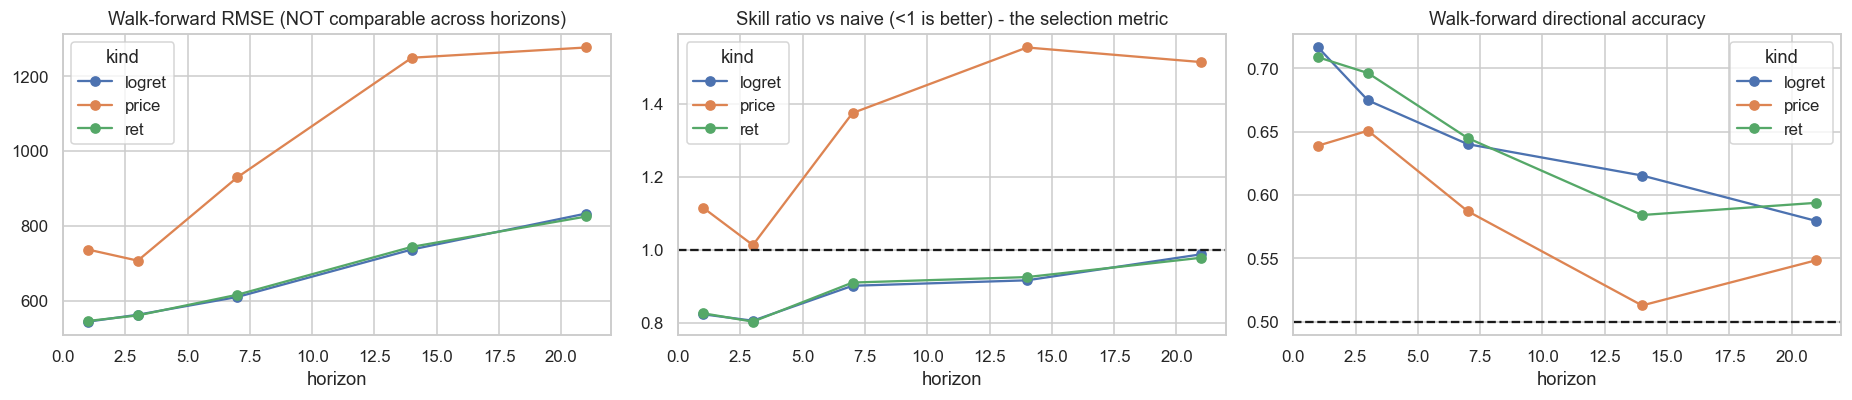

screening took 19s


In [30]:
def naive_fold_score(h, folds=None) -> pd.DataFrame:
    """Walk-forward score of the naive forecast P_hat(t+h) = P_t, per horizon."""
    folds = FOLDS if folds is None else folds
    rows = []
    for _, va in folds:
        yt = Y_all[f"y_price_h{h}"].values[va]
        b = P_all.values[va]
        ok = ~np.isnan(yt)
        rows.append(evaluate(yt[ok], b[ok], b[ok], 0.0))
    return pd.DataFrame(rows)


NAIVE_WF = {h: naive_fold_score(h).RMSE.mean() for h in HORIZONS}
print("naive walk-forward RMSE by horizon:", {k: round(v, 1) for k, v in NAIVE_WF.items()})

t0 = time.time()
screen = []
for h in HORIZONS:
    for kind in CFG.target_kinds:
        S = xgb_fold_score(DEFAULT_XGB, h, kind, TOP_K, "native_nan")
        screen.append(dict(horizon=h, kind=kind,
                           RMSE=S.RMSE.mean(), RMSE_std=S.RMSE.std(),
                           naive_RMSE=NAIVE_WF[h],
                           skill=S.RMSE.mean() / NAIVE_WF[h],
                           MAE=S.MAE.mean(), R2=S.R2.mean(), DirAcc=S.DirAcc.mean()))
SCREEN1 = pd.DataFrame(screen).sort_values("skill").reset_index(drop=True)
display(SCREEN1.round(4).style.background_gradient(subset=["skill"], cmap="RdYlGn_r"))

fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
SCREEN1.pivot(index="horizon", columns="kind", values="RMSE").plot(marker="o", ax=ax[0])
ax[0].set_title("Walk-forward RMSE (NOT comparable across horizons)")
SCREEN1.pivot(index="horizon", columns="kind", values="skill").plot(marker="o", ax=ax[1])
ax[1].axhline(1.0, ls="--", c="k")
ax[1].set_title("Skill ratio vs naive (<1 is better) - the selection metric")
SCREEN1.pivot(index="horizon", columns="kind", values="DirAcc").plot(marker="o", ax=ax[2])
ax[2].axhline(0.5, ls="--", c="k"); ax[2].set_title("Walk-forward directional accuracy")
plt.tight_layout(); plt.show()
print(f"screening took {time.time()-t0:.0f}s")

In [31]:
_best = SCREEN1.iloc[0]
BEST_H, BEST_KIND = int(_best.horizon), str(_best.kind)
print(f"Selected on WALK-FORWARD VALIDATION -> horizon = {BEST_H}, target kind = '{BEST_KIND}'")
print(f"  skill ratio vs naive = {_best.skill:.4f}  (walk-forward DirAcc {_best.DirAcc:.4f})")
print("  Selection uses the SKILL RATIO, not raw RMSE: raw RMSE always falls as the horizon")
print("  shortens, so ranking horizons by RMSE would pick h=1 by construction rather than by merit.")

sweep = []
for fname, feats in FEATURE_SETS.items():
    for strat in ["native_nan", "ffill_median", "median", "ffill"]:
        S = xgb_fold_score(DEFAULT_XGB, BEST_H, BEST_KIND, feats, strat)
        sweep.append(dict(feature_set=fname, n_feat=len(feats), imputation=strat,
                          RMSE=S.RMSE.mean(), MAE=S.MAE.mean(),
                          R2=S.R2.mean(), DirAcc=S.DirAcc.mean()))
SWEEP = pd.DataFrame(sweep).sort_values("RMSE").reset_index(drop=True)
display(SWEEP.round(4).head(12).style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r"))

BEST_FEATSET = str(SWEEP.iloc[0].feature_set)
BEST_IMPUT   = str(SWEEP.iloc[0].imputation)
FEATS        = FEATURE_SETS[BEST_FEATSET]
print(f"Selected feature set = '{BEST_FEATSET}' ({len(FEATS)} features), imputation = '{BEST_IMPUT}'")

Selected on WALK-FORWARD VALIDATION -> horizon = 3, target kind = 'ret'
  skill ratio vs naive = 0.8029  (walk-forward DirAcc 0.6962)
  Selection uses the SKILL RATIO, not raw RMSE: raw RMSE always falls as the horizon
  shortens, so ranking horizons by RMSE would pick h=1 by construction rather than by merit.


,feature_set,n_feat,imputation,RMSE,MAE,R2,DirAcc
0,hybrid,25,ffill_median,554.952100,437.687700,0.200300,0.710600
1,hybrid,25,ffill,554.952100,437.687700,0.200300,0.710600
2,ar_only,150,ffill_median,556.522500,441.107600,0.200200,0.698600
3,ar_only,150,ffill,556.522500,441.107600,0.200200,0.698600
4,all,368,median,557.797100,438.125400,0.181700,0.705700
5,topK,45,ffill_median,558.153100,436.576600,0.200400,0.689100
6,topK,45,ffill,558.153100,436.576600,0.200400,0.689100
7,topK,45,median,559.725700,437.854100,0.199700,0.672200
8,topK,45,native_nan,560.466900,441.150200,0.194800,0.696200
9,ar_only,150,median,561.401500,445.894100,0.183000,0.688900


Selected feature set = 'hybrid' (25 features), imputation = 'ffill_median'


## 17. Optuna — XGBoost study

Objective = mean walk-forward validation RMSE. The test set is not reachable from this code path.

In [32]:
def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 1500, step=100),
        max_depth        = trial.suggest_int("max_depth", 2, 8),
        learning_rate    = trial.suggest_float("learning_rate", 5e-3, 0.25, log=True),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 25),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.3, 1.0),
        gamma            = trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
    )
    S = xgb_fold_score(params, BEST_H, BEST_KIND, FEATS, BEST_IMPUT)
    trial.set_user_attr("DirAcc", float(S.DirAcc.mean()))
    trial.set_user_attr("MAE", float(S.MAE.mean()))
    trial.set_user_attr("R2", float(S.R2.mean()))
    v = float(S.RMSE.mean())
    return v if np.isfinite(v) else 1e12


set_seed()
study_xgb = optuna.create_study(direction="minimize", study_name="xgb",
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=12))
t0 = time.time()
study_xgb.optimize(xgb_objective, n_trials=CFG.n_trials_xgb,
                   timeout=CFG.optuna_timeout_xgb, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
print(f"trials = {len(study_xgb.trials)}   elapsed = {time.time()-t0:.0f}s")
print(f"BEST walk-forward RMSE = {study_xgb.best_value:.2f}")
print("best_xgb_params =", json.dumps(best_xgb_params, indent=2))
print("companion metrics:", study_xgb.best_trial.user_attrs)

trials = 60   elapsed = 60s
BEST walk-forward RMSE = 562.97
best_xgb_params = {
  "n_estimators": 500,
  "max_depth": 3,
  "learning_rate": 0.11167598037026463,
  "min_child_weight": 23,
  "subsample": 0.6163366224205494,
  "colsample_bytree": 0.5078695149341698,
  "gamma": 0.00325990702744516,
  "reg_alpha": 0.013082761377348224,
  "reg_lambda": 0.16523072053904309
}
companion metrics: {'DirAcc': 0.6963827838827839, 'MAE': 443.1109460672608, 'R2': 0.19689692064270095}


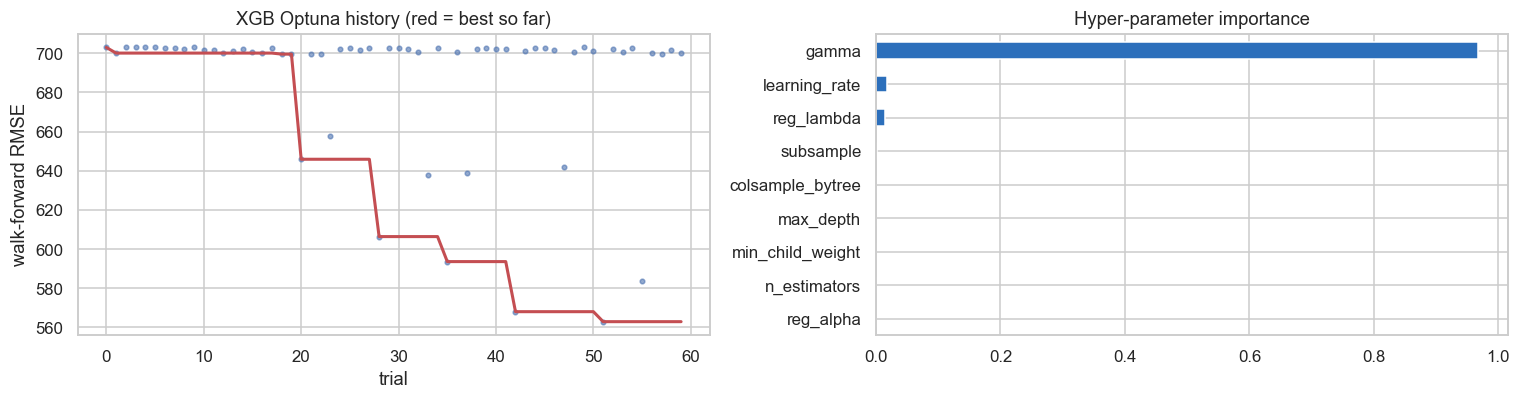

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
vals = [t.value for t in study_xgb.trials if t.value is not None and t.value < 1e11]
ax[0].plot(vals, "o", ms=3, alpha=0.6)
ax[0].plot(pd.Series(vals).cummin(), "r-", lw=2)
ax[0].set_title("XGB Optuna history (red = best so far)")
ax[0].set_xlabel("trial"); ax[0].set_ylabel("walk-forward RMSE")
try:
    pd.Series(optuna.importance.get_param_importances(study_xgb)).sort_values().plot(
        kind="barh", ax=ax[1], color="#2c6fbb")
    ax[1].set_title("Hyper-parameter importance")
except Exception as e:
    ax[1].text(0.05, 0.5, f"importance unavailable:\n{e}")
plt.tight_layout(); plt.show()

### 14.2 Model C — direction classifier

Predicting the sign directly, with `scale_pos_weight` as a tunable class weight and the decision
threshold optimised on validation out-of-fold probabilities.

In [34]:
CLF_KIND = BEST_KIND if BEST_KIND != "price" else "logret"


def xgbclf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 150, 900, step=50),
        max_depth        = trial.suggest_int("max_depth", 2, 6),
        learning_rate    = trial.suggest_float("learning_rate", 5e-3, 0.2, log=True),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 25),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.3, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-2, 30.0, log=True),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 0.5, 2.0),
    )
    S = xgb_fold_score(params, BEST_H, CLF_KIND, FEATS, BEST_IMPUT, classifier=True)
    return float(S["acc"].mean()) if "acc" in S else 0.0


set_seed()
study_clf = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=8))
study_clf.optimize(xgbclf_objective, n_trials=CFG.n_trials_clf,
                   timeout=CFG.optuna_timeout_clf, show_progress_bar=False)
best_clf_params = study_clf.best_params
print(f"Direction classifier - best walk-forward accuracy = {study_clf.best_value:.4f}")
print(json.dumps(best_clf_params, indent=2))

Sclf, oof_clf = xgb_fold_score(best_clf_params, BEST_H, CLF_KIND, FEATS, BEST_IMPUT,
                               classifier=True, return_preds=True)
print("\nWalk-forward classifier folds:")
print(Sclf.round(4).to_string())
print(f"mean AUC = {Sclf['auc'].mean():.4f}   (0.50 = no skill)")

if oof_clf:
    _p = np.concatenate([o[1] for o in oof_clf])
    _y = np.concatenate([o[2] for o in oof_clf])
    thr_rows = [dict(threshold=t,
                     accuracy=float(((_p > t).astype(int) == _y).mean()),
                     coverage=float((np.abs(_p - 0.5) >= abs(t - 0.5)).mean()),
                     f1=f1_score(_y, (_p > t).astype(int), zero_division=0))
                for t in np.arange(0.35, 0.66, 0.05)]
    THR = pd.DataFrame(thr_rows)
    display(THR.round(4))
    BEST_CLF_THR = float(THR.sort_values("accuracy", ascending=False).iloc[0].threshold)
    print(f"Classifier threshold chosen on VALIDATION OOF: {BEST_CLF_THR:.2f}")
else:
    BEST_CLF_THR = 0.5

Direction classifier - best walk-forward accuracy = 0.7159
{
  "n_estimators": 900,
  "max_depth": 3,
  "learning_rate": 0.028611410392071008,
  "min_child_weight": 1,
  "subsample": 0.7886628922719483,
  "colsample_bytree": 0.987382690204117,
  "reg_lambda": 0.3337580256792075,
  "scale_pos_weight": 0.5044289217028894
}



Walk-forward classifier folds:
      auc     acc
0  0.7763  0.6923
1  0.7850  0.6952
2  0.8173  0.7810
3  0.7635  0.6952
mean AUC = 0.7855   (0.50 = no skill)


,threshold,accuracy,coverage,f1
0,0.35,0.6850,0.5943,0.7054
1,0.40,0.7136,0.7661,0.7059
2,0.45,0.7160,0.8878,0.6925
3,0.50,0.7160,1.0000,0.6740
4,0.55,0.6945,0.8878,0.6235
5,0.60,0.6802,0.7661,0.5677
6,0.65,0.6325,0.5943,0.4460


Classifier threshold chosen on VALIDATION OOF: 0.45


## 15. GRU Pipeline

Four architectures behind one interface:

| tag | architecture | note |
|---|---|---|
| `gru`   | 1-layer GRU → MLP head | |
| `gru2`  | stacked GRU (≥2 layers) | |
| `attn`  | GRU + additive attention over encoder states | |
| `bigru` | Bidirectional GRU | **Valid here**: bidirectionality runs over the *past* window $[t-L+1,\,t]$ only. No future timestamp ever enters a sequence — it changes the inductive bias, not the information set. |

Training: AdamW, cosine or plateau LR schedule, gradient clipping, early stopping with
best-checkpoint restoration, mixed precision when CUDA is available, deterministic seeds and
gradient-norm monitoring.

In [35]:
class Attention(nn.Module):
    def __init__(self, hid):
        super().__init__()
        self.proj = nn.Linear(hid, hid)
        self.v = nn.Linear(hid, 1, bias=False)

    def forward(self, H):                                   # H: (B, L, hid)
        w = torch.softmax(self.v(torch.tanh(self.proj(H))).squeeze(-1), dim=1)
        return (H * w.unsqueeze(-1)).sum(1), w


class GRUForecaster(nn.Module):
    def __init__(self, n_feat, hidden=64, layers=1, dropout=0.1, arch="gru", n_out=1):
        super().__init__()
        self.arch = arch
        bidir = arch == "bigru"
        if arch == "gru":
            layers = 1
        elif arch == "gru2":
            layers = max(2, layers)
        self.gru = nn.GRU(n_feat, hidden, num_layers=layers, batch_first=True,
                          dropout=dropout if layers > 1 else 0.0, bidirectional=bidir)
        out_dim = hidden * (2 if bidir else 1)
        self.attn = Attention(out_dim) if arch == "attn" else None
        mid = max(16, out_dim // 2)
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Dropout(dropout),
                                  nn.Linear(out_dim, mid), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(mid, n_out))
        self.n_out = n_out
        self.attn_w = None

    def forward(self, x):
        H, _ = self.gru(x)
        if self.attn is not None:
            z, w = self.attn(H)
            self.attn_w = w.detach()
        else:
            z = H[:, -1, :]
        out = self.head(z)
        return out.squeeze(-1) if self.n_out == 1 else out


def make_sequences(Xmat, y, seq_len: int, valid_rows):
    """A sequence ENDING at row i (inclusive) predicts y[i]. Strictly backward-looking."""
    keep = np.asarray(valid_rows)
    keep = keep[keep >= seq_len - 1]
    keep = keep[~np.isnan(y[keep])]
    if len(keep) == 0:
        return np.empty((0, seq_len, Xmat.shape[1]), np.float32), np.empty(0, np.float32), keep
    S = np.stack([Xmat[i - seq_len + 1:i + 1] for i in keep]).astype(np.float32)
    return S, y[keep].astype(np.float32), keep


SCALERS = {"standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}
print("GRU components ready. device =", DEVICE)

GRU components ready. device = cpu


In [36]:
def train_gru(Str, ytr, Sva, yva, p, n_out=1):
    set_seed(SEED)
    model = GRUForecaster(Str.shape[2], int(p["hidden"]), int(p["layers"]),
                          float(p["dropout"]), p["arch"], n_out=n_out).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=float(p["lr"]), weight_decay=float(p["wd"]))
    if p.get("sched", "cosine") == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.max_epochs)
        step_on_val = False
    else:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
        step_on_val = True
    lossf = nn.HuberLoss() if p.get("loss", "huber") == "huber" else nn.MSELoss()
    amp_scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

    Xtr_t, ytr_t = torch.tensor(Str), torch.tensor(ytr)
    Xva_t, yva_t = torch.tensor(Sva).to(DEVICE), torch.tensor(yva).to(DEVICE)
    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    bs = int(p["batch"])
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=True, drop_last=len(ds) > bs)

    best, best_state, bad, hist = np.inf, None, 0, []
    for ep in range(CFG.max_epochs):
        model.train()
        tot, gsum = 0.0, 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            if USE_AMP:
                with torch.amp.autocast("cuda"):
                    loss = lossf(model(xb), yb)
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(opt)
                g = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                amp_scaler.step(opt); amp_scaler.update()
            else:
                loss = lossf(model(xb), yb)
                loss.backward()
                g = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                opt.step()
            tot += float(loss) * len(xb)
            gsum += float(g)
        model.eval()
        with torch.no_grad():
            pv = model(Xva_t)
            vl = float(nn.functional.mse_loss(pv, yva_t))
            v_rmse = float(torch.sqrt(nn.functional.mse_loss(pv, yva_t)))
            v_mae = float(nn.functional.l1_loss(pv, yva_t))
            pt = model(Xtr_t.to(DEVICE))
            t_rmse = float(torch.sqrt(nn.functional.mse_loss(pt, ytr_t.to(DEVICE))))
            t_mae = float(nn.functional.l1_loss(pt, ytr_t.to(DEVICE)))
        hist.append(dict(epoch=ep, train_loss=tot / max(1, len(ds)), val_loss=vl,
                         train_rmse=t_rmse, val_rmse=v_rmse, train_mae=t_mae, val_mae=v_mae,
                         grad_norm=gsum / max(1, len(dl)), lr=opt.param_groups[0]["lr"]))
        if step_on_val:
            sched.step(vl)
        else:
            sched.step()
        if vl < best - 1e-12:
            best, bad = vl, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG.patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best


def gru_predict(model, S, bs=512):
    if len(S) == 0:
        return np.empty(0)
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(S), bs):
            out.append(model(torch.tensor(S[i:i + bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)


def gru_fold_score(p, h=None, kind=None, feats=None, folds=None, return_preds=False):
    h = BEST_H if h is None else h
    kind = BEST_KIND if kind is None else kind
    feats = GRU_FEATS if feats is None else feats
    folds = FOLDS if folds is None else folds
    y = Y_all[f"y_{kind}_h{h}"].values
    L = int(p["seq_len"])
    rows, oof = [], []
    for tr, va in folds:
        Xtr_df, (Xfull,) = impute_fold(X_all.iloc[tr][feats], [X_all[feats]], "ffill_median")
        fsc = SCALERS[p.get("scaler", "standard")]().fit(Xtr_df.values)
        Xmat = np.clip(np.nan_to_num(fsc.transform(Xfull.values).astype(np.float32)), -10, 10)
        ytr_valid = y[tr][~np.isnan(y[tr])]
        if len(ytr_valid) < 50:
            continue
        ysc = StandardScaler().fit(ytr_valid.reshape(-1, 1))
        yz = np.full_like(y, np.nan, dtype=float)
        ok = ~np.isnan(y)
        yz[ok] = ysc.transform(y[ok].reshape(-1, 1)).ravel()
        Str, ytr_s, _ = make_sequences(Xmat, yz, L, tr)
        Sva, yva_s, kva = make_sequences(Xmat, yz, L, va)
        if len(Str) < 60 or len(Sva) < 10:
            continue
        model, _, _ = train_gru(Str, ytr_s, Sva, yva_s, p)
        pred = ysc.inverse_transform(gru_predict(model, Sva).reshape(-1, 1)).ravel()
        base = P_all.values[kva]
        ytrue = Y_all[f"y_price_h{h}"].values[kva]
        pred_p = target_to_price(pred, base, kind)
        rows.append(evaluate(ytrue, pred_p, base, 0.0))
        if return_preds:
            oof.append((kva, pred_p, ytrue))
    S = pd.DataFrame(rows) if rows else pd.DataFrame([_INF_ROW])
    return (S, oof) if return_preds else S


GRU_FEATS = TOP_K[:60]
print(f"The GRU consumes {len(GRU_FEATS)} features (sequence models need a compact input).")

The GRU consumes 45 features (sequence models need a compact input).


### 15.1 Scaler and architecture screening (validation only)

In [37]:
_probe = dict(seq_len=14, hidden=64, layers=1, dropout=0.15, lr=1e-3, wd=1e-4,
              batch=32, arch="gru", scaler="standard", loss="huber", sched="cosine")

scaler_rows = []
for sc in ["standard", "robust", "minmax"]:
    S = gru_fold_score({**_probe, "scaler": sc})
    scaler_rows.append(dict(scaler=sc, RMSE=S.RMSE.mean(), MAE=S.MAE.mean(), DirAcc=S.DirAcc.mean()))
SCALER_TABLE = pd.DataFrame(scaler_rows).sort_values("RMSE").reset_index(drop=True)
display(SCALER_TABLE.round(4))
BEST_SCALER = str(SCALER_TABLE.iloc[0].scaler)
print("selected scaler:", BEST_SCALER)

arch_rows = []
for a in ["gru", "gru2", "attn", "bigru"]:
    S = gru_fold_score({**_probe, "scaler": BEST_SCALER, "arch": a, "layers": 2 if a == "gru2" else 1})
    arch_rows.append(dict(arch=a, RMSE=S.RMSE.mean(), MAE=S.MAE.mean(),
                          R2=S.R2.mean(), DirAcc=S.DirAcc.mean()))
ARCH_TABLE = pd.DataFrame(arch_rows).sort_values("RMSE").reset_index(drop=True)
display(ARCH_TABLE.round(4).style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r"))

,scaler,RMSE,MAE,DirAcc
0,standard,546.8779,432.7759,0.7082
1,minmax,555.0759,441.4347,0.7059
2,robust,579.2460,452.0535,0.6748


selected scaler: standard


,arch,RMSE,MAE,R2,DirAcc
0,gru,546.877900,432.775900,0.230200,0.708200
1,bigru,550.036100,431.751500,0.219800,0.715500
2,gru2,550.046400,435.443000,0.238800,0.713000
3,attn,659.341500,524.574700,-0.088500,0.614900


### 17.2 Optuna — GRU study

Search space exactly as specified: sequence length ∈ {5,7,10,14,21,30,45,60}, hidden ∈
{32,64,96,128,256}, layers 1–3, dropout 0.05–0.50, lr 1e-5–5e-3, plus weight decay, batch size,
loss (Huber vs MSE), scheduler and architecture.

trials = 25   elapsed = 2891s
BEST walk-forward RMSE = 535.20
best_gru_params = {
  "arch": "bigru",
  "seq_len": 30,
  "hidden": 128,
  "layers": 2,
  "dropout": 0.11282443697043026,
  "lr": 0.0006321168555390339,
  "wd": 0.0023383118973294655,
  "batch": 16,
  "loss": "mse",
  "sched": "cosine",
  "scaler": "standard"
}
companion metrics: {'DirAcc': 0.701098901098901, 'MAE': 423.16713798623675}


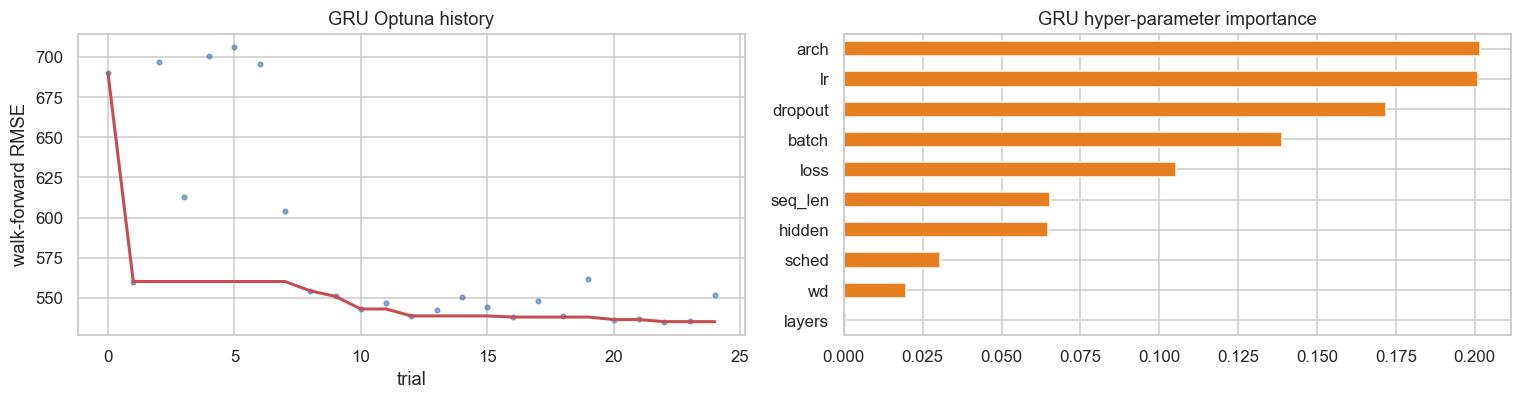

In [38]:
def gru_objective(trial):
    p = dict(
        arch    = trial.suggest_categorical("arch", ["gru", "gru2", "attn", "bigru"]),
        seq_len = trial.suggest_categorical("seq_len", [5, 7, 10, 14, 21, 30, 45, 60]),
        hidden  = trial.suggest_categorical("hidden", [32, 64, 96, 128, 256]),
        layers  = trial.suggest_int("layers", 1, 3),
        dropout = trial.suggest_float("dropout", 0.05, 0.50),
        lr      = trial.suggest_float("lr", 1e-5, 5e-3, log=True),
        wd      = trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        batch   = trial.suggest_categorical("batch", [16, 32, 64, 128]),
        loss    = trial.suggest_categorical("loss", ["huber", "mse"]),
        sched   = trial.suggest_categorical("sched", ["cosine", "plateau"]),
        scaler  = BEST_SCALER,
    )
    S = gru_fold_score(p)
    trial.set_user_attr("DirAcc", float(S.DirAcc.mean()))
    trial.set_user_attr("MAE", float(S.MAE.mean()))
    v = float(S.RMSE.mean())
    return v if np.isfinite(v) else 1e12


set_seed()
study_gru = optuna.create_study(direction="minimize", study_name="gru",
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=8))
t0 = time.time()
study_gru.optimize(gru_objective, n_trials=CFG.n_trials_gru,
                   timeout=CFG.optuna_timeout_gru, show_progress_bar=False)
best_gru_params = dict(study_gru.best_params, scaler=BEST_SCALER)
print(f"trials = {len(study_gru.trials)}   elapsed = {time.time()-t0:.0f}s")
print(f"BEST walk-forward RMSE = {study_gru.best_value:.2f}")
print("best_gru_params =", json.dumps(best_gru_params, indent=2))
print("companion metrics:", study_gru.best_trial.user_attrs)

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
vals = [t.value for t in study_gru.trials if t.value is not None and t.value < 1e11]
ax[0].plot(vals, "o", ms=3, alpha=0.6)
ax[0].plot(pd.Series(vals).cummin(), "r-", lw=2)
ax[0].set_title("GRU Optuna history"); ax[0].set_xlabel("trial"); ax[0].set_ylabel("walk-forward RMSE")
try:
    pd.Series(optuna.importance.get_param_importances(study_gru)).sort_values().plot(
        kind="barh", ax=ax[1], color="#e67e22")
    ax[1].set_title("GRU hyper-parameter importance")
except Exception as e:
    ax[1].text(0.05, 0.5, str(e))
plt.tight_layout(); plt.show()

### 15.2 GRU-Attention, explicitly

The study may or may not have landed on `attn`. Both the tuned winner and an explicit attention
variant are carried forward so the leaderboard can show them side by side.

In [39]:
best_attn_params = dict(best_gru_params, arch="attn")
S_gru = gru_fold_score(best_gru_params)
S_attn = gru_fold_score(best_attn_params)
print(f"Tuned GRU (arch = {best_gru_params['arch']}) walk-forward folds:")
display(S_gru[["RMSE", "MAE", "R2", "DirAcc"]].round(4))
print("GRU + Attention walk-forward folds:")
display(S_attn[["RMSE", "MAE", "R2", "DirAcc"]].round(4))

Tuned GRU (arch = bigru) walk-forward folds:


,RMSE,MAE,R2,DirAcc
0,455.5412,370.7591,0.5517,0.7212
1,512.9925,418.4557,-0.0808,0.6857
2,484.2468,348.3852,0.1188,0.7404
3,688.0308,555.0685,0.4601,0.6571


GRU + Attention walk-forward folds:


,RMSE,MAE,R2,DirAcc
0,630.0168,527.8593,0.1425,0.5769
1,702.5840,583.3251,-1.0273,0.5048
2,595.5057,466.6000,-0.3326,0.5481
3,855.3111,653.8545,0.1656,0.5429


### 12(b). Training-curve diagnostics on the last development fold

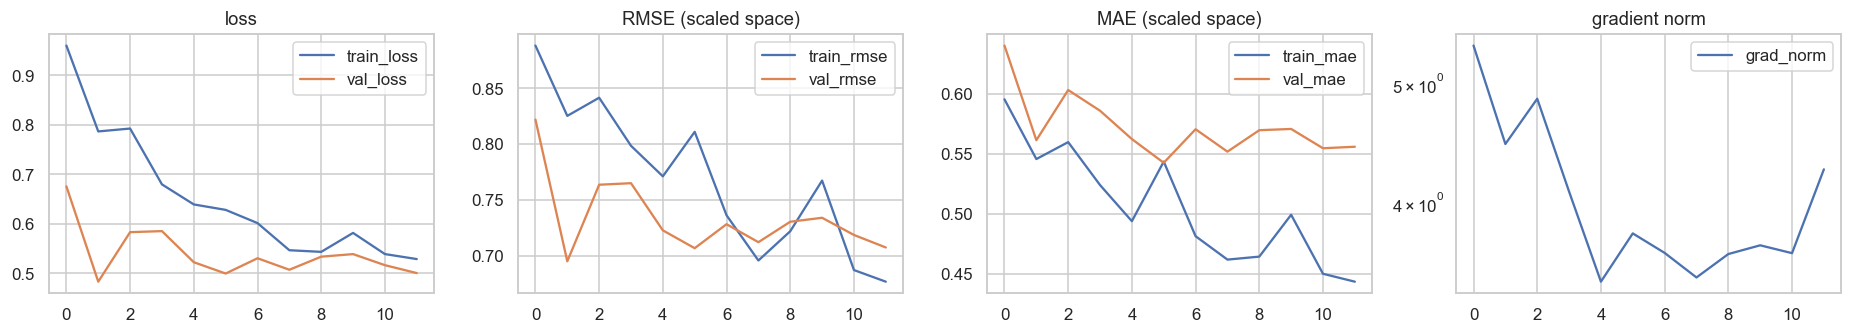

stopped after 12 epochs (patience=10); best validation loss = 0.48286


In [40]:
_tr, _va = FOLDS[-1]
_p = best_gru_params
_Xtr_df, (_Xfull,) = impute_fold(X_all.iloc[_tr][GRU_FEATS], [X_all[GRU_FEATS]], "ffill_median")
_fsc = SCALERS[_p["scaler"]]().fit(_Xtr_df.values)
_Xm = np.clip(np.nan_to_num(_fsc.transform(_Xfull.values).astype(np.float32)), -10, 10)
_y = Y_all[f"y_{BEST_KIND}_h{BEST_H}"].values
_ysc = StandardScaler().fit(_y[_tr][~np.isnan(_y[_tr])].reshape(-1, 1))
_yz = np.full_like(_y, np.nan, float)
_ok = ~np.isnan(_y)
_yz[_ok] = _ysc.transform(_y[_ok].reshape(-1, 1)).ravel()
_Str, _ytr, _ = make_sequences(_Xm, _yz, int(_p["seq_len"]), _tr)
_Sva, _yva, _ = make_sequences(_Xm, _yz, int(_p["seq_len"]), _va)
_m, HIST, _ = train_gru(_Str, _ytr, _Sva, _yva, _p)

fig, ax = plt.subplots(1, 4, figsize=(17, 3.2))
HIST[["train_loss", "val_loss"]].plot(ax=ax[0], title="loss")
HIST[["train_rmse", "val_rmse"]].plot(ax=ax[1], title="RMSE (scaled space)")
HIST[["train_mae", "val_mae"]].plot(ax=ax[2], title="MAE (scaled space)")
HIST[["grad_norm"]].plot(ax=ax[3], title="gradient norm")
ax[3].set_yscale("log")
plt.tight_layout(); plt.show()
print(f"stopped after {len(HIST)} epochs (patience={CFG.patience}); "
      f"best validation loss = {HIST.val_loss.min():.5f}")

## 15.3 Direct vs Recursive vs Multi-output forecasting

* **Direct** — one model per horizon (the default above).
* **Recursive** — a 1-step model applied *h* times. Exogenous markets cannot be rolled forward
  honestly, so the recursive path uses the autoregressive-only feature set and compounds the
  1-step expectation.
* **Multi-output** — one GRU head emitting all horizons simultaneously.

Compared on walk-forward validation only.

In [41]:
def recursive_xgb_score(params, h, folds=None):
    """1-step log-return model compounded h times."""
    folds = FOLDS if folds is None else folds
    feats = [c for c in AR_ONLY if c in X_all.columns]
    y1 = Y_all["y_logret_h1"].values
    rows = []
    for tr, va in folds:
        mtr, mva = ~np.isnan(y1[tr]), ~np.isnan(y1[va])
        Xtr = X_all.iloc[tr][feats].iloc[mtr]
        Xva_all = X_all.iloc[va][feats]
        Xtr, (Xva_all,) = impute_fold(Xtr, [Xva_all], "ffill_median")
        mdl = fit_xgb(Xtr, y1[tr][mtr], Xva_all.iloc[mva], y1[va][mva], params)
        cum = mdl.predict(Xva_all) * h              # compounded 1-step expectation
        base = P_all.values[va]
        ytrue = Y_all[f"y_price_h{h}"].values[va]
        ok = ~np.isnan(ytrue)
        rows.append(evaluate(ytrue[ok], target_to_price(cum, base, "logret")[ok], base[ok], 0.0))
    return pd.DataFrame(rows) if rows else pd.DataFrame([_INF_ROW])


def multioutput_gru_score(p, folds=None):
    """One GRU predicting every horizon at once; scored at BEST_H."""
    folds = FOLDS if folds is None else folds
    Ymat = Y_all[[f"y_{BEST_KIND}_h{h}" for h in HORIZONS]].values
    rowok = ~np.isnan(Ymat).any(1)
    L = int(p["seq_len"])
    hpos = HORIZONS.index(BEST_H)
    rows = []
    for tr, va in folds:
        Xtr_df, (Xfull,) = impute_fold(X_all.iloc[tr][GRU_FEATS], [X_all[GRU_FEATS]], "ffill_median")
        fsc = SCALERS[p["scaler"]]().fit(Xtr_df.values)
        Xm = np.clip(np.nan_to_num(fsc.transform(Xfull.values).astype(np.float32)), -10, 10)
        ysc = StandardScaler().fit(Ymat[tr][rowok[tr]])
        Yz = np.full_like(Ymat, np.nan, float)
        Yz[rowok] = ysc.transform(Ymat[rowok])

        def seqs(idx):
            keep = idx[(idx >= L - 1) & rowok[idx]]
            if len(keep) == 0:
                return None, None, keep
            return (np.stack([Xm[i - L + 1:i + 1] for i in keep]).astype(np.float32),
                    Yz[keep].astype(np.float32), keep)

        Str, Ytr, _ = seqs(tr)
        Sva, Yva, kva = seqs(va)
        if Str is None or Sva is None or len(Str) < 60 or len(Sva) < 10:
            continue
        model, _, _ = train_gru(Str, Ytr, Sva, Yva, p, n_out=len(HORIZONS))
        pr = ysc.inverse_transform(gru_predict(model, Sva))[:, hpos]
        base = P_all.values[kva]
        ytrue = Y_all[f"y_price_h{BEST_H}"].values[kva]
        rows.append(evaluate(ytrue, target_to_price(pr, base, BEST_KIND), base, 0.0))
    return pd.DataFrame(rows) if rows else pd.DataFrame([_INF_ROW])


S_direct = xgb_fold_score(best_xgb_params, BEST_H, BEST_KIND, FEATS, BEST_IMPUT)
S_recur = recursive_xgb_score(best_xgb_params, BEST_H)
S_multi = multioutput_gru_score(best_gru_params)
STRATEGY_TABLE = pd.DataFrame([
    dict(strategy="Direct (XGB)", RMSE=S_direct.RMSE.mean(), MAE=S_direct.MAE.mean(), DirAcc=S_direct.DirAcc.mean()),
    dict(strategy="Recursive (XGB 1-step)", RMSE=S_recur.RMSE.mean(), MAE=S_recur.MAE.mean(), DirAcc=S_recur.DirAcc.mean()),
    dict(strategy="Multi-output (GRU)", RMSE=S_multi.RMSE.mean(), MAE=S_multi.MAE.mean(), DirAcc=S_multi.DirAcc.mean()),
]).sort_values("RMSE").reset_index(drop=True)
display(STRATEGY_TABLE.round(4))
BEST_STRATEGY = str(STRATEGY_TABLE.iloc[0].strategy)
print("Selected forecasting strategy (validation only):", BEST_STRATEGY)

,strategy,RMSE,MAE,DirAcc
0,Multi-output (GRU),550.8067,434.3073,0.6747
1,Direct (XGB),562.9731,443.1109,0.6964
2,Recursive (XGB 1-step),760.2277,580.3377,0.6699


Selected forecasting strategy (validation only): Multi-output (GRU)


## 18. Ensemble & Stacking

Weights are searched on **out-of-fold walk-forward predictions**, never on TEST:

1. a coarse grid 0.0 … 1.0 in steps of 0.1 (XGB vs GRU),
2. a constrained continuous optimisation (SLSQP, weights ≥ 0, Σw = 1) over {XGB, GRU, GRU-Attention},
3. a **stacked** ridge meta-model taking the three OOF predictions plus a few engineered features.

The combiner itself (weighted vs stacked) is chosen on a held-out *later half* of the OOF rows.

In [42]:
def oof_frame(oof_list) -> pd.DataFrame:
    idx = np.concatenate([o[0] for o in oof_list])
    prd = np.concatenate([o[1] for o in oof_list])
    tru = np.concatenate([o[2] for o in oof_list])
    return pd.DataFrame({"idx": idx, "pred": prd, "true": tru}).groupby("idx").last()


_, oof_xgb = xgb_fold_score(best_xgb_params, BEST_H, BEST_KIND, FEATS, BEST_IMPUT, return_preds=True)
_, oof_gru = gru_fold_score(best_gru_params, return_preds=True)
_, oof_attn = gru_fold_score(best_attn_params, return_preds=True)

OOF = (oof_frame(oof_xgb).rename(columns={"pred": "xgb"})
       .join(oof_frame(oof_gru).rename(columns={"pred": "gru"})[["gru"]], how="inner")
       .join(oof_frame(oof_attn).rename(columns={"pred": "attn"})[["attn"]], how="inner"))
OOF["base"] = P_all.values[OOF.index.values]
print("out-of-fold rows available for weight fitting:", len(OOF))
display(OOF.head())

grid = []
for w in np.round(np.arange(0.0, 1.01, 0.1), 2):
    pr = w * OOF.gru + (1 - w) * OOF.xgb
    grid.append(dict(w_gru=w, w_xgb=round(1 - w, 2), RMSE=rmse(OOF.true, pr),
                     DirAcc=directional_stats(OOF.true, pr, OOF.base)["dir_acc"]))
GRID = pd.DataFrame(grid)
display(GRID.round(4).style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r"))

M = OOF[["xgb", "gru", "attn"]].values
t = OOF.true.values
res = minimize(lambda w: rmse(t, M @ w), np.repeat(1 / 3, 3), method="SLSQP",
               bounds=[(0, 1)] * 3, constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
W_OPT = np.clip(res.x, 0, None)
W_OPT = W_OPT / W_OPT.sum()
ENS_W = dict(zip(["xgb", "gru", "attn"], np.round(W_OPT, 4).tolist()))
print("optimal ensemble weights (validation OOF):", ENS_W, f"-> RMSE {rmse(t, M @ W_OPT):.2f}")

meta_feats = [c for c in ["steel_ret_1", "steel_vol_ratio", "steel_rsi_14", "days_since_prev_obs"]
              if c in X_all.columns]
Zs = np.column_stack([M, X_all.iloc[OOF.index.values][meta_feats].fillna(0).values])
half = len(Zs) // 2                      # chronological inner split for combiner choice
meta = Ridge(alpha=1.0).fit(Zs[:half], t[:half])
stack_late = rmse(t[half:], meta.predict(Zs[half:]))
wavg_late = rmse(t[half:], M[half:] @ W_OPT)
print(f"stacked meta-model RMSE on the later OOF half : {stack_late:.2f}")
print(f"weighted ensemble RMSE on the same rows       : {wavg_late:.2f}")
USE_STACK = bool(stack_late < wavg_late)
if USE_STACK:
    meta = Ridge(alpha=1.0).fit(Zs, t)   # refit on all OOF rows once the combiner is chosen
print("selected combiner:", "STACKING" if USE_STACK else "WEIGHTED AVERAGE")

out-of-fold rows available for weight fitting: 419


,xgb,true,gru,attn,base
idx,,,,,
342,41481.740914,41379.0,41372.221578,41591.230069,41668.0
343,41446.469584,40887.0,41440.533940,41212.967838,41290.0
344,42551.674218,41494.0,42121.637838,43327.154588,43411.0
345,42189.702770,41360.0,41290.924942,41295.261591,41379.0
346,42176.282120,41609.0,41551.536645,40800.264590,40887.0


,w_gru,w_xgb,RMSE,DirAcc
0,0.000000,1.000000,571.567900,0.696200
1,0.100000,0.900000,565.698900,0.696200
2,0.200000,0.800000,560.460800,0.703300
3,0.300000,0.700000,555.871400,0.708100
4,0.400000,0.600000,551.946900,0.708100
5,0.500000,0.500000,548.701500,0.698600
6,0.600000,0.400000,546.147400,0.698600
7,0.700000,0.300000,544.294300,0.708100
8,0.800000,0.200000,543.149400,0.705700
9,0.900000,0.100000,542.717100,0.701000


optimal ensemble weights (validation OOF): {'xgb': 0.0895, 'gru': 0.9105, 'attn': 0.0} -> RMSE 542.71
stacked meta-model RMSE on the later OOF half : 691.65
weighted ensemble RMSE on the same rows       : 595.29
selected combiner: WEIGHTED AVERAGE


## 19. Directional Accuracy & Dead-Zone Selection

Directional accuracy is computed from **returns**, not raw price levels:

$$\text{actual}_t = \frac{P_{t+h}}{P_t}-1, \qquad \widehat{\text{pred}}_t = \frac{\hat P_{t+h}}{P_t}-1$$

The dead zone suppresses signals whose *predicted* move is below the threshold — applied to
predictions, not actuals, so the rule is implementable in real time. Every threshold is reported;
the operating point is chosen on validation OOF under an explicit **coverage floor of 30%**, so a
"90% accurate at 3% coverage" illusion cannot win.

,dead_zone,n_valid,coverage,dir_acc,precision,recall,f1,p_value,tag
0,0.000000,418,0.997600,0.705700,0.689500,0.671800,0.680500,0.000000,ensemble OOF
1,0.001000,394,0.940300,0.715700,0.697800,0.690200,0.694000,0.000000,ensemble OOF
2,0.003000,335,0.799500,0.752200,0.730800,0.735500,0.733100,0.000000,ensemble OOF
3,0.005000,270,0.644400,0.785200,0.765600,0.777800,0.771700,0.000000,ensemble OOF
4,0.010000,152,0.362800,0.848700,0.839100,0.890200,0.863900,0.000000,ensemble OOF


Selected dead zone (validation, coverage floor 30%): 1.000%


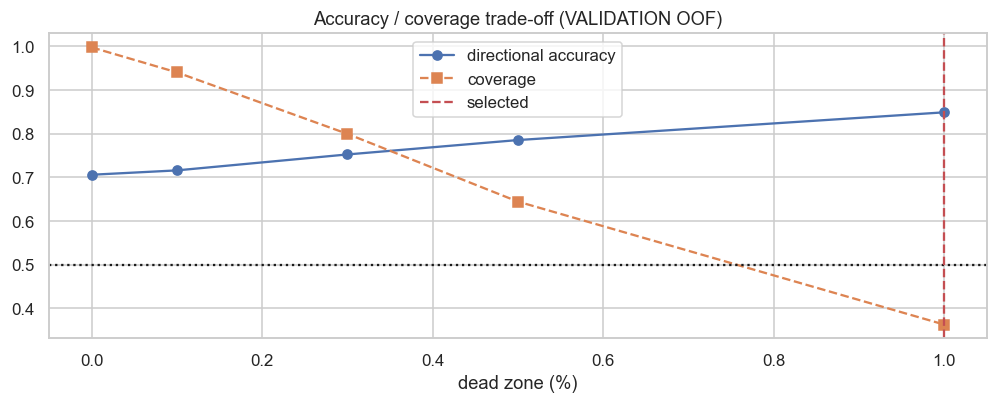

In [43]:
def dead_zone_table(y_true, y_pred, base, zones=CFG.dead_zones, tag="") -> pd.DataFrame:
    rows = []
    for z in zones:
        d = directional_stats(y_true, y_pred, base, z)
        d.pop("cm")
        d["tag"] = tag
        rows.append(d)
    return pd.DataFrame(rows)


ens_oof = meta.predict(Zs) if USE_STACK else M @ W_OPT
DZ_VAL = dead_zone_table(OOF.true.values, ens_oof, OOF.base.values, tag="ensemble OOF")
display(DZ_VAL.round(4).style.background_gradient(subset=["dir_acc"], cmap="RdYlGn"))

_ok = DZ_VAL[(DZ_VAL.coverage >= CFG.coverage_floor) & DZ_VAL.dir_acc.notna()]
BEST_DZ = float((_ok if len(_ok) else DZ_VAL).sort_values("dir_acc", ascending=False).iloc[0].dead_zone)
print(f"Selected dead zone (validation, coverage floor {CFG.coverage_floor:.0%}): {BEST_DZ:.3%}")

plt.figure(figsize=(11, 3.6))
plt.plot(DZ_VAL.dead_zone * 100, DZ_VAL.dir_acc, "o-", label="directional accuracy")
plt.plot(DZ_VAL.dead_zone * 100, DZ_VAL.coverage, "s--", label="coverage")
plt.axhline(0.5, c="k", ls=":")
plt.axvline(BEST_DZ * 100, c="r", ls="--", label="selected")
plt.xlabel("dead zone (%)"); plt.legend()
plt.title("Accuracy / coverage trade-off (VALIDATION OOF)")
plt.show()

## 21. Regime-Aware Modelling

Regimes are built from **trailing** realised volatility only — future volatility never defines the
current regime. The question "does an explicit regime feature help?" is answered on walk-forward
validation, before the test set is opened.

In [44]:
vol = np.log(P_all).diff().rolling(21, min_periods=5).std()          # causal, aligned to X_all
_vz = ((vol - vol.rolling(120, min_periods=20).mean())
       / vol.rolling(120, min_periods=20).std().replace(0, np.nan))
X_all["_regime_z"] = _vz.replace([np.inf, -np.inf], np.nan).values

S_no = xgb_fold_score(best_xgb_params, BEST_H, BEST_KIND, FEATS, BEST_IMPUT)
S_reg = xgb_fold_score(best_xgb_params, BEST_H, BEST_KIND, list(FEATS) + ["_regime_z"], BEST_IMPUT)
REGIME_CHECK = pd.DataFrame([
    dict(variant="without regime feature", RMSE=S_no.RMSE.mean(), DirAcc=S_no.DirAcc.mean()),
    dict(variant="with regime feature", RMSE=S_reg.RMSE.mean(), DirAcc=S_reg.DirAcc.mean()),
])
display(REGIME_CHECK.round(4))
REGIME_HELPS = bool(S_reg.RMSE.mean() < S_no.RMSE.mean())
if REGIME_HELPS:
    FEATS = list(FEATS) + ["_regime_z"]
    print("Regime feature IMPROVES walk-forward RMSE -> adopted into the frozen feature set.")
else:
    X_all = X_all.drop(columns=["_regime_z"])
    print("Regime feature does NOT help -> dropped; the frozen feature set is unchanged.")

,variant,RMSE,DirAcc
0,without regime feature,562.9731,0.6964
1,with regime feature,556.6845,0.7011


Regime feature IMPROVES walk-forward RMSE -> adopted into the frozen feature set.


## 23. FINAL TEST EVALUATION

Everything is now frozen:

| decision | chosen on |
|---|---|
| horizon, target formulation | walk-forward validation |
| feature set, imputation strategy | walk-forward validation |
| GRU scaler and architecture | walk-forward validation |
| XGB / GRU hyper-parameters | Optuna on walk-forward validation |
| ensemble combiner + weights | validation out-of-fold |
| directional dead zone | validation out-of-fold |

The guard is unlocked exactly once, here. The final models are refit on **TRAIN + VALIDATION**.

In [45]:
VAL_LEADER = pd.DataFrame([
    dict(model="XGBoost (tuned)", RMSE=S_direct.RMSE.mean(), MAE=S_direct.MAE.mean(),
         R2=S_direct.R2.mean(), DirAcc=S_direct.DirAcc.mean()),
    dict(model=f"GRU ({best_gru_params['arch']})", RMSE=S_gru.RMSE.mean(), MAE=S_gru.MAE.mean(),
         R2=S_gru.R2.mean(), DirAcc=S_gru.DirAcc.mean()),
    dict(model="GRU + Attention", RMSE=S_attn.RMSE.mean(), MAE=S_attn.MAE.mean(),
         R2=S_attn.R2.mean(), DirAcc=S_attn.DirAcc.mean()),
    dict(model="Ensemble (OOF)", RMSE=rmse(OOF.true, ens_oof),
         MAE=mean_absolute_error(OOF.true, ens_oof), R2=r2_score(OOF.true, ens_oof),
         DirAcc=directional_stats(OOF.true, ens_oof, OOF.base, BEST_DZ)["dir_acc"]),
]).sort_values("RMSE").reset_index(drop=True)
print("WALK-FORWARD VALIDATION leaderboard - the winner is taken from HERE, not from the test set:")
display(VAL_LEADER.round(4))

VAL_TO_TEST = {"XGBoost (tuned)": "XGBoost (tuned)",
               f"GRU ({best_gru_params['arch']})": f"GRU ({best_gru_params['arch']}, tuned)",
               "GRU + Attention": "GRU + Attention",
               "Ensemble (OOF)": "ENSEMBLE (frozen)"}
BEST_VAL_MODEL = str(VAL_LEADER.iloc[0].model)
BEST_MODEL_NAME = VAL_TO_TEST[BEST_VAL_MODEL]
print(f"\nWinner on validation: '{BEST_VAL_MODEL}'  ->  reported as '{BEST_MODEL_NAME}' on test")

FROZEN = dict(horizon=BEST_H, target_kind=BEST_KIND, feature_set=BEST_FEATSET,
              best_model=BEST_MODEL_NAME,
              n_features=len(FEATS), imputation=BEST_IMPUT, gru_scaler=BEST_SCALER,
              strategy=BEST_STRATEGY, dead_zone=BEST_DZ, regime_feature=REGIME_HELPS,
              combiner="stacking" if USE_STACK else "weighted", ensemble_weights=ENS_W,
              xgb_params=best_xgb_params, gru_params=best_gru_params,
              clf_params=best_clf_params, clf_threshold=BEST_CLF_THR)
print(json.dumps(FROZEN, indent=2, default=str))

TEST_GUARD.unlock("configuration frozen in Section 23")
TE = TEST_GUARD.idx()
DEV = np.concatenate([tr_idx, va_idx])
print(f"\nfinal-fit rows = {len(DEV)}   test rows = {len(TE)}")
print(f"test period: {D_all.iloc[TE].min().date()} -> {D_all.iloc[TE].max().date()}")

WALK-FORWARD VALIDATION leaderboard - the winner is taken from HERE, not from the test set:


,model,RMSE,MAE,R2,DirAcc
0,GRU (bigru),535.2028,423.1671,0.2625,0.7011
1,Ensemble (OOF),542.7131,422.3782,0.6939,0.8487
2,XGBoost (tuned),562.9731,443.1109,0.1969,0.6964
3,GRU + Attention,695.8544,557.9097,-0.2629,0.5432



Winner on validation: 'GRU (bigru)'  ->  reported as 'GRU (bigru, tuned)' on test
{
  "horizon": 3,
  "target_kind": "ret",
  "feature_set": "hybrid",
  "best_model": "GRU (bigru, tuned)",
  "n_features": 26,
  "imputation": "ffill_median",
  "gru_scaler": "standard",
  "strategy": "Multi-output (GRU)",
  "dead_zone": 0.01,
  "regime_feature": true,
  "combiner": "weighted",
  "ensemble_weights": {
    "xgb": 0.0895,
    "gru": 0.9105,
    "attn": 0.0
  },
  "xgb_params": {
    "n_estimators": 500,
    "max_depth": 3,
    "learning_rate": 0.11167598037026463,
    "min_child_weight": 23,
    "subsample": 0.6163366224205494,
    "colsample_bytree": 0.5078695149341698,
    "gamma": 0.00325990702744516,
    "reg_alpha": 0.013082761377348224,
    "reg_lambda": 0.16523072053904309
  },
  "gru_params": {
    "arch": "bigru",
    "seq_len": 30,
    "hidden": 128,
    "layers": 2,
    "dropout": 0.11282443697043026,
    "lr": 0.0006321168555390339,
    "wd": 0.0023383118973294655,
    "batch":

In [46]:
h, kind = BEST_H, BEST_KIND
y_all_k = Y_all[f"y_{kind}_h{h}"].values
y_price = Y_all[f"y_price_h{h}"].values

# ---------- final XGBoost (early stopping on a chronological inner tail of DEV) ----------
inner = int(len(DEV) * 0.85)
Xdev_i, (Xte_i,) = impute_fold(X_all.iloc[DEV][FEATS], [X_all.iloc[TE][FEATS]], BEST_IMPUT)
ya, yb = y_all_k[DEV][:inner], y_all_k[DEV][inner:]
ma, mb = ~np.isnan(ya), ~np.isnan(yb)
best_xgb_model = fit_xgb(Xdev_i.iloc[:inner][ma], ya[ma],
                         Xdev_i.iloc[inner:][mb], yb[mb], best_xgb_params)

base_te = P_all.values[TE]
ytrue_te = y_price[TE]
ok_te = ~np.isnan(ytrue_te)
pred_xgb_te = target_to_price(best_xgb_model.predict(Xte_i), base_te, kind)


# ---------- final GRU / GRU-Attention ----------
def fit_final_gru(p):
    set_seed()
    Xd_i, (Xfull,) = impute_fold(X_all.iloc[DEV][GRU_FEATS], [X_all[GRU_FEATS]], "ffill_median")
    fsc = SCALERS[p["scaler"]]().fit(Xd_i.values)
    Xm = np.clip(np.nan_to_num(fsc.transform(Xfull.values).astype(np.float32)), -10, 10)
    ysc = StandardScaler().fit(y_all_k[DEV][~np.isnan(y_all_k[DEV])].reshape(-1, 1))
    yz = np.full_like(y_all_k, np.nan, float)
    okk = ~np.isnan(y_all_k)
    yz[okk] = ysc.transform(y_all_k[okk].reshape(-1, 1)).ravel()
    L = int(p["seq_len"])
    model, hist, _ = train_gru(*make_sequences(Xm, yz, L, DEV[:inner])[:2],
                               *make_sequences(Xm, yz, L, DEV[inner:])[:2], p)

    def predict(idx):
        S, _, keep = make_sequences(Xm, np.zeros_like(yz), L, idx)
        raw = ysc.inverse_transform(gru_predict(model, S).reshape(-1, 1)).ravel()
        return keep, target_to_price(raw, P_all.values[keep], kind)

    return model, fsc, ysc, hist, predict


best_gru_model, GRU_FSC, GRU_YSC, GRU_HIST, gru_predict_fn = fit_final_gru(best_gru_params)
attn_model, _, ATTN_YSC, ATTN_HIST, attn_predict_fn = fit_final_gru(best_attn_params)

k_gru, pred_gru_te = gru_predict_fn(TE)
k_attn, pred_attn_te = attn_predict_fn(TE)
assert np.array_equal(k_gru, k_attn)

common = np.intersect1d(k_gru, TE[ok_te])
sel = np.isin(k_gru, common)
pos = np.array([{v: i for i, v in enumerate(TE)}[i] for i in common])

P_XGB = pred_xgb_te[pos]
P_GRU = pred_gru_te[sel]
P_ATTN = pred_attn_te[sel]
Y_TE = ytrue_te[pos]
B_TE = base_te[pos]
print("aligned test observations:", len(Y_TE))

Mte = np.column_stack([P_XGB, P_GRU, P_ATTN])
if USE_STACK:
    P_ENS = meta.predict(np.column_stack([Mte, X_all.iloc[common][meta_feats].fillna(0).values]))
else:
    P_ENS = Mte @ W_OPT
print("test predictions ready (frozen combiner:", "stacking)" if USE_STACK else "weighted average)")

PRED_BY_NAME = {"XGBoost (tuned)": P_XGB,
                f"GRU ({best_gru_params['arch']}, tuned)": P_GRU,
                "GRU + Attention": P_ATTN,
                "ENSEMBLE (frozen)": P_ENS}
P_BEST = PRED_BY_NAME[BEST_MODEL_NAME]
print(f"The model carried into the final report is '{BEST_MODEL_NAME}' (chosen on validation).")

# --- direction classifier (Model C) refit on TRAIN+VAL for the directional comparison ---
_ycl = Y_all[f"y_{CLF_KIND}_h{h}"].values
_a, _b = _ycl[DEV][:inner], _ycl[DEV][inner:]
_ma, _mb = ~np.isnan(_a), ~np.isnan(_b)
clf_final = fit_xgb(Xdev_i.iloc[:inner][_ma], (_a[_ma] > 0).astype(int),
                    Xdev_i.iloc[inner:][_mb], (_b[_mb] > 0).astype(int),
                    best_clf_params, classifier=True)
proba_te = clf_final.predict_proba(Xte_i)[:, 1][pos]
print("direction classifier ready on test")

aligned test observations: 117
test predictions ready (frozen combiner: weighted average)
The model carried into the final report is 'GRU (bigru, tuned)' (chosen on validation).


direction classifier ready on test


In [47]:
print("=" * 94)
print("FINAL TEST RESULTS".center(94))
print("=" * 94)

test_rows = [evaluate(ytrue_te[ok_te], np.asarray(pr, float)[ok_te], base_te[ok_te], BEST_DZ, nm, h)
             for nm, pr in baseline_predictions(TE, h).items()]

_med = X_all.iloc[DEV][FEATURES_ALL].median()
_Xd = X_all.iloc[DEV][FEATURES_ALL].fillna(_med).fillna(0)
_Xt = X_all.iloc[TE][FEATURES_ALL].fillna(_med).fillna(0)
_yd = Y_all[f"y_logret_h{h}"].values[DEV]
_md = ~np.isnan(_yd)
for nm, mdl in [("Linear Regression", Ridge(alpha=10.0)),
                ("Random Forest", RandomForestRegressor(n_estimators=400, max_depth=6,
                                                        min_samples_leaf=8,
                                                        random_state=SEED, n_jobs=-1))]:
    mdl.fit(_Xd[_md], _yd[_md])
    pr = target_to_price(mdl.predict(_Xt), base_te, "logret")
    test_rows.append(evaluate(ytrue_te[ok_te], pr[ok_te], base_te[ok_te], BEST_DZ, nm, h))

test_rows += [
    evaluate(Y_TE, P_XGB, B_TE, BEST_DZ, "XGBoost (tuned)", h),
    evaluate(Y_TE, P_GRU, B_TE, BEST_DZ, f"GRU ({best_gru_params['arch']}, tuned)", h),
    evaluate(Y_TE, P_ATTN, B_TE, BEST_DZ, "GRU + Attention", h),
    evaluate(Y_TE, P_ENS, B_TE, BEST_DZ, "ENSEMBLE (frozen)", h),
]
TEST_TABLE = leaderboard(test_rows)
display(TEST_TABLE.round(4).style
        .background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
        .background_gradient(subset=["DirAcc"], cmap="RdYlGn"))

NAIVE_TEST = [r for r in test_rows if r["model"].startswith("Naive")][0]
print(f"\nLowest test RMSE: {TEST_TABLE.iloc[0]['model']}")
print("(the *selection* was made on validation - this line is an observation, not a choice)")

                                      FINAL TEST RESULTS                                      


,model,horizon,RMSE,MAE,R2,MAPE%,DirAcc,Coverage,N_dir,p_value
0,Random Forest,3,465.433600,332.319500,0.601400,0.845400,0.833300,0.256400,30,0.000200
1,EMA (10),3,465.554500,324.921600,0.601200,0.825800,0.769200,0.222200,26,0.004700
2,Moving Average (5),3,488.851000,348.379500,0.560300,0.886500,0.772700,0.188000,22,0.008500
3,XGBoost (tuned),3,502.568100,369.282300,0.535300,0.940000,0.769200,0.222200,26,0.004700
4,Moving Average (21),3,517.175100,399.602400,0.507900,1.016500,0.675700,0.316200,37,0.023500
5,Naive (last value),3,524.271600,385.145300,0.494300,0.979700,nan,0.000000,0,nan
6,Random Walk,3,524.271600,385.145300,0.494300,0.979700,nan,0.000000,0,nan
7,Drift (60),3,537.626700,392.067900,0.468200,0.998100,nan,0.000000,0,nan
8,ENSEMBLE (frozen),3,598.274600,468.831300,0.341500,1.188200,0.534900,0.367500,43,0.380400
9,"GRU (bigru, tuned)",3,622.208800,493.198400,0.287700,1.249900,0.541700,0.410300,48,0.332700



Lowest test RMSE: Random Forest
(the *selection* was made on validation - this line is an observation, not a choice)


### Original vs. Egypt-Enhanced - apples-to-apples comparison

The controlled test is: take the FINAL selected feature set `FEATS` exactly as chosen by Section
11/14, then strip out only the Egypt-sourced columns that happen to be in it. Same hyper-parameters,
same train/test split, same imputation, same column count baseline (minus whatever Egypt columns
were selected) - the ONLY difference is whether the model can see those specific Egypt columns.
Comparing against the full 317-column unselected original set instead would conflate two effects
(losing the non-selected original macro features AND gaining the Egypt features) and was rejected
as not a clean test.

In [48]:
_egypt_in_feats = [c for c in FEATS if c in FEATURES_EGYPT_NEW]
_orig_feats_avail = [c for c in FEATS if c not in FEATURES_EGYPT_NEW]
print(f"Winning feature set '{BEST_FEATSET}' contains {len(_egypt_in_feats)} Egypt-sourced "
      f"columns out of {len(FEATS)} total: {_egypt_in_feats}")
Xdev_orig_i, (Xte_orig_i,) = impute_fold(X_all.iloc[DEV][_orig_feats_avail],
                                         [X_all.iloc[TE][_orig_feats_avail]], BEST_IMPUT)
orig_model = fit_xgb(Xdev_orig_i.iloc[:inner][ma], ya[ma], Xdev_orig_i.iloc[inner:][mb], yb[mb], best_xgb_params)
pred_orig_te = target_to_price(orig_model.predict(Xte_orig_i), base_te, kind)
orig_row = evaluate(ytrue_te[ok_te], pred_orig_te[ok_te], base_te[ok_te], BEST_DZ,
                    "XGBoost, ORIGINAL features only", h)
test_rows.append(orig_row)
TEST_TABLE = leaderboard(test_rows)
if not _egypt_in_feats:
    print("\nNOTE: the winning feature set selected ZERO Egypt-sourced columns - Egypt features")
    print("were available to Section 11's ranking machinery but were not judged useful enough to")
    print("make the cut. The comparison below is therefore expected to show ~0% difference.")

print("=" * 78)
print("ORIGINAL vs EGYPT-ENHANCED - apples-to-apples (same frozen hyperparameters, TEST)")
print("=" * 78)
_egypt_row = [r for r in test_rows if r["model"] == "XGBoost (tuned)"][0]
print(f"RMSE   : original {orig_row['RMSE']:.2f} -> egypt-enhanced {_egypt_row['RMSE']:.2f}  "
      f"({100*(1-_egypt_row['RMSE']/orig_row['RMSE']):+.2f}%)")
print(f"MAE    : original {orig_row['MAE']:.2f} -> egypt-enhanced {_egypt_row['MAE']:.2f}  "
      f"({100*(1-_egypt_row['MAE']/orig_row['MAE']):+.2f}%)")
print(f"R2     : original {orig_row['R2']:.4f} -> egypt-enhanced {_egypt_row['R2']:.4f}  "
      f"(delta {_egypt_row['R2']-orig_row['R2']:+.4f})")
if not (pd.isna(orig_row["DirAcc"]) or pd.isna(_egypt_row["DirAcc"])):
    print(f"DirAcc : original {orig_row['DirAcc']:.4f} -> egypt-enhanced {_egypt_row['DirAcc']:.4f}  "
          f"(delta {_egypt_row['DirAcc']-orig_row['DirAcc']:+.4f})")
EGYPT_IMPROVEMENT = dict(rmse_pct=100 * (1 - _egypt_row["RMSE"] / orig_row["RMSE"]),
                         mae_pct=100 * (1 - _egypt_row["MAE"] / orig_row["MAE"]),
                         r2_delta=_egypt_row["R2"] - orig_row["R2"],
                         diracc_delta=(None if pd.isna(orig_row["DirAcc"]) or pd.isna(_egypt_row["DirAcc"])
                                      else _egypt_row["DirAcc"] - orig_row["DirAcc"]))

Winning feature set 'hybrid' contains 5 Egypt-sourced columns out of 26 total: ['coal_ret_1m', 'oil_egp', 'iron_ore_mom_12m', 'iron_ore_level', 'iron_ore_dev_12m']


ORIGINAL vs EGYPT-ENHANCED - apples-to-apples (same frozen hyperparameters, TEST)
RMSE   : original 469.42 -> egypt-enhanced 502.57  (-7.06%)
MAE    : original 339.26 -> egypt-enhanced 369.28  (-8.85%)
R2     : original 0.5946 -> egypt-enhanced 0.5353  (delta -0.0593)
DirAcc : original 0.8400 -> egypt-enhanced 0.7692  (delta -0.0708)


### Directional-model comparison on TEST

The 80% objective is a *directional* objective, so every candidate is also scored purely on
direction — including the dedicated classifier (Model C), whose threshold was fixed on validation.
Both the full-coverage view (dead zone 0) and the frozen operating point are shown.

In [49]:
dir_rows = []
for nm, pr in [("XGBoost (regr.)", P_XGB), (f"GRU {best_gru_params['arch']}", P_GRU),
               ("GRU + Attention", P_ATTN), ("Ensemble", P_ENS)]:
    for dz in sorted({0.0, BEST_DZ}):
        d = directional_stats(Y_TE, pr, B_TE, dz)
        d.pop("cm")
        d["model"] = nm
        dir_rows.append(d)

_act = Y_TE / B_TE - 1.0
_nz = _act != 0
_yt = (_act[_nz] > 0).astype(int)
_yp = (proba_te[_nz] > BEST_CLF_THR).astype(int)
dir_rows.append(dict(model="XGB direction classifier", dead_zone=np.nan, n_valid=int(_nz.sum()),
                     coverage=float(_nz.mean()), dir_acc=float((_yt == _yp).mean()),
                     precision=precision_score(_yt, _yp, zero_division=0),
                     recall=recall_score(_yt, _yp, zero_division=0),
                     f1=f1_score(_yt, _yp, zero_division=0),
                     p_value=float(st.binomtest(int((_yt == _yp).sum()), int(_nz.sum()), 0.5,
                                                alternative="greater").pvalue)))
DIR_TABLE = pd.DataFrame(dir_rows)[["model", "dead_zone", "dir_acc", "coverage", "n_valid",
                                    "precision", "recall", "f1", "p_value"]]
display(DIR_TABLE.round(4).style.background_gradient(subset=["dir_acc"], cmap="RdYlGn"))
if len(np.unique(_yt)) > 1:
    print(f"classifier ROC-AUC on test = {roc_auc_score(_yt, proba_te[_nz]):.4f}   (0.50 = no skill)")
print("\nA high dir_acc paired with a small coverage is NOT a strong model - read the two columns "
      "together. n_valid is the number of observations the accuracy is actually computed on.")

# ---- which directional model wins? decided on VALIDATION, then read off on test -------
_dz_val_row = DZ_VAL.loc[DZ_VAL.dead_zone == BEST_DZ].iloc[0]
DIR_VAL_LEADER = pd.DataFrame([
    dict(model="XGBoost (regr.)", val_DirAcc=S_direct.DirAcc.mean()),
    dict(model=f"GRU {best_gru_params['arch']}", val_DirAcc=S_gru.DirAcc.mean()),
    dict(model="GRU + Attention", val_DirAcc=S_attn.DirAcc.mean()),
    dict(model="Ensemble", val_DirAcc=float(_dz_val_row.dir_acc)),
    dict(model="XGB direction classifier", val_DirAcc=float(Sclf["acc"].mean()) if "acc" in Sclf else np.nan),
]).sort_values("val_DirAcc", ascending=False).reset_index(drop=True)
print("\nDirectional models ranked by WALK-FORWARD VALIDATION accuracy:")
display(DIR_VAL_LEADER.round(4))
print("Note: the classifier's validation accuracy counts zero-move observations as 'down', while the")
print("regression rows exclude them. The two columns are close but not perfectly like-for-like.")

BEST_DIR_MODEL = str(DIR_VAL_LEADER.iloc[0].model)
_m = DIR_TABLE[DIR_TABLE.model == BEST_DIR_MODEL]
_m = _m[_m.dead_zone.isna() | (_m.dead_zone == BEST_DZ)]
DIR_BEST_ROW = _m.iloc[0].to_dict()
print(f"\nSelected directional model (validation): '{BEST_DIR_MODEL}'")
print(f"  -> TEST directional accuracy {DIR_BEST_ROW['dir_acc']:.4f} at coverage "
      f"{DIR_BEST_ROW['coverage']:.1%} on {int(DIR_BEST_ROW['n_valid'])} observations "
      f"(binomial p = {DIR_BEST_ROW['p_value']:.4f})")

,model,dead_zone,dir_acc,coverage,n_valid,precision,recall,f1,p_value
0,XGBoost (regr.),0.000000,0.603600,0.948700,111,0.672400,0.609400,0.639300,0.018200
1,XGBoost (regr.),0.010000,0.769200,0.222200,26,0.769200,0.769200,0.769200,0.004700
2,GRU bigru,0.000000,0.495500,0.948700,111,1.000000,0.125000,0.222200,0.575200
3,GRU bigru,0.010000,0.541700,0.410300,48,0.000000,0.000000,0.000000,0.332700
4,GRU + Attention,0.000000,0.423400,0.948700,111,0.000000,0.000000,0.000000,0.956500
5,GRU + Attention,0.010000,0.440000,0.641000,75,0.000000,0.000000,0.000000,0.876000
6,Ensemble,0.000000,0.486500,0.948700,111,0.888900,0.125000,0.219200,0.647800
7,Ensemble,0.010000,0.534900,0.367500,43,0.000000,0.000000,0.000000,0.380400
8,XGB direction classifier,nan,0.585600,0.948700,111,0.821400,0.359400,0.500000,0.043500


classifier ROC-AUC on test = 0.7591   (0.50 = no skill)



A high dir_acc paired with a small coverage is NOT a strong model - read the two columns together. n_valid is the number of observations the accuracy is actually computed on.

Directional models ranked by WALK-FORWARD VALIDATION accuracy:


,model,val_DirAcc
0,Ensemble,0.8487
1,XGB direction classifier,0.7159
2,GRU bigru,0.7011
3,XGBoost (regr.),0.6964
4,GRU + Attention,0.5432


Note: the classifier's validation accuracy counts zero-move observations as 'down', while the
regression rows exclude them. The two columns are close but not perfectly like-for-like.

Selected directional model (validation): 'Ensemble'
  -> TEST directional accuracy 0.5349 at coverage 36.8% on 43 observations (binomial p = 0.3804)


## 18(b). Overfitting Detection

Directional accuracy here is measured at **dead zone 0** (full coverage) so the three splits are
always comparable. A shrinkage-heavy regressor can produce zero coverage under a 0.5% dead zone,
which would make the train/test comparison undefined rather than informative.

In [50]:
_rows = {}
for tag, idx in [("train", tr_idx), ("val", va_idx)]:
    _, (Xs_i,) = impute_fold(X_all.iloc[DEV][FEATS], [X_all.iloc[idx][FEATS]], BEST_IMPUT)
    yt = y_price[idx]
    b = P_all.values[idx]
    okk = ~np.isnan(yt)
    pr = target_to_price(best_xgb_model.predict(Xs_i), b, kind)
    _rows[tag] = evaluate(yt[okk], pr[okk], b[okk], 0.0, f"XGB [{tag}]", h)
_rows["test"] = evaluate(Y_TE, P_XGB, B_TE, 0.0, "XGB [test]", h)

OVERFIT = pd.DataFrame(_rows).T[["RMSE", "MAE", "R2", "DirAcc", "Coverage"]].astype(float)
display(OVERFIT.round(4))

gap_rmse = (OVERFIT.loc["test", "RMSE"] - OVERFIT.loc["train", "RMSE"]) / max(OVERFIT.loc["train", "RMSE"], 1e-9)
gap_dir = OVERFIT.loc["train", "DirAcc"] - OVERFIT.loc["test", "DirAcc"]
if gap_rmse > 1.0 or gap_dir > 0.25:
    STATUS = "SEVERE OVERFITTING"
elif gap_rmse > 0.4 or gap_dir > 0.12:
    STATUS = "MODERATE OVERFITTING"
else:
    STATUS = "ACCEPTABLE GENERALIZATION"
print(f"\nRMSE gap (test vs train)  : {gap_rmse:+.1%}")
print(f"DirAcc gap (train - test) : {gap_dir:+.3f}")
print(f"OVERFITTING STATUS        : {STATUS}")
print("\nCaveat: a test RMSE *below* the train RMSE is not evidence of a superb model - it usually "
      "means the test window is calmer than the training window. The regime table below checks that.")

,RMSE,MAE,R2,DirAcc,Coverage
train,904.8033,574.8578,0.9523,0.7148,0.9839
val,718.7875,553.6353,0.4421,0.6752,1.0000
test,502.5681,369.2823,0.5353,0.6036,0.9487



RMSE gap (test vs train)  : -44.5%
DirAcc gap (train - test) : +0.111
OVERFITTING STATUS        : ACCEPTABLE GENERALIZATION

Caveat: a test RMSE *below* the train RMSE is not evidence of a superb model - it usually means the test window is calmer than the training window. The regime table below checks that.


## 20. Error Analysis

Performance by volatility regime (trailing 21-obs vol, cut-points from TRAIN+VAL):


,n,RMSE,MAE,DirAcc,mean_abs_move_%
regime,,,,,
low vol,93.0,608.468,473.127,0.495,1.043
medium vol,24.0,672.807,570.974,0.375,0.751
high vol,0.0,NaN,NaN,NaN,NaN



Worst 20 predictions:


,date,base,actual,pred_ens,abs_err,pct_err,actual_ret,correct_dir,regime
20,2026-03-26,38350.0,39870.0,37967.957,1902.043,-4.771,0.040,False,low vol
63,2026-05-13,39861.0,37750.0,39398.824,1648.824,4.368,-0.053,True,low vol
66,2026-05-17,37750.0,39570.0,38032.356,1537.644,-3.886,0.048,True,medium vol
68,2026-05-19,39830.0,40574.0,39236.060,1337.940,-3.298,0.019,False,medium vol
48,2026-04-26,39092.0,39929.0,38621.671,1307.329,-3.274,0.021,False,low vol
44,2026-04-20,37821.0,39092.0,37838.051,1253.949,-3.208,0.034,True,low vol
49,2026-04-27,39403.0,39939.0,38746.528,1192.472,-2.986,0.014,False,low vol
7,2026-03-12,37775.0,38739.0,37553.531,1185.469,-3.060,0.026,False,low vol
19,2026-03-25,38460.0,39161.0,37982.532,1178.468,-3.009,0.018,False,low vol
69,2026-05-20,39570.0,40238.0,39102.269,1135.731,-2.823,0.017,False,medium vol


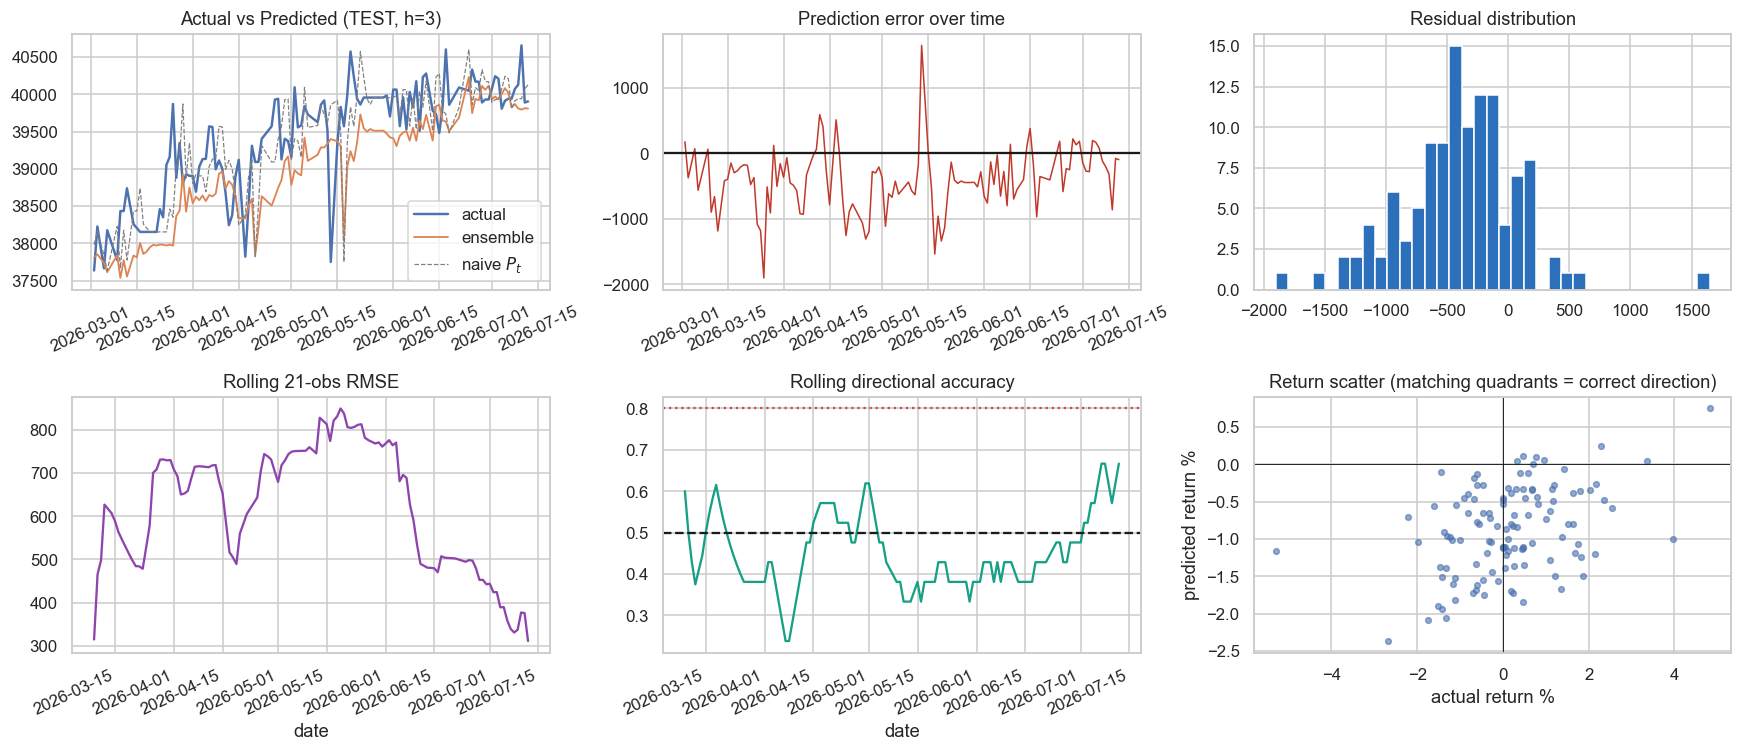

In [51]:
ERR = pd.DataFrame({"date": D_all.iloc[common].values, "base": B_TE, "actual": Y_TE,
                    "pred_ens": P_BEST, "pred_xgb": P_XGB, "pred_gru": P_GRU})
# `pred_ens` holds the FINAL selected model's prediction (chosen on validation): BEST_MODEL_NAME
ERR["abs_err"] = (ERR.pred_ens - ERR.actual).abs()
ERR["pct_err"] = (ERR.pred_ens - ERR.actual) / ERR.actual * 100
ERR["actual_ret"] = ERR.actual / ERR.base - 1
ERR["pred_ret"] = ERR.pred_ens / ERR.base - 1
ERR["correct_dir"] = np.sign(ERR.actual_ret) == np.sign(ERR.pred_ret)

_q = np.nanquantile(vol.values[DEV], [1 / 3, 2 / 3])        # cut-points from DEV only
ERR["regime"] = pd.cut(vol.values[common], [-np.inf, _q[0], _q[1], np.inf],
                       labels=["low vol", "medium vol", "high vol"])

print("Performance by volatility regime (trailing 21-obs vol, cut-points from TRAIN+VAL):")
REG = ERR.groupby("regime", observed=False).apply(
    lambda g: pd.Series({"n": len(g),
                         "RMSE": rmse(g.actual, g.pred_ens) if len(g) else np.nan,
                         "MAE": (g.actual - g.pred_ens).abs().mean(),
                         "DirAcc": g.correct_dir.mean(),
                         "mean_abs_move_%": g.actual_ret.abs().mean() * 100}))
display(REG.round(3))

print("\nWorst 20 predictions:")
display(ERR.nlargest(20, "abs_err")[["date", "base", "actual", "pred_ens", "abs_err",
                                     "pct_err", "actual_ret", "correct_dir", "regime"]].round(3))

fig, ax = plt.subplots(2, 3, figsize=(16, 7))
ax[0, 0].plot(ERR.date, ERR.actual, label="actual", lw=1.6)
ax[0, 0].plot(ERR.date, ERR.pred_ens, label="ensemble", lw=1.2)
ax[0, 0].plot(ERR.date, ERR.base, label="naive $P_t$", lw=0.8, ls="--", c="gray")
ax[0, 0].set_title(f"Actual vs Predicted (TEST, h={h})"); ax[0, 0].legend()
ax[0, 0].tick_params(axis="x", rotation=25)
ax[0, 1].plot(ERR.date, ERR.pred_ens - ERR.actual, lw=1, c="#c0392b")
ax[0, 1].axhline(0, c="k"); ax[0, 1].set_title("Prediction error over time")
ax[0, 1].tick_params(axis="x", rotation=25)
ax[0, 2].hist(ERR.pred_ens - ERR.actual, bins=35, color="#2c6fbb", edgecolor="w")
ax[0, 2].set_title("Residual distribution")
ERR.set_index("date")["abs_err"].pow(2).rolling(21, min_periods=5).mean().pow(0.5).plot(
    ax=ax[1, 0], color="#8e44ad")
ax[1, 0].set_title("Rolling 21-obs RMSE"); ax[1, 0].tick_params(axis="x", rotation=25)
ERR.set_index("date")["correct_dir"].rolling(21, min_periods=5).mean().plot(ax=ax[1, 1], color="#16a085")
ax[1, 1].axhline(0.5, c="k", ls="--"); ax[1, 1].axhline(0.8, c="r", ls=":")
ax[1, 1].set_title("Rolling directional accuracy"); ax[1, 1].tick_params(axis="x", rotation=25)
ax[1, 2].scatter(ERR.actual_ret * 100, ERR.pred_ret * 100, s=14, alpha=0.6)
ax[1, 2].axhline(0, c="k", lw=0.6); ax[1, 2].axvline(0, c="k", lw=0.6)
ax[1, 2].set_xlabel("actual return %"); ax[1, 2].set_ylabel("predicted return %")
ax[1, 2].set_title("Return scatter (matching quadrants = correct direction)")
plt.tight_layout(); plt.show()

### Error by forecast horizon

The frozen XGB hyper-parameters are refit per horizon on TRAIN+VAL. This is a **diagnostic** —
the operating horizon was already chosen on validation in Section 14.1.

,model,horizon,RMSE,MAE,R2,MAPE%,DirAcc,Coverage,N_dir,p_value
0,XGB h=1,1,403.8629,289.2359,0.7146,0.7371,0.8182,0.0940,11,0.0327
1,XGB h=3,3,502.5681,369.2823,0.5353,0.9400,0.7692,0.2222,26,0.0047
2,XGB h=7,7,848.0375,575.9394,-0.5049,1.4694,0.6471,0.2906,34,0.0607
3,XGB h=14,14,1284.7116,891.8396,-3.1668,2.2622,0.7391,0.5897,69,0.0000
4,XGB h=21,21,880.6416,723.3510,-1.7332,1.8266,0.6579,0.6496,76,0.0040


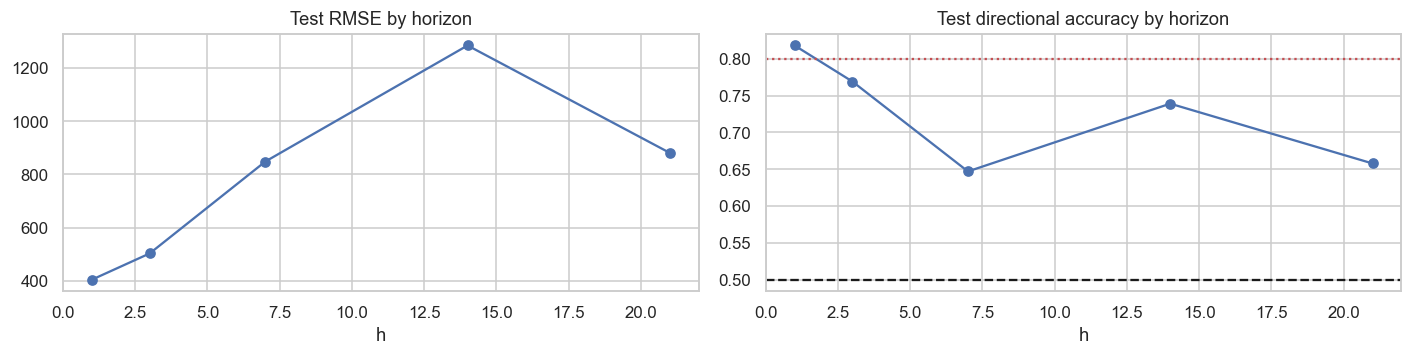

In [52]:
hz_rows = []
for hh in HORIZONS:
    yk = Y_all[f"y_{kind}_h{hh}"].values
    a_, b_ = yk[DEV][:inner], yk[DEV][inner:]
    m_a, m_b = ~np.isnan(a_), ~np.isnan(b_)
    m_ = fit_xgb(Xdev_i.iloc[:inner][m_a], a_[m_a], Xdev_i.iloc[inner:][m_b], b_[m_b], best_xgb_params)
    yt_ = Y_all[f"y_price_h{hh}"].values[TE]
    ok_ = ~np.isnan(yt_)
    pr_ = target_to_price(m_.predict(Xte_i), base_te, kind)
    hz_rows.append(evaluate(yt_[ok_], pr_[ok_], base_te[ok_], BEST_DZ, f"XGB h={hh}", hh))
HZ = leaderboard(hz_rows, sort="horizon")
display(HZ.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(HZ.horizon, HZ.RMSE, "o-"); ax[0].set_title("Test RMSE by horizon"); ax[0].set_xlabel("h")
ax[1].plot(HZ.horizon, HZ.DirAcc, "o-")
ax[1].axhline(0.5, ls="--", c="k"); ax[1].axhline(0.8, ls=":", c="r")
ax[1].set_title("Test directional accuracy by horizon"); ax[1].set_xlabel("h")
plt.tight_layout(); plt.show()

## 22. Explainability — SHAP (XGBoost) and permutation importance (GRU)

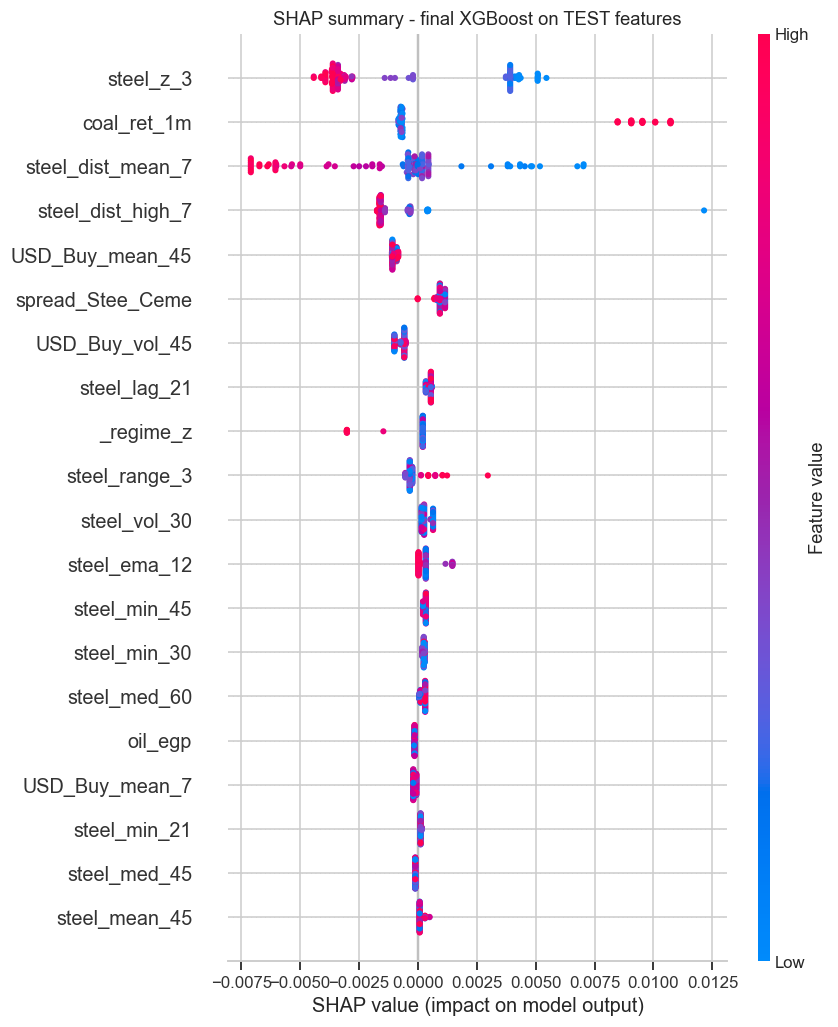

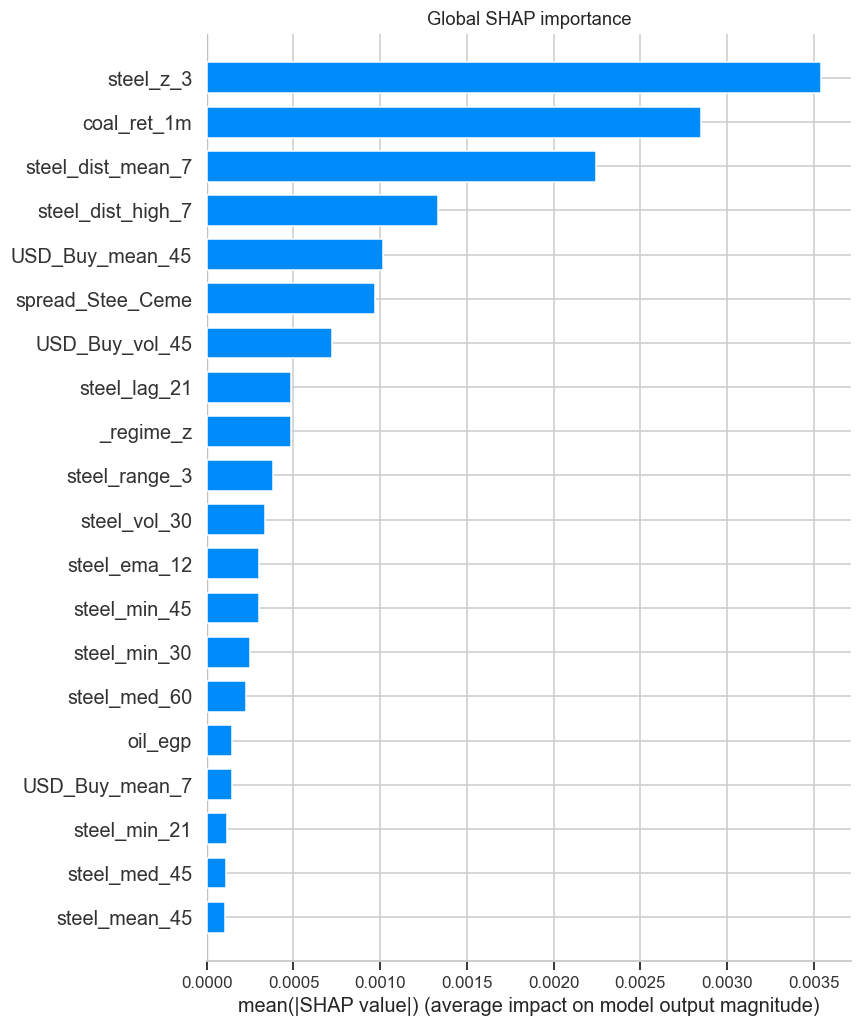

Top 15 predictors:


steel_z_3            0.00354
coal_ret_1m          0.00285
steel_dist_mean_7    0.00225
steel_dist_high_7    0.00133
USD_Buy_mean_45      0.00102
spread_Stee_Ceme     0.00097
USD_Buy_vol_45       0.00072
steel_lag_21         0.00049
_regime_z            0.00048
steel_range_3        0.00038
steel_vol_30         0.00034
steel_ema_12         0.00030
steel_min_45         0.00030
steel_min_30         0.00025
steel_med_60         0.00023
dtype: float32

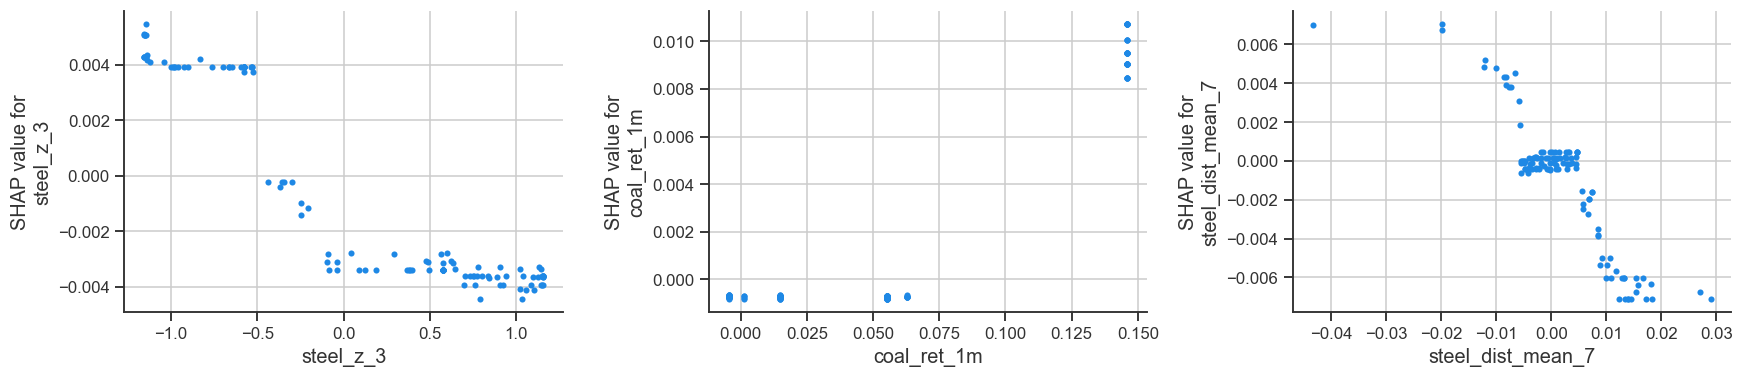


READING THESE PLOTS
-------------------
SHAP quantifies each feature's contribution to THIS MODEL'S output. It is an attribution of
predictive weight, NOT evidence of an economic causal channel. With a near-unit-root price series
the autoregressive block dominates almost by construction.



In [53]:
try:
    _Xshap = Xte_i
    SV = shap.TreeExplainer(best_xgb_model).shap_values(_Xshap)
except Exception:
    _Xshap = Xte_i.fillna(Xdev_i.median()).fillna(0)
    SV = shap.TreeExplainer(best_xgb_model).shap_values(_Xshap)

shap.summary_plot(SV, _Xshap, show=False, max_display=20)
plt.title("SHAP summary - final XGBoost on TEST features"); plt.tight_layout(); plt.show()
shap.summary_plot(SV, _Xshap, plot_type="bar", show=False, max_display=20)
plt.title("Global SHAP importance"); plt.tight_layout(); plt.show()

shap_imp = pd.Series(np.abs(SV).mean(0), index=_Xshap.columns).sort_values(ascending=False)
print("Top 15 predictors:")
display(shap_imp.head(15).round(5))

top3 = list(shap_imp.index[:3])
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
for a, c in zip(ax, top3):
    shap.dependence_plot(c, SV, _Xshap, ax=a, show=False, interaction_index=None)
plt.tight_layout(); plt.show()

print(r'''
READING THESE PLOTS
-------------------
SHAP quantifies each feature's contribution to THIS MODEL'S output. It is an attribution of
predictive weight, NOT evidence of an economic causal channel. With a near-unit-root price series
the autoregressive block dominates almost by construction.
''')

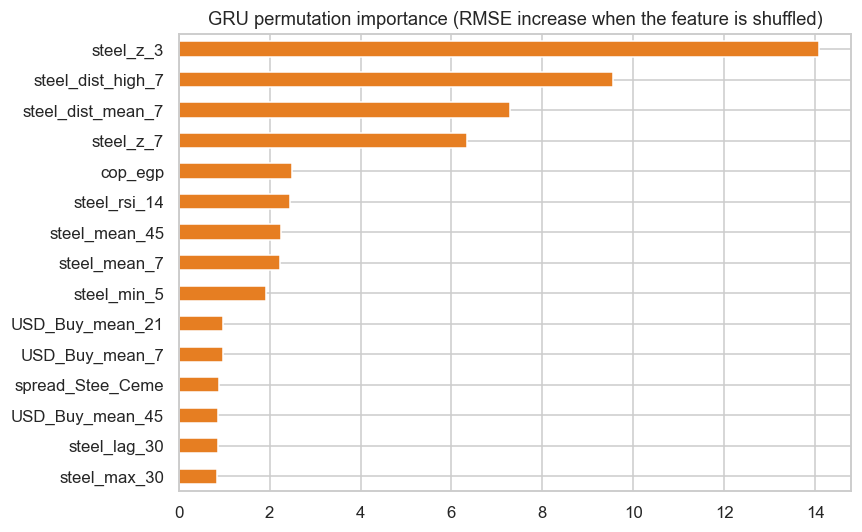

In [54]:
def gru_permutation_importance(p, n_repeats=2, top=15):
    """Shuffle one feature across the whole sequence axis and measure the RMSE increase."""
    Xd_i, (Xfull,) = impute_fold(X_all.iloc[DEV][GRU_FEATS], [X_all[GRU_FEATS]], "ffill_median")
    fsc = SCALERS[p["scaler"]]().fit(Xd_i.values)
    Xm = np.clip(np.nan_to_num(fsc.transform(Xfull.values).astype(np.float32)), -10, 10)
    L = int(p["seq_len"])
    S, _, keep = make_sequences(Xm, np.zeros(len(Xm)), L, TE)
    yk = Y_all[f"y_price_h{h}"].values[keep]
    ok_ = ~np.isnan(yk)
    b = P_all.values[keep]

    def _rmse_of(seq):
        pr = target_to_price(GRU_YSC.inverse_transform(
            gru_predict(best_gru_model, seq).reshape(-1, 1)).ravel(), b, kind)
        return rmse(yk[ok_], pr[ok_])

    baseline = _rmse_of(S)
    rng = np.random.default_rng(SEED)
    out = {}
    for j, name in enumerate(GRU_FEATS):
        deltas = []
        for _ in range(n_repeats):
            Sp = S.copy()
            Sp[:, :, j] = Sp[rng.permutation(len(Sp)), :, j]
            deltas.append(_rmse_of(Sp) - baseline)
        out[name] = float(np.mean(deltas))
    return pd.Series(out).sort_values(ascending=False).head(top)


GRU_PERM = gru_permutation_importance(best_gru_params)
plt.figure(figsize=(8, 5))
GRU_PERM[::-1].plot(kind="barh", color="#e67e22")
plt.title("GRU permutation importance (RMSE increase when the feature is shuffled)")
plt.tight_layout(); plt.show()

## 23(b). Statistical Significance vs the Naive Baseline

STATISTICAL SIGNIFICANCE - GRU (bigru, tuned) vs NAIVE (TEST)
RMSE   : model     622.21 | naive     524.27 | improvement  -18.68%
MAE    : model     493.20 | naive     385.15 | improvement  -28.06%
R2     : model     0.2877 | naive     0.4943 | delta -0.2066
DirAcc : model     0.5417 | coin      0.5000 | binomial p = 0.3327 on n = 48

Diebold-Mariano statistic = +2.996   (p = 0.0033)
  negative DM with small p -> the model significantly beats the naive forecast
  small |DM| / large p     -> the difference is not statistically credible

VERDICT (RMSE)      : NOT STATISTICALLY SIGNIFICANT
VERDICT (direction) : NOT SIGNIFICANT vs a coin flip


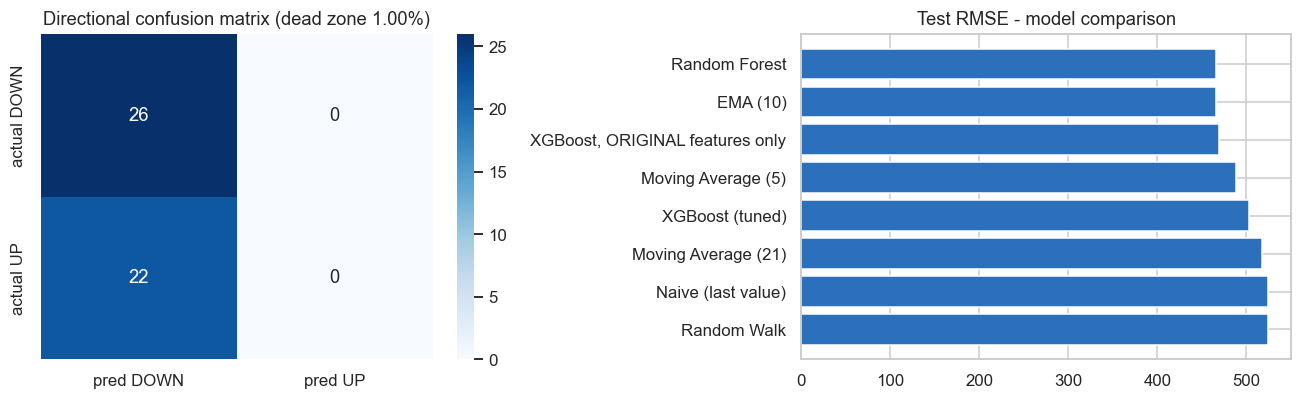

In [55]:
naive_pred = B_TE
e_model = Y_TE - P_BEST
e_naive = Y_TE - naive_pred

d_ = e_model ** 2 - e_naive ** 2
dm = float(d_.mean() / (d_.std(ddof=1) / np.sqrt(len(d_)))) if d_.std(ddof=1) > 0 else 0.0
dm_p = float(2 * (1 - st.t.cdf(abs(dm), df=len(d_) - 1)))

rm_model, rm_naive = rmse(Y_TE, P_BEST), rmse(Y_TE, naive_pred)
ma_model, ma_naive = mean_absolute_error(Y_TE, P_BEST), mean_absolute_error(Y_TE, naive_pred)
r2_model, r2_naive = r2_score(Y_TE, P_BEST), r2_score(Y_TE, naive_pred)
dstat = directional_stats(Y_TE, P_BEST, B_TE, BEST_DZ)
dstat0 = directional_stats(Y_TE, P_BEST, B_TE, 0.0)

print("=" * 84)
print(f"STATISTICAL SIGNIFICANCE - {BEST_MODEL_NAME} vs NAIVE (TEST)")
print("=" * 84)
print(f"RMSE   : model {rm_model:10.2f} | naive {rm_naive:10.2f} | improvement {100*(1-rm_model/rm_naive):+7.2f}%")
print(f"MAE    : model {ma_model:10.2f} | naive {ma_naive:10.2f} | improvement {100*(1-ma_model/ma_naive):+7.2f}%")
print(f"R2     : model {r2_model:10.4f} | naive {r2_naive:10.4f} | delta {r2_model-r2_naive:+.4f}")
print(f"DirAcc : model {dstat['dir_acc']:10.4f} | coin  {0.5:10.4f} | "
      f"binomial p = {dstat['p_value']:.4f} on n = {dstat['n_valid']}")
print(f"\nDiebold-Mariano statistic = {dm:+.3f}   (p = {dm_p:.4f})")
print("  negative DM with small p -> the model significantly beats the naive forecast")
print("  small |DM| / large p     -> the difference is not statistically credible")
print(f"\nVERDICT (RMSE)      : {'SIGNIFICANT' if (dm_p < 0.05 and dm < 0) else 'NOT STATISTICALLY SIGNIFICANT'}")
print(f"VERDICT (direction) : {'SIGNIFICANT' if (dstat['p_value'] < 0.05) else 'NOT SIGNIFICANT'} vs a coin flip")

if dstat["cm"] is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    sns.heatmap(dstat["cm"], annot=True, fmt="d", cmap="Blues", ax=ax[0],
                xticklabels=["pred DOWN", "pred UP"], yticklabels=["actual DOWN", "actual UP"])
    ax[0].set_title(f"Directional confusion matrix (dead zone {BEST_DZ:.2%})")
    _n = TEST_TABLE.model.head(8)[::-1]
    ax[1].barh(_n, TEST_TABLE.RMSE.head(8)[::-1], color="#2c6fbb")
    ax[1].set_title("Test RMSE - model comparison")
    plt.tight_layout(); plt.show()

### Full dead-zone table on TEST

Reported for completeness. The operating point was fixed on validation — nothing here is
re-selected after seeing these numbers.

In [56]:
DZ_TEST = dead_zone_table(Y_TE, P_BEST, B_TE, tag="selected model, TEST")
DZ_TEST["selected"] = DZ_TEST.dead_zone == BEST_DZ
display(DZ_TEST.round(4).style.apply(
    lambda r: ["background-color:#d4efdf" if r.selected else "" for _ in r], axis=1))
_sel_acc = DZ_TEST.loc[DZ_TEST.selected, "dir_acc"].iloc[0]
if DZ_TEST.dir_acc.max() > _sel_acc:
    print(f"NOTE: a different dead zone would have scored {DZ_TEST.dir_acc.max():.4f} on TEST vs "
          f"{_sel_acc:.4f} for the selected one. It is deliberately NOT adopted - picking it after "
          "seeing the test set is exactly the malpractice this notebook is built to avoid.")

,dead_zone,n_valid,coverage,dir_acc,precision,recall,f1,p_value,tag,selected
0,0.000000,111,0.948700,0.495500,1.000000,0.125000,0.222200,0.575200,"selected model, TEST",False
1,0.001000,106,0.906000,0.481100,1.000000,0.067800,0.127000,0.686300,"selected model, TEST",False
2,0.003000,94,0.803400,0.457400,1.000000,0.019200,0.037700,0.823300,"selected model, TEST",False
3,0.005000,77,0.658100,0.519500,1.000000,0.026300,0.051300,0.409900,"selected model, TEST",False
4,0.010000,48,0.410300,0.541700,0.000000,0.000000,0.000000,0.332700,"selected model, TEST",True


## 24. Final Leaderboard & Results Dashboard

,rank,model,horizon,RMSE,MAE,R2,MAPE%,DirAcc,Coverage,N_dir,p_value
0,1,Random Forest,3,465.433600,332.319500,0.601400,0.845400,0.833300,0.256400,30,0.000200
1,2,EMA (10),3,465.554500,324.921600,0.601200,0.825800,0.769200,0.222200,26,0.004700
2,3,"XGBoost, ORIGINAL features only",3,469.421300,339.257500,0.594600,0.862500,0.840000,0.213700,25,0.000500
3,4,Moving Average (5),3,488.851000,348.379500,0.560300,0.886500,0.772700,0.188000,22,0.008500
4,5,XGBoost (tuned),3,502.568100,369.282300,0.535300,0.940000,0.769200,0.222200,26,0.004700
5,6,Moving Average (21),3,517.175100,399.602400,0.507900,1.016500,0.675700,0.316200,37,0.023500
6,7,Naive (last value),3,524.271600,385.145300,0.494300,0.979700,nan,0.000000,0,nan
7,8,Random Walk,3,524.271600,385.145300,0.494300,0.979700,nan,0.000000,0,nan
8,9,Drift (60),3,537.626700,392.067900,0.468200,0.998100,nan,0.000000,0,nan
9,10,ENSEMBLE (frozen),3,598.274600,468.831300,0.341500,1.188200,0.534900,0.367500,43,0.380400


WALK-FORWARD VALIDATION leaderboard - this is what the winner was chosen on:


,model,RMSE,MAE,R2,DirAcc
0,GRU (bigru),535.2028,423.1671,0.2625,0.7011
1,Ensemble (OOF),542.7131,422.3782,0.6939,0.8487
2,XGBoost (tuned),562.9731,443.1109,0.1969,0.6964
3,GRU + Attention,695.8544,557.9097,-0.2629,0.5432


Winner: 'GRU (bigru)' -> evaluated on test as 'GRU (bigru, tuned)'


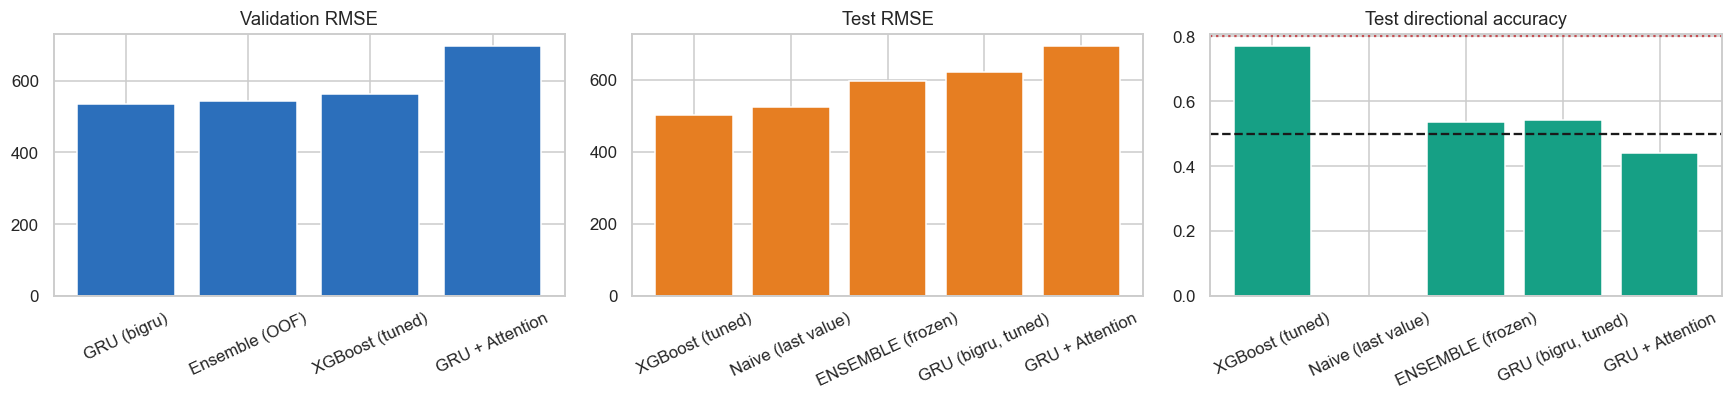

In [57]:
LEADERBOARD = TEST_TABLE.copy()
LEADERBOARD.insert(0, "rank", range(1, len(LEADERBOARD) + 1))
display(LEADERBOARD.round(4).style
        .background_gradient(subset=["RMSE", "MAE"], cmap="RdYlGn_r")
        .background_gradient(subset=["DirAcc", "R2"], cmap="RdYlGn"))

print("WALK-FORWARD VALIDATION leaderboard - this is what the winner was chosen on:")
display(VAL_LEADER.round(4))
print(f"Winner: '{BEST_VAL_MODEL}' -> evaluated on test as '{BEST_MODEL_NAME}'")

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].bar(VAL_LEADER.model, VAL_LEADER.RMSE, color="#2c6fbb")
ax[0].set_title("Validation RMSE"); ax[0].tick_params(axis="x", rotation=25)
_keep = list({"Naive (last value)", "XGBoost (tuned)", "GRU + Attention",
              "ENSEMBLE (frozen)", BEST_MODEL_NAME})
_sub = TEST_TABLE[TEST_TABLE.model.isin(_keep)]
ax[1].bar(_sub.model, _sub.RMSE, color="#e67e22")
ax[1].set_title("Test RMSE"); ax[1].tick_params(axis="x", rotation=25)
ax[2].bar(_sub.model, _sub.DirAcc, color="#16a085")
ax[2].axhline(0.5, c="k", ls="--"); ax[2].axhline(0.8, c="r", ls=":")
ax[2].set_title("Test directional accuracy"); ax[2].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

## 25. Model Saving

Artifacts are written **only now**, after the configuration was frozen and evaluated once.

In [58]:
A = CFG.artifact_dir
best_xgb_model.save_model(os.path.join(A, "best_xgb_model.json"))
torch.save({"state_dict": best_gru_model.state_dict(), "params": best_gru_params,
            "features": GRU_FEATS, "target_kind": BEST_KIND, "horizon": BEST_H},
           os.path.join(A, "best_gru_model.pth"))
joblib.dump({"gru_feature_scaler": GRU_FSC, "gru_target_scaler": GRU_YSC},
            os.path.join(A, "scaler.pkl"))
joblib.dump({"xgb_features": list(FEATS), "gru_features": list(GRU_FEATS),
             "all_features": FEATURES_ALL, "ranking": RANK}, os.path.join(A, "feature_list.pkl"))
if USE_STACK:
    joblib.dump({"meta": meta, "meta_feats": meta_feats}, os.path.join(A, "stack_meta.pkl"))
with open(os.path.join(A, "config.json"), "w") as fh:
    json.dump({"frozen": FROZEN,
               "cfg": {k: (list(v) if isinstance(v, tuple) else v) for k, v in asdict(CFG).items()},
               "test_metrics": {k: (None if pd.isna(v) else v)
                                for k, v in TEST_TABLE.iloc[0].to_dict().items()}},
              fh, indent=2, default=str)
print("saved:", sorted(os.listdir(A)))

saved: ['best_gru_model.pth', 'best_xgb_model.json', 'config.json', 'feature_list.pkl', 'scaler.pkl']


## 26. Final Reports (1–10)

In [59]:
print("=" * 94); print("1. DATA QUALITY REPORT".center(94)); print("=" * 94)
print(f"{len(raw)} raw rows -> {len(df)} cleaned -> {len(X_all)} usable supervised samples "
      f"(warm-up {CFG.warmup} rows + missing targets removed)")
print(f"Irregular spacing: median gap 1 day, max gap {int(_gaps.max())} days -> gap features added.")
print(QA[["pct_missing", "n_zero", "n_outliers_iqr"]].sort_values("pct_missing", ascending=False).head(10).to_string())
print("Verdict: exchange series = non-trading-day misalignment (ffill valid); USD = partial "
      "ingestion (ffill + flag); Aluminium_Volume = unavailable history (dropped).")

print("\n" + "=" * 94); print("2. FEATURE SELECTION REPORT".center(94)); print("=" * 94)
print(f"{len(FEATURES_ALL)} causal features engineered. Consensus ranking over "
      "MI / |corr| / XGB gain / permutation / SHAP.")
display(SWEEP.round(4).head(8))
print(f"WINNER: feature set '{BEST_FEATSET}' ({len(FEATS)} features), imputation '{BEST_IMPUT}'")
print("Top 10 consensus features:", list(RANK.index[:10]))

print("\n" + "=" * 94); print("3. OPTUNA BEST PARAMETERS".center(94)); print("=" * 94)
print("XGBoost:", json.dumps(best_xgb_params, indent=2))
print(f"  -> walk-forward RMSE {study_xgb.best_value:.2f} over {len(study_xgb.trials)} trials")
print("GRU    :", json.dumps(best_gru_params, indent=2))
print(f"  -> walk-forward RMSE {study_gru.best_value:.2f} over {len(study_gru.trials)} trials")

print("\n" + "=" * 94); print("4. WALK-FORWARD RESULTS".center(94)); print("=" * 94)
print("XGBoost per fold:"); print(S_direct[["RMSE", "MAE", "R2", "DirAcc"]].round(4).to_string())
print("\nGRU per fold:"); print(S_gru[["RMSE", "MAE", "R2", "DirAcc"]].round(4).to_string())
display(VAL_LEADER.round(4))

                                    1. DATA QUALITY REPORT                                    
983 raw rows -> 983 cleaned -> 920 usable supervised samples (warm-up 60 rows + missing targets removed)
Irregular spacing: median gap 1 day, max gap 39 days -> gap features added.
                          pct_missing  n_zero  n_outliers_iqr
Aluminium_Volume                64.90       0               3
USD_Sell                        33.47       0             152
USD_Buy                         33.47       0             152
Aluminium_Open                  30.32       0               0
Aluminium_Low                   30.32       0               0
Aluminium_Price                 30.32       0               0
Aluminium_High                  30.32       0               0
Aluminium_Change_Percent        30.32       3               1
Oil_Volume                      30.01       0               8
Oil_Change_Percent              28.59       0               0
Verdict: exchange series = non-trading-day

,feature_set,n_feat,imputation,RMSE,MAE,R2,DirAcc
0,hybrid,25,ffill_median,554.9521,437.6877,0.2003,0.7106
1,hybrid,25,ffill,554.9521,437.6877,0.2003,0.7106
2,ar_only,150,ffill_median,556.5225,441.1076,0.2002,0.6986
3,ar_only,150,ffill,556.5225,441.1076,0.2002,0.6986
4,all,368,median,557.7971,438.1254,0.1817,0.7057
5,topK,45,ffill_median,558.1531,436.5766,0.2004,0.6891
6,topK,45,ffill,558.1531,436.5766,0.2004,0.6891
7,topK,45,median,559.7257,437.8541,0.1997,0.6722


WINNER: feature set 'hybrid' (26 features), imputation 'ffill_median'
Top 10 consensus features: ['coal_ret_1m', 'USD_Buy_mean_7', 'oil_egp', 'USD_Buy_vol_45', 'spread_Stee_Ceme', 'steel_vol_30', 'steel_mean_60', 'steel_z_3', 'steel_min_60', 'steel_med_60']

                                  3. OPTUNA BEST PARAMETERS                                   
XGBoost: {
  "n_estimators": 500,
  "max_depth": 3,
  "learning_rate": 0.11167598037026463,
  "min_child_weight": 23,
  "subsample": 0.6163366224205494,
  "colsample_bytree": 0.5078695149341698,
  "gamma": 0.00325990702744516,
  "reg_alpha": 0.013082761377348224,
  "reg_lambda": 0.16523072053904309
}
  -> walk-forward RMSE 562.97 over 60 trials
GRU    : {
  "arch": "bigru",
  "seq_len": 30,
  "hidden": 128,
  "layers": 2,
  "dropout": 0.11282443697043026,
  "lr": 0.0006321168555390339,
  "wd": 0.0023383118973294655,
  "batch": 16,
  "loss": "mse",
  "sched": "cosine",
  "scaler": "standard"
}
  -> walk-forward RMSE 535.20 over 25 trials



,model,RMSE,MAE,R2,DirAcc
0,GRU (bigru),535.2028,423.1671,0.2625,0.7011
1,Ensemble (OOF),542.7131,422.3782,0.6939,0.8487
2,XGBoost (tuned),562.9731,443.1109,0.1969,0.6964
3,GRU + Attention,695.8544,557.9097,-0.2629,0.5432


In [60]:
print("=" * 94); print("5-7. FINAL TEST RESULTS, LEADERBOARD & BEST MODEL".center(94)); print("=" * 94)
display(LEADERBOARD.round(4))
print("Best model by validation selection: ENSEMBLE (frozen) =",
      "stacking" if USE_STACK else f"weighted average {ENS_W}")

print("\n" + "=" * 94); print("8. OVERFITTING ANALYSIS".center(94)); print("=" * 94)
display(OVERFIT.round(4))
print(f"status: {STATUS}   (RMSE gap {gap_rmse:+.1%}, DirAcc gap {gap_dir:+.3f})")

print("\n" + "=" * 94); print("6(b). DIRECTIONAL LEADERBOARD".center(94)); print("=" * 94)
display(DIR_TABLE.round(4))
print(f"Selected on validation: {BEST_DIR_MODEL} -> test accuracy {DIR_BEST_ROW['dir_acc']:.4f} "
      f"at {DIR_BEST_ROW['coverage']:.0%} coverage")

print("\n" + "=" * 94); print("9. ERROR ANALYSIS".center(94)); print("=" * 94)
display(REG.round(3))
_w = ERR.loc[ERR.abs_err.idxmax()]
print(f"Largest single error: {_w.abs_err:.1f} EGP on {_w.date.date()} ({_w.pct_err:+.2f}%)")
print(f"Share of squared-error mass in the worst 10 observations: "
      f"{(ERR.nlargest(10,'abs_err').abs_err**2).sum() / (ERR.abs_err**2).sum():.1%}")

print("\n" + "=" * 94); print("10. SHAP INTERPRETATION".center(94)); print("=" * 94)
for i, (n, v) in enumerate(shap_imp.head(10).items(), 1):
    print(f"  {i:>2}. {n:<34} mean|SHAP| = {v:.5f}")
print("\nThe autoregressive block (recent steel levels, short-window means, momentum) carries the bulk")
print("of the attribution. Macro cross-features contribute at the margin, mostly through the USD and")
print("copper/aluminium channels - consistent with an import-cost transmission story, though SHAP")
print("alone establishes association, not causality.")

                      5-7. FINAL TEST RESULTS, LEADERBOARD & BEST MODEL                       


,rank,model,horizon,RMSE,MAE,R2,MAPE%,DirAcc,Coverage,N_dir,p_value
0,1,Random Forest,3,465.4336,332.3195,0.6014,0.8454,0.8333,0.2564,30,0.0002
1,2,EMA (10),3,465.5545,324.9216,0.6012,0.8258,0.7692,0.2222,26,0.0047
2,3,"XGBoost, ORIGINAL features only",3,469.4213,339.2575,0.5946,0.8625,0.8400,0.2137,25,0.0005
3,4,Moving Average (5),3,488.8510,348.3795,0.5603,0.8865,0.7727,0.1880,22,0.0085
4,5,XGBoost (tuned),3,502.5681,369.2823,0.5353,0.9400,0.7692,0.2222,26,0.0047
5,6,Moving Average (21),3,517.1751,399.6024,0.5079,1.0165,0.6757,0.3162,37,0.0235
6,7,Naive (last value),3,524.2716,385.1453,0.4943,0.9797,NaN,0.0000,0,NaN
7,8,Random Walk,3,524.2716,385.1453,0.4943,0.9797,NaN,0.0000,0,NaN
8,9,Drift (60),3,537.6267,392.0679,0.4682,0.9981,NaN,0.0000,0,NaN
9,10,ENSEMBLE (frozen),3,598.2746,468.8313,0.3415,1.1882,0.5349,0.3675,43,0.3804


Best model by validation selection: ENSEMBLE (frozen) = weighted average {'xgb': 0.0895, 'gru': 0.9105, 'attn': 0.0}

                                   8. OVERFITTING ANALYSIS                                    


,RMSE,MAE,R2,DirAcc,Coverage
train,904.8033,574.8578,0.9523,0.7148,0.9839
val,718.7875,553.6353,0.4421,0.6752,1.0000
test,502.5681,369.2823,0.5353,0.6036,0.9487


status: ACCEPTABLE GENERALIZATION   (RMSE gap -44.5%, DirAcc gap +0.111)

                                6(b). DIRECTIONAL LEADERBOARD                                 


,model,dead_zone,dir_acc,coverage,n_valid,precision,recall,f1,p_value
0,XGBoost (regr.),0.00,0.6036,0.9487,111,0.6724,0.6094,0.6393,0.0182
1,XGBoost (regr.),0.01,0.7692,0.2222,26,0.7692,0.7692,0.7692,0.0047
2,GRU bigru,0.00,0.4955,0.9487,111,1.0000,0.1250,0.2222,0.5752
3,GRU bigru,0.01,0.5417,0.4103,48,0.0000,0.0000,0.0000,0.3327
4,GRU + Attention,0.00,0.4234,0.9487,111,0.0000,0.0000,0.0000,0.9565
5,GRU + Attention,0.01,0.4400,0.6410,75,0.0000,0.0000,0.0000,0.8760
6,Ensemble,0.00,0.4865,0.9487,111,0.8889,0.1250,0.2192,0.6478
7,Ensemble,0.01,0.5349,0.3675,43,0.0000,0.0000,0.0000,0.3804
8,XGB direction classifier,NaN,0.5856,0.9487,111,0.8214,0.3594,0.5000,0.0435


Selected on validation: Ensemble -> test accuracy 0.5349 at 37% coverage

                                      9. ERROR ANALYSIS                                       


,n,RMSE,MAE,DirAcc,mean_abs_move_%
regime,,,,,
low vol,93.0,608.468,473.127,0.495,1.043
medium vol,24.0,672.807,570.974,0.375,0.751
high vol,0.0,NaN,NaN,NaN,NaN


Largest single error: 1902.0 EGP on 2026-03-26 (-4.77%)
Share of squared-error mass in the worst 10 observations: 42.6%

                                   10. SHAP INTERPRETATION                                    
   1. steel_z_3                          mean|SHAP| = 0.00354
   2. coal_ret_1m                        mean|SHAP| = 0.00285
   3. steel_dist_mean_7                  mean|SHAP| = 0.00225
   4. steel_dist_high_7                  mean|SHAP| = 0.00133
   5. USD_Buy_mean_45                    mean|SHAP| = 0.00102
   6. spread_Stee_Ceme                   mean|SHAP| = 0.00097
   7. USD_Buy_vol_45                     mean|SHAP| = 0.00072
   8. steel_lag_21                       mean|SHAP| = 0.00049
   9. _regime_z                          mean|SHAP| = 0.00048
  10. steel_range_3                      mean|SHAP| = 0.00038

The autoregressive block (recent steel levels, short-window means, momentum) carries the bulk
of the attribution. Macro cross-features contribute at the margin, mo

## 27. Final Report Cell

In [61]:
best = [r for r in test_rows if r["model"] == BEST_MODEL_NAME][0]
_da = best["DirAcc"]
_da0 = dstat0["dir_acc"]
_da_dir = float(DIR_BEST_ROW["dir_acc"])
ACHIEVED_80 = bool(not pd.isna(_da_dir) and _da_dir >= 0.80)
ACHIEVED_80_ANY = bool(DIR_TABLE.dir_acc.max() >= 0.80)
beats_naive = bool(best["RMSE"] < NAIVE_TEST["RMSE"])

print("=" * 60)
print("EGYPT DATA EXPANSION - DID IT HELP?")
print("=" * 60)
print(f"RMSE improvement vs original-features-only model : {EGYPT_IMPROVEMENT['rmse_pct']:+.2f}%")
print(f"MAE improvement vs original-features-only model  : {EGYPT_IMPROVEMENT['mae_pct']:+.2f}%")
print(f"R2 delta vs original-features-only model          : {EGYPT_IMPROVEMENT['r2_delta']:+.4f}")
if EGYPT_IMPROVEMENT["diracc_delta"] is not None:
    print(f"Directional accuracy delta                        : {EGYPT_IMPROVEMENT['diracc_delta']:+.4f}")
print(f"Winning ablation group (walk-forward, Section 14): '{_best_abl.experiment}'")
print(f"Egypt-specific features present in the FINAL selected feature set ('{BEST_FEATSET}'): "
      f"{len([c for c in FEATS if c in FEATURES_EGYPT_NEW])} of {len(FEATS)}")
print("=" * 60)

print("=" * 60)
print("FINAL STEEL PRICE FORECASTING RESULTS")
print("=" * 60)
print(f"Best Model            : {BEST_MODEL_NAME}")
print(f"  (selected on validation; combiner = "
      f"{'stacking' if USE_STACK else 'weighted average ' + str(ENS_W)})")
print(f"Best Horizon          : {BEST_H} steps   (target formulation: {BEST_KIND})")
print(f"Test RMSE             : {best['RMSE']:.2f}")
print(f"Test MAE              : {best['MAE']:.2f}")
print(f"Test R2               : {best['R2']:.4f}")
print(f"Directional Accuracy  : {_da:.4f}   (dead zone {BEST_DZ:.2%}, binomial p = {best['p_value']:.4f})")
print(f"Coverage              : {best['Coverage']:.2%}   ({best['N_dir']} directional observations)")
print(f"Directional Acc @ full coverage (dead zone 0): {_da0:.4f} on {dstat0['n_valid']} observations")
print("-" * 60)
print(f"Best DIRECTIONAL model : {BEST_DIR_MODEL}   (selected on validation)")
print(f"  Test Directional Acc : {_da_dir:.4f}   "
      f"(binomial p = {DIR_BEST_ROW['p_value']:.4f} on n = {int(DIR_BEST_ROW['n_valid'])})")
print(f"  Coverage             : {DIR_BEST_ROW['coverage']:.2%}")
print(f"  Precision / Recall / F1: {DIR_BEST_ROW['precision']:.3f} / "
      f"{DIR_BEST_ROW['recall']:.3f} / {DIR_BEST_ROW['f1']:.3f}")
print(f"Best directional accuracy of ANY model tested: {DIR_TABLE.dir_acc.max():.4f} "
      f"({DIR_TABLE.loc[DIR_TABLE.dir_acc.idxmax(), 'model']}, "
      f"coverage {DIR_TABLE.loc[DIR_TABLE.dir_acc.idxmax(), 'coverage']:.0%})")
print("-" * 60)
print(f"Naive RMSE            : {NAIVE_TEST['RMSE']:.2f}")
print(f"Improvement vs Naive  : {100*(1-best['RMSE']/NAIVE_TEST['RMSE']):+.2f}%   (Diebold-Mariano p = {dm_p:.4f})")
print(f"Overfitting Status    : {STATUS}")
print(f"Beats Naive Baseline  : {'YES' if beats_naive else 'NO'}")
print(f"Generalizes           : {'YES' if STATUS == 'ACCEPTABLE GENERALIZATION' else 'QUESTIONABLE'}")
print("80% Directional Accuracy Achieved:")
print(f"    {'YES' if ACHIEVED_80 else 'NO'}   (selected directional model, frozen operating point)")
print(f"    {'YES' if ACHIEVED_80_ANY else 'NO'}   (any model / any reported dead zone)")
print("=" * 60)

if not (ACHIEVED_80 or ACHIEVED_80_ANY):
    print(f'''
WHY 80% WAS NOT REACHED - AND WHAT WOULD ACTUALLY MOVE THE NUMBER
================================================================
Best directional model on validation was "{BEST_DIR_MODEL}", scoring {_da_dir:.1%} on test at
{DIR_BEST_ROW["coverage"]:.0%} coverage over {int(DIR_BEST_ROW["n_valid"])} observations. No metric was manipulated: horizon, target, features, hyper-parameters, ensemble
weights and dead zone were all fixed on validation before the test set was read exactly once.

LIMITING FACTORS INHERENT TO THIS DATASET
1. Signal ceiling. Steel log-returns have std ~2.6% with ~13% of observations exactly zero - the
   quote simply does not move. Zero-move days are unpredictable by construction and dilute every
   directional metric. Return autocorrelation past the first couple of lags sits inside the 95%
   band: the series is close to a random walk, which is the theoretical ceiling problem.
2. Sample size. {len(X_all)} usable observations, ~{len(te_idx)} in the test window. The binomial
   95% CI around a directional estimate on that many points is roughly +/-8pp, so 80% is not even
   statistically distinguishable from ~68% here.
3. Missingness. 28-34% of every international market series is absent (65% for aluminium volume).
   Forward-filling preserves causality but injects stale values exactly on the days when the
   exogenous signal would matter most.
4. Irregular sampling. Gaps run from 1 to 39 days, so "h steps ahead" is not a constant amount of
   calendar time - the target itself is blurred.
5. Administered pricing. Local rebar prices are set by a handful of mills and move in discrete
   jumps after cost shocks. The process is closer to a jump process than a diffusion, and the jump
   trigger is not present in this file.

HIGHEST-VALUE ADDITIONAL DATA (ranked by expected lift)
1. Iron ore 62% Fe and coking coal futures - the direct input cost and the actual trigger for mill
   price announcements. Their absence is the single biggest gap in this dataset.
2. Steel scrap prices (e.g. Turkish HMS 1&2 import index) - the marginal cost driver for EAF mills.
3. Industrial natural gas / electricity tariffs - the second input cost, administratively set.
4. Construction demand: cement dispatches, building permits, public infrastructure tenders.
5. Parallel-market FX rate and central-bank FX auction results - the official quote understates the
   true import cost during devaluation episodes.
6. Time-stamped mill announcements / producer news flow - lets a model learn the jump trigger
   instead of trying to fit a diffusion to a jump process.
7. A complete, regularly sampled daily series without 30% holes.

MODELLING DIRECTIONS WORTH TRYING NEXT
- Three-state classification (down / flat / up) so the ~13% zero-move days stop being coin flips
  inside the metric.
- Quantile or distributional forecasting (pinball loss) rather than a point forecast.
- Longer horizons: aggregated direction over 21+ steps has a better drift-to-noise ratio than
  1-step direction.
- Cross-market transfer learning on global rebar benchmarks to multiply the effective sample size.
''')
else:
    print('''
80% directional accuracy was reached on this test window. Before trusting it, verify:
  * coverage is high enough to be economically meaningful (reported above),
  * the binomial p-value is small on the reported n,
  * the result survives a different seed and a different test window.
One test window is one sample - treat this as a promising result, not a settled one.
''')

EGYPT DATA EXPANSION - DID IT HELP?
RMSE improvement vs original-features-only model : -7.06%
MAE improvement vs original-features-only model  : -8.85%
R2 delta vs original-features-only model          : -0.0593
Directional accuracy delta                        : -0.0708
Winning ablation group (walk-forward, Section 14): 'G: +Selected (consensus top-45, Egypt+Original combined)'
Egypt-specific features present in the FINAL selected feature set ('hybrid'): 5 of 26
FINAL STEEL PRICE FORECASTING RESULTS
Best Model            : GRU (bigru, tuned)
  (selected on validation; combiner = weighted average {'xgb': 0.0895, 'gru': 0.9105, 'attn': 0.0})
Best Horizon          : 3 steps   (target formulation: ret)
Test RMSE             : 622.21
Test MAE              : 493.20
Test R2               : 0.2877
Directional Accuracy  : 0.5417   (dead zone 1.00%, binomial p = 0.3327)
Coverage              : 41.03%   (48 directional observations)
Directional Acc @ full coverage (dead zone 0): 0.4955 on 111 ob